---
# **FDS Feature Architecture**
---

| Block | Risk Type        | Nature |
| ----- | ---------------- | ------ |
| 1     | Amount           | 거래 강도  |
| 2     | Error            | 실패 행동  |
| 3     | Temporal         | 시간 패턴  |
| 4     | Static           | 구조적 배경 |
| 5     | Card/Channel     | 결제 특성  |
| 6     | MCC              | 업종 리스크 |
| 7     | Merchant Novelty | 상점 변화  |
| 8     | Velocity         | 급격성    |
| 9     | Fraud History    | 과거 전력  |
| 10    | Interaction      | 복합 위험  |


In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

LABEL = "fraud"

%matplotlib inline

In [2]:
df = pd.read_parquet("../5DATA/dataset/train_stage2")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 608430 entries, 0 to 609657
Data columns (total 55 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id                        608430 non-null  int64         
 1   date                      608430 non-null  datetime64[ns]
 2   client_id                 608430 non-null  int64         
 3   card_id                   608430 non-null  int64         
 4   amount                    608430 non-null  float32       
 5   merchant_id               608430 non-null  int64         
 6   mcc                       608430 non-null  object        
 7   is_online                 608430 non-null  int8          
 8   fraud                     608430 non-null  int8          
 9   has_error                 608430 non-null  int8          
 10  err_bad_card_number       608430 non-null  int8          
 11  err_bad_expiration        608430 non-null  int8          
 12  err_bad

In [4]:
BASELINE = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

In [332]:
rows_uni = []

for col in BASELINE:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,amount_income_ratio,0.015800,1.015925,3.487204e-01,0.037967,3.517052,60843
1,log_abs_amount,0.645975,1.907846,0.000000e+00,0.037209,3.446903,60845
2,amount_limit_ratio,0.602736,1.827111,2.279100e-183,0.023109,2.140682,60843
3,credit_limit,-0.000022,0.999978,5.736238e-71,0.016486,1.527213,62173
4,is_credit,0.072032,1.074690,6.739010e-03,0.011337,1.050166,185771
5,has_chip,0.261013,1.298245,1.202118e-07,0.011011,1.019984,556094
6,has_error,0.688805,1.991335,5.942531e-30,0.010795,1.000000,608430
7,current_age,0.005249,1.005263,1.740944e-11,0.009717,0.900147,64011


---

## Block: BASELINE Core Layer

### 1. 유지 (Baseline 핵심 축)

| Feature            | 판단    | 근거                     |
| ------------------ | ----- | ---------------------- |
| log_abs_amount     | 핵심 유지 | 절대 거래 금액은 기본 리스크 축을 형성 |
| amount_limit_ratio | 유지    | 한도 대비 과다 사용은 구조적으로 타당  |
| credit_limit       | 유지    | 개인의 신용 안정성을 보정하는 변수    |
| has_error          | 유지    | 시스템 거절/이상 신호 반영        |
| is_credit          | 유지    | 카드 유형에 따른 리스크 세그먼트 구분  |
| has_chip           | 유지    | 결제 채널 및 보안 특성 반영       |

---

### 2. 조건부 유지

| Feature             | 판단    | 근거                             |
| ------------------- | ----- | ------------------------------ |
| current_age         | 보조 유지 | 위험도 조정 변수로 사용 가능               |
| amount_income_ratio | 제거 가능 | 유의성이 상대적으로 약하며 다른 금액 변수에 흡수 가능 |

---

## Baseline 레이어의 역할

이 레이어는 거래의 기본 위험 수준을 형성하는 보정 계층(calibration layer)이다.

* log_abs_amount: 거래 규모에 따른 기본 위험도 반영
* amount_limit_ratio: 한도 대비 과다 사용 여부 반영
* credit_limit: 개인 신용 안정성 보정
* has_error: 시스템 차원의 거절 신호 반영

이 레이어는 단독으로 강한 상호작용을 만들어내기보다는,
상위 레이어(행동 패턴, 이력 기반 변수 등)의 신호가 증폭될 수 있는 기본 확률 구조(prior risk structure)를 설정하는 역할을 수행한다.

---


---
# 0. Dataset Overview
## 0.1 Base Schema (Raw Layer)
### Transaction Identity
- date
- client_id
- card_id
- merchant_id
- mcc

### Label
- fraud
---

In [5]:
print("=== DATASET SHAPE ===")
print(df.shape)

print("\n=== MEMORY USAGE (MB) ===")
print(round(df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

print("\n=== COLUMN INFO ===")
display(df.dtypes)

=== DATASET SHAPE ===
(608430, 55)

=== MEMORY USAGE (MB) ===
132.3 MB

=== COLUMN INFO ===


id                                   int64
date                        datetime64[ns]
client_id                            int64
card_id                              int64
amount                             float32
merchant_id                          int64
mcc                                 object
is_online                             int8
fraud                                 int8
has_error                             int8
err_bad_card_number                   int8
err_bad_expiration                    int8
err_bad_cvv                           int8
err_bad_pin                           int8
err_bad_zipcode                       int8
err_insufficient_balance              int8
err_technical_glitch                  int8
tx_year                              int16
tx_month                              int8
tx_day                                int8
tx_hour                               int8
weekday                               int8
is_refund                             int8
log_abs_amo

In [6]:
print("=== FRAUD DISTRIBUTION ===")

label_dist = df["fraud"].value_counts()
label_ratio = df["fraud"].value_counts(normalize=True)

display(pd.concat([label_dist, label_ratio], axis=1)
         .rename(columns={"fraud":"count", "fraud":"ratio"}))

print("\nBase Fraud Rate:", df["fraud"].mean())

=== FRAUD DISTRIBUTION ===


,count,proportion
fraud,,
0,601862,0.989205
1,6568,0.010795



Base Fraud Rate: 0.010794996959387276


In [7]:
id_cols = ["client_id", "card_id", "merchant_id", "mcc"]

cardinality = pd.DataFrame({
    "unique_count": [df[col].nunique() for col in id_cols],
    "unique_ratio": [df[col].nunique() / len(df) for col in id_cols]
}, index=id_cols)

display(cardinality)

,unique_count,unique_ratio
client_id,1208,0.001985
card_id,3741,0.006149
merchant_id,217,0.000357
mcc,76,0.000125


In [8]:
dup_count = df.duplicated().sum()

print("Duplicate rows:", dup_count)
print("Duplicate ratio:", dup_count / len(df))

Duplicate rows: 0
Duplicate ratio: 0.0


In [9]:
print("=== DATE RANGE ===")
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())

=== DATE RANGE ===
Min date: 2010-01-01 00:14:00
Max date: 2015-12-31 23:47:00


In [10]:
client_card = (
    df.groupby("client_id")["card_id"]
      .nunique()
)

print("Avg cards per client:", client_card.mean())
print("Max cards per client:", client_card.max())

client_merchant = (
    df.groupby("client_id")["merchant_id"]
      .nunique()
)

print("Avg merchants per client:", client_merchant.mean())


Avg cards per client: 3.0968543046357615
Max cards per client: 9
Avg merchants per client: 31.94453642384106


In [11]:
card_merchant = (
    df.groupby("card_id")["merchant_id"]
      .nunique()
)

print("Avg merchants per card:", card_merchant.mean())
print("Max merchants per card:", card_merchant.max())

Avg merchants per card: 17.815290029403904
Max merchants per card: 55


In [12]:
top_mcc = df["mcc"].value_counts().head(20)

display(top_mcc)

mcc
4784    258849
4121    114445
5311     47642
4814     40149
4900     30469
5815     25344
4899     20791
4722     12052
7349     11399
6300     10451
7922      7872
7801      7033
5651      3215
7393      2661
5192      2363
7996      2353
5193      2007
5661      1270
4511      1164
5816      1126
Name: count, dtype: int64

In [13]:
mcc_fraud = (
    df.groupby("mcc")["fraud"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

display(mcc_fraud.head(20))

,mean,count
mcc,,
3000,1.0,31
3001,1.0,20
3005,1.0,14
3006,1.0,21
3007,1.0,11
3008,1.0,10
3009,1.0,11
3058,1.0,16
3066,1.0,7


---
# 1. Transaction Core Block

> 거래 그 자체의 위험도

## 1.1 Amount Features

- amount
- log_abs_amount

## 1.2 Ratio Features (Contextualized Amount)

- amount_income_ratio
- amount_limit_ratio
- log_amount_income_ratio
- log_amount_limit_ratio

## 1.3 Refund Indicator
- is_refund

## 1.4 Statistical Validation

---

### **1.1 Amount Features**

**amount**

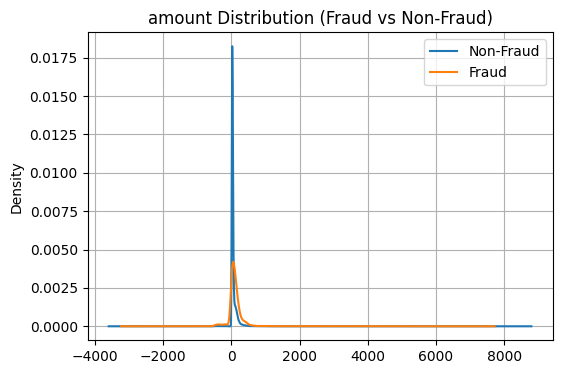

In [14]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["amount"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["amount"].plot(kind="kde", label="Fraud")

plt.title("amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

**log_abs_amount**

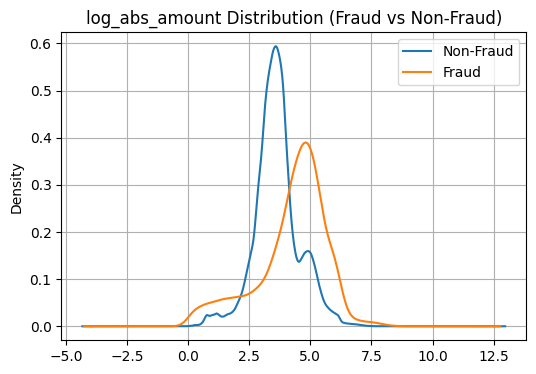

In [15]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["log_abs_amount"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["log_abs_amount"].plot(kind="kde", label="Fraud")

plt.title("log_abs_amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

### **1.2 Ratio Features**

**amount_income_ratio**

In [16]:
non_refund = df.loc[df["is_refund"] == 0].copy()
non_refund["log_amount_income_ratio"] = np.log1p(
    non_refund["amount_income_ratio"].values
)

In [17]:
non_refund["log_amount_income_ratio"].describe()

count    604932.000000
mean          0.001885
std           0.036119
min           0.000000
25%           0.000456
50%           0.000792
75%           0.001502
max           4.399251
Name: log_amount_income_ratio, dtype: float64

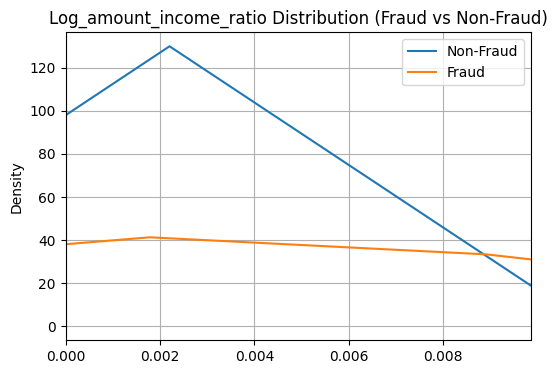

In [18]:
xmax = non_refund["log_amount_income_ratio"].quantile(0.99)
plt.figure(figsize=(6,4))
non_refund[non_refund["fraud"]==0]["log_amount_income_ratio"].plot(kind="kde", label="Non-Fraud")
non_refund[non_refund["fraud"]==1]["log_amount_income_ratio"].plot(kind="kde", label="Fraud")
plt.title(f"Log_amount_income_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.xlim(0, xmax)
plt.grid(True)
plt.show()

In [280]:
def find_best_split(df, col, y_col="fraud", min_count=1000):
    x = df[col].values
    y = df[y_col].values
    
    # 후보 threshold: 분위수 기반으로 촘촘히
    qs = np.linspace(0.01, 0.99, 200)
    thresholds = np.quantile(x, qs)
    
    best = None
    best_score = -np.inf
    
    for thr in thresholds:
        mask = x >= thr
        
        n1 = mask.sum()
        n0 = len(mask) - n1
        
        if n1 < min_count or n0 < min_count:
            continue
        
        rate1 = y[mask].mean()
        rate0 = y[~mask].mean()
        
        diff = abs(rate1 - rate0)
        
        if diff > best_score:
            best_score = diff
            best = {
                "threshold": thr,
                "rate_high": rate1,
                "rate_low": rate0,
                "diff": diff,
                "count_high": n1,
                "count_low": n0,
            }
    
    return best

best_split = find_best_split(df, "log_amount_income_ratio")
print(best_split)

{'threshold': np.float64(0.010429767575114964), 'rate_high': np.float64(0.08594905505341002), 'rate_low': np.float64(0.010035776838854808), 'diff': np.float64(0.07591327821455521), 'count_high': np.int64(6085), 'count_low': np.int64(602345)}


> threshold  ≈ 0.01043\
> count_high = 6,085   (≈ 전체의 1%)\
> rate_high  = 8.59%\
> rate_low   = 1.00%\
> diff       = 7.59%p

전체 base rate ≈ 1%

threshold 이상 구간은 fraud rate ≈ 8.6%

거의 8배 이상 위험

이건 단순 tail이 아니라
명확한 risk regime 전환 구간이 존재한다는 뜻.

In [281]:
df["income_ratio_risk_zone"] = (
    df["log_amount_income_ratio"] >= 0.01043
).astype("int8")

In [19]:
refund = df.loc[df["is_refund"]==1].copy()
refund["log_refund_income_ratio"] = np.log1p(refund["amount_income_ratio"].abs().values)

In [20]:
refund["log_refund_income_ratio"].describe()

count    3498.000000
mean        0.007489
std         0.013018
min         0.000005
25%         0.003860
50%         0.006152
75%         0.009118
max         0.547730
Name: log_refund_income_ratio, dtype: float64

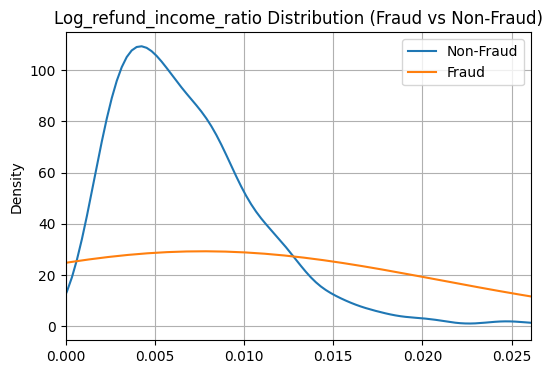

In [21]:
xmax = refund["log_refund_income_ratio"].quantile(0.99)
plt.figure(figsize=(6,4))
refund[refund["fraud"]==0]["log_refund_income_ratio"].plot(kind="kde", label="Non-Fraud")
refund[refund["fraud"]==1]["log_refund_income_ratio"].plot(kind="kde", label="Fraud")
plt.title(f"Log_refund_income_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.xlim(0, xmax)
plt.grid(True)
plt.show()

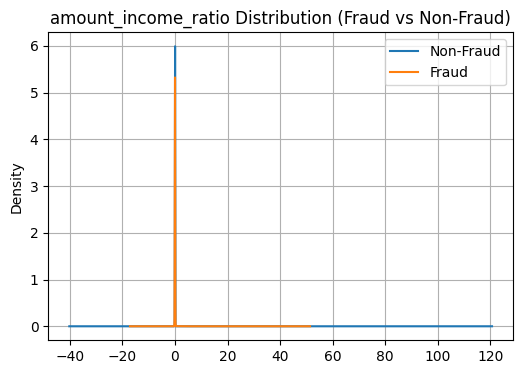

In [22]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["amount_income_ratio"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["amount_income_ratio"].plot(kind="kde", label="Fraud")

plt.title("amount_income_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2216042/2381857282.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("ratio_bin")["fraud"].mean()


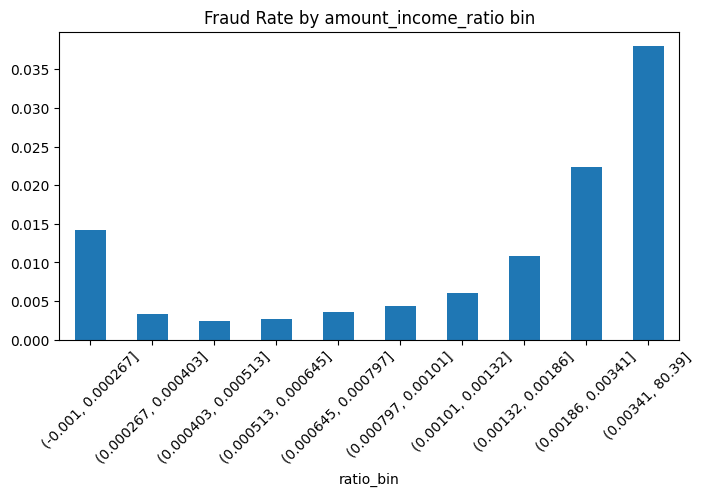

In [23]:
df["ratio_bin"] = pd.qcut(df["amount_income_ratio"], 10, duplicates="drop")

bin_rate = df.groupby("ratio_bin")["fraud"].mean()

bin_rate.plot(kind="bar", figsize=(8,4))
plt.title("Fraud Rate by amount_income_ratio bin")
plt.xticks(rotation=45)
plt.show()

> **소득 대비 매우 큰 결제일 때 fraud 확률 급상승**

**amount_limit_ratio**

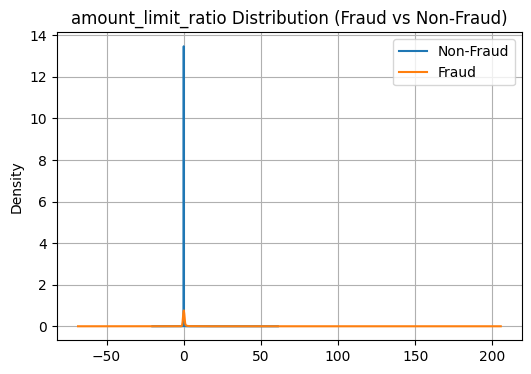

In [24]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["amount_limit_ratio"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["amount_limit_ratio"].plot(kind="kde", label="Fraud")

plt.title("amount_limit_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

> **한도 대비 과도한 사용 리스크 구조**

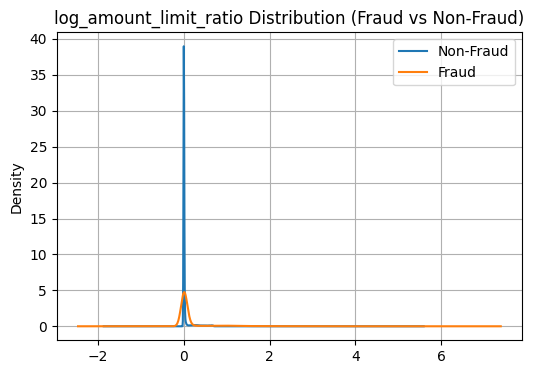

In [283]:
df["log_amount_limit_ratio"] = np.log1p(df["amount_limit_ratio"])

plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["log_amount_limit_ratio"].plot(
    kind="kde", label="Non-Fraud"
)
df[df["fraud"] == 1]["log_amount_limit_ratio"].plot(
    kind="kde", label="Fraud"
)

plt.title("log_amount_limit_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

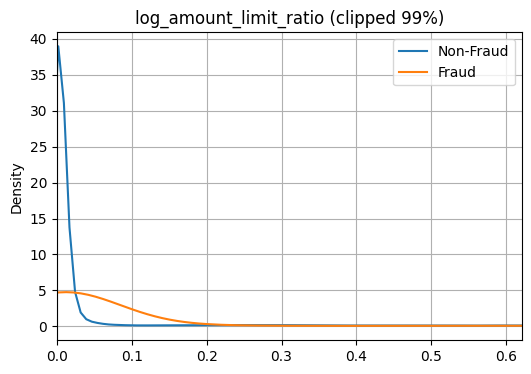

In [284]:
df["log_amount_limit_ratio"] = np.log1p(df["amount_limit_ratio"])

xmax = df["log_amount_limit_ratio"].quantile(0.99)

plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["log_amount_limit_ratio"].plot(
    kind="kde", label="Non-Fraud"
)
df[df["fraud"] == 1]["log_amount_limit_ratio"].plot(
    kind="kde", label="Fraud"
)

plt.xlim(0, xmax)
plt.title("log_amount_limit_ratio (clipped 99%)")
plt.legend()
plt.grid(True)
plt.show()

In [285]:
import statsmodels.api as sm
import numpy as np

X = sm.add_constant(df[["log_amount_limit_ratio"]])
y = df["fraud"]

model = sm.Logit(y, X).fit(disp=0)

coef = model.params["log_amount_limit_ratio"]
or_val = np.exp(coef)

print("OR:", or_val)
print("p-value:", model.pvalues["log_amount_limit_ratio"])

OR: 9.062863812274719
p-value: 0.0


In [286]:
# baseline lift
base_lift = top_decile_lift(y_base, s_base)

# add-one lift
feats = BASELINE + ["log_amount_limit_ratio"]
model, y2, score2 = fit_logit_and_score(df, feats)
new_lift = top_decile_lift(y2, score2)

print("baseline:", base_lift)
print("add-one:", new_lift)
print("delta lift:", new_lift["top_decile_lift"] - base_lift["top_decile_lift"])

baseline: {'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}
add-one: {'base_rate': 0.010794996959387276, 'top_decile_rate': 0.03898558585211117, 'top_decile_lift': 3.611449451887941, 'thr': 0.02071216997574563, 'top_n': 60843}
delta lift: -0.29993909866017043


**is_refund**

In [26]:
df.groupby("is_refund")[LABEL].mean()

is_refund
0    0.010345
1    0.088622
Name: fraud, dtype: float64

In [27]:
df.groupby("fraud")["is_refund"].mean()

fraud
0    0.005297
1    0.047199
Name: is_refund, dtype: float64

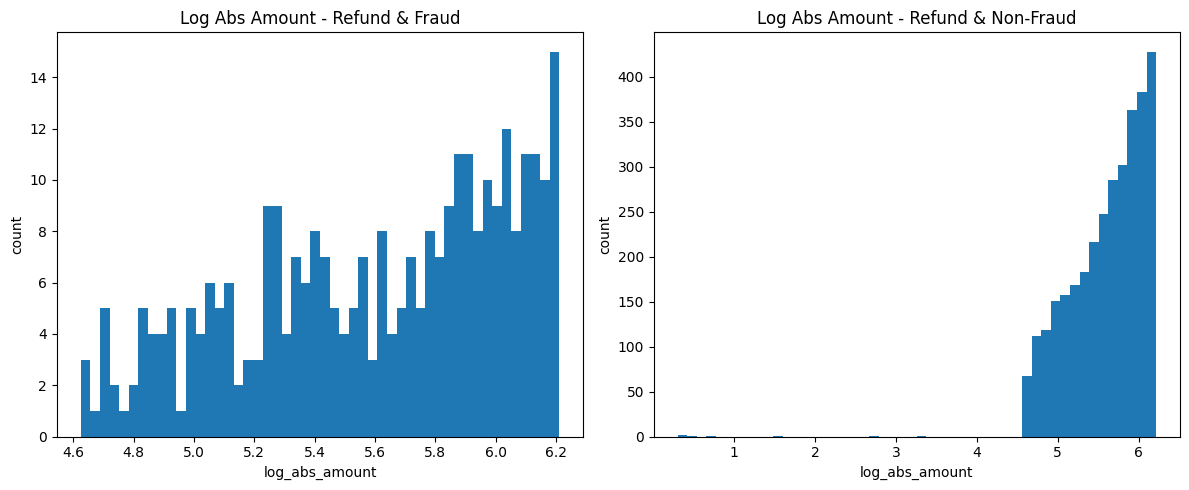

Mean amount (refund+fraud): -294.88388
Mean amount (refund+nonfraud): -296.57175


In [28]:
df_rf = df[(df["is_refund"] == 1) & (df["fraud"] == 1)]
df_rn = df[(df["is_refund"] == 1) & (df["fraud"] == 0)]

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(np.abs(df_rf["amount"])), bins=50)
plt.title("Log Abs Amount - Refund & Fraud")
plt.xlabel("log_abs_amount")
plt.ylabel("count")

plt.subplot(1, 2, 2)
plt.hist(np.log1p(np.abs(df_rn["amount"])), bins=50)
plt.title("Log Abs Amount - Refund & Non-Fraud")
plt.xlabel("log_abs_amount")
plt.ylabel("count")

plt.tight_layout()
plt.show()

print("Mean amount (refund+fraud):", df_rf["amount"].mean())
print("Mean amount (refund+nonfraud):", df_rn["amount"].mean())


> y축 scale 다름 주의 

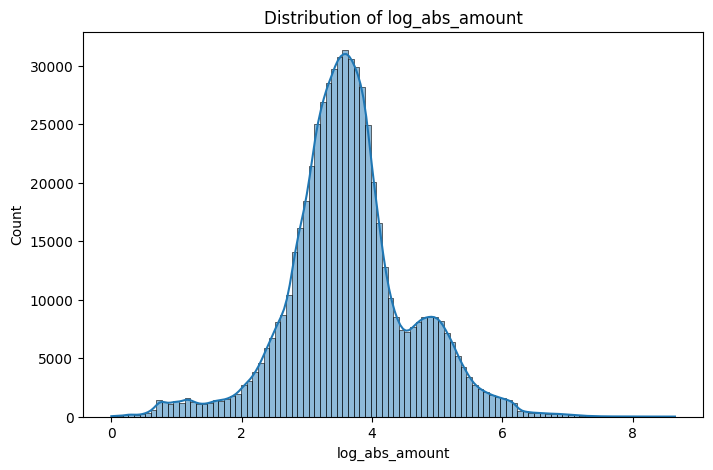

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["log_abs_amount"], bins=100, kde=True)
plt.title("Distribution of log_abs_amount")
plt.show()


/tmp/ipykernel_2216042/3721917751.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("amt_bin")["fraud"]


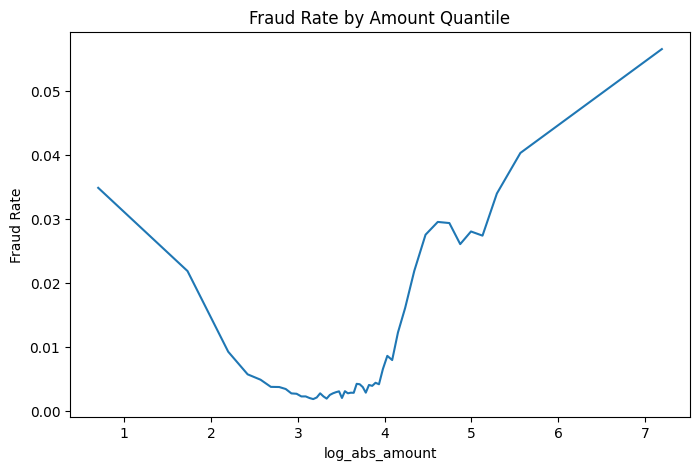

In [ ]:
tmp = df.copy()

tmp["amt_bin"] = pd.qcut(tmp["log_abs_amount"], q=50, duplicates="drop")

rate_table = (
    tmp.groupby("amt_bin")["fraud"]
       .agg(["mean","count"])
)

rate_table["mid"] = rate_table.index.map(lambda x: x.mid)

plt.figure(figsize=(8,5))
plt.plot(rate_table["mid"], rate_table["mean"])
plt.xlabel("log_abs_amount")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Amount Quantile")
plt.show()


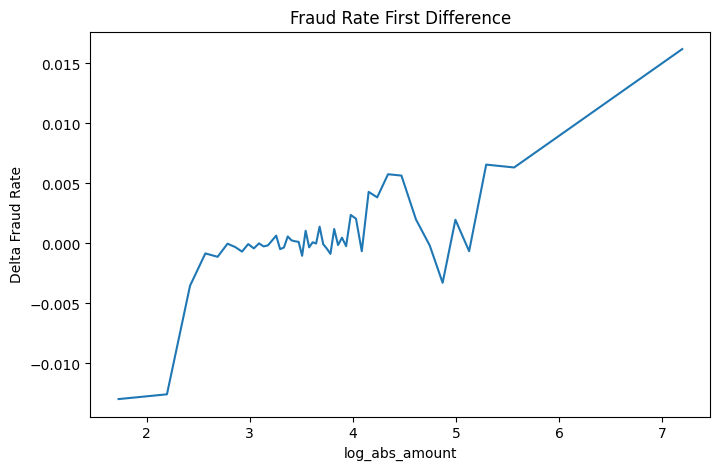

In [31]:
rate_table = rate_table.sort_values("mid")

rate_table["delta"] = rate_table["mean"].diff()

plt.figure(figsize=(8,5))
plt.plot(rate_table["mid"], rate_table["delta"])
plt.title("Fraud Rate First Difference")
plt.xlabel("log_abs_amount")
plt.ylabel("Delta Fraud Rate")
plt.show()


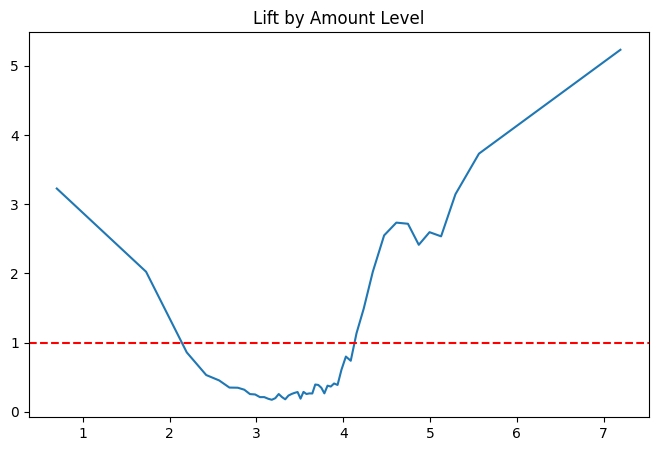

In [32]:
base_rate = df["fraud"].mean()

rate_table["lift"] = rate_table["mean"] / base_rate

plt.figure(figsize=(8,5))
plt.plot(rate_table["mid"], rate_table["lift"])
plt.axhline(1, color="red", linestyle="--")
plt.title("Lift by Amount Level")
plt.show()


In [33]:
lift_thr = 2

candidate = rate_table[rate_table["lift"] >= lift_thr]

if len(candidate) > 0:
    cutoff_mid = candidate.iloc[0]["mid"]
    print("Lift >= 2 최초 지점:", cutoff_mid)
else:
    print("조건 만족 구간 없음")


Lift >= 2 최초 지점: 0.6990000000000001


In [34]:
thr_value = 4.661

percentile = (df["log_abs_amount"] <= thr_value).mean()
print("해당 값의 분위:", percentile)

해당 값의 분위: 0.8568890422891705


In [35]:
thr_struct = 4.661
thr_q90 = df["log_abs_amount"].quantile(0.9)

print("구조 threshold:", thr_struct)
print("0.9 분위 threshold:", thr_q90)

구조 threshold: 4.661
0.9 분위 threshold: 4.932385444641113


In [36]:
thresholds = {
    "struct": 4.661,
    "q90": df["log_abs_amount"].quantile(0.9)
}

base = df["fraud"].mean()

for name, thr in thresholds.items():
    mask = df["log_abs_amount"] >= thr
    lift = df.loc[mask, "fraud"].mean() / base
    share = mask.mean()
    print(name, " | lift:", lift, "| 비율:", share)


struct  | lift: 3.1852664248443836 | 비율: 0.14311095771082952
q90  | lift: 3.4469025295300684 | 비율: 0.10000328714889141


In [37]:
thr = df["log_abs_amount"].quantile(0.9) # 위의 과정 바탕 0.9 사용
df["refund_high_amount"] = (
    (df["is_refund"] == 1) & (df["log_abs_amount"] > thr)
).astype("int8")

### **Statistical Validation (Quantitative Validation Layer)**

In [287]:
CANDIDATES = [
    "amount", 
    "log_abs_amount",
    "refund_high_amount",
    "income_ratio_risk_zone"
]


def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

for col in CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,log_abs_amount,0.645975,1.907846,0.000000e+00,0.037209,3.446903,60845
1,amount,0.002286,1.002288,0.000000e+00,0.033983,3.148030,60854
2,refund_high_amount,2.229449,9.294744,5.876450e-266,0.010795,1.000000,608430
3,income_ratio_risk_zone,2.227562,9.277224,0.000000e+00,0.010795,1.000000,608430


In [288]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in CANDIDATES:
    if col in BASELINE:
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,refund_high_amount,OK,1.091877,2.979863,7.757416e-56,0.010795,0.042207,3.909866,-0.000016,-0.001523,60843.0
1,amount,OK,0.000261,1.000261,8.606756e-04,0.010795,0.041928,3.883983,-0.000296,-0.027406,60843.0
2,income_ratio_risk_zone,OK,0.852155,2.344695,7.184729e-49,0.010795,0.041763,3.868758,-0.000460,-0.042631,60843.0
3,log_abs_amount,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Block 1: Amount / Income / Refund

### 1. 유지

| Feature            | 판단 | 근거                                   |
| ------------------ | -- | ------------------------------------ |
| log_abs_amount     | 유지 | 연속형 기반의 강한 기본 리스크 변수이며 Baseline 핵심 축 |
| refund_high_amount | 유지 | Baseline 변수로 설명되지 않는 독립적 정보 포함       |

---

### 2. 제거

| Feature | 판단 | 근거                    |
| ------- | -- | --------------------- |
| amount  | 제거 | log_abs_amount와 정보 중복 |

---

### 3. Interaction 후보

| Feature                | 판단                 | 근거                                           |
| ---------------------- | ------------------ | -------------------------------------------- |
| income_ratio_risk_zone | Interaction 후보     | Threshold 기반 이진 변수로 단독 분리력은 낮으나 구간 효과 가능성 존재 |
| refund_high_amount     | Interaction 가능성 보류 | 고액 거래와 결합 시 구조적 교차 효과 가능성 존재                 |

---


---
# 2. Error Behavior Block

> 실패/에러 기반 이상행동 탐지

## 2.1 Error Presence

- has_error

## 2.2 Error Type Breakdown

- err_bad_card_number

- err_bad_expiration

- err_bad_cvv

- err_bad_pin

- err_bad_zipcode

- err_insufficient_balance

- err_technical_glitch

## 2.3 Error Interaction / Burst (파생)

- error_count

- error_high_amount

- client_error_last1

- client_error_last3

- card_error_last1

- card_error_last3

- client_hist_x_error

## 2.4 Statistical Validation

---

### **2.1 Error Presence**
**has_error**

In [40]:
df.groupby("has_error")["fraud"].value_counts()

has_error  fraud
0          0        588169
           1          6277
1          0         13693
           1           291
Name: count, dtype: int64

In [41]:
error_ratio = (
    df
    .groupby("has_error")["fraud"]
    .mean()
)
error_ratio

has_error
0    0.010559
1    0.020809
Name: fraud, dtype: float64

> has error의 비율이 더 높음 _ error fraud 비례 가설 적중

### **2.2 Error Type Breakdown**

- `err_bad_card_number`
- `err_bad_expiration`
- `err_bad_cvv`
- `err_bad_pin`
- `err_bad_zipcode`
- `err_insufficient_balance`
- `err_technical_glitch`

In [42]:
err_cols = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_bad_pin",
    "err_bad_zipcode",
    "err_insufficient_balance",
    "err_technical_glitch"
]

err_ratio = (
    df.groupby("fraud")[err_cols]
      .mean()
      .T
)

err_ratio

fraud,0,1
err_bad_card_number,0.005152,0.007004
err_bad_expiration,0.004074,0.005481
err_bad_cvv,0.003891,0.016291
err_bad_pin,0.000000,0.000000
err_bad_zipcode,0.000000,0.000000
err_insufficient_balance,0.007787,0.013551
err_technical_glitch,0.002092,0.002436


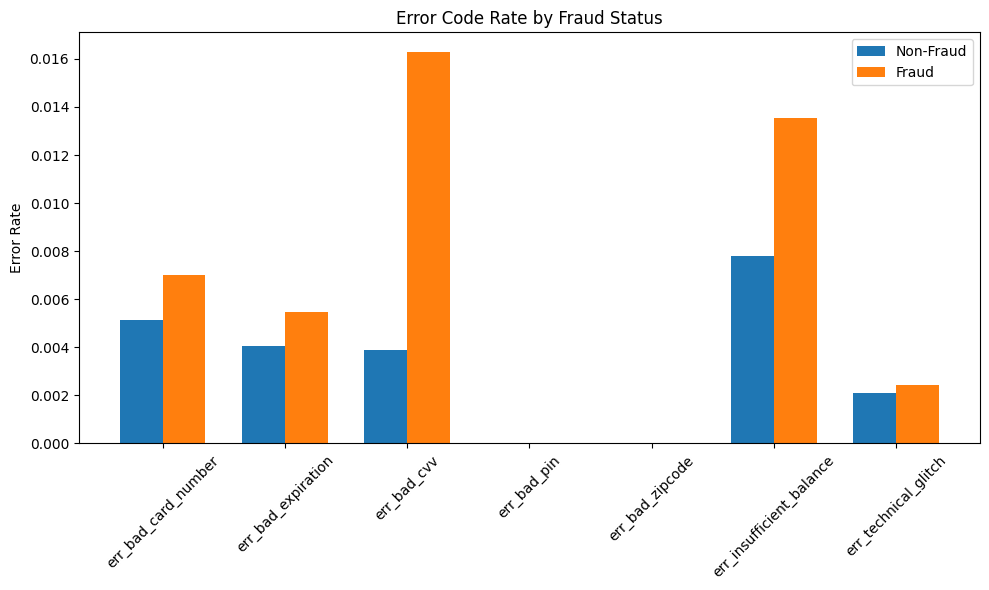

In [43]:
x = np.arange(len(err_cols))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, err_ratio[0], width, label="Non-Fraud")
plt.bar(x + width/2, err_ratio[1], width, label="Fraud")

plt.xticks(x, err_ratio.index, rotation=45)
plt.ylabel("Error Rate")
plt.title("Error Code Rate by Fraud Status")
plt.legend()
plt.tight_layout()
plt.show()

### **2.3 Error Interaction / Burst**

In [44]:
def interaction_report(df, x, y, label="fraud", baseline_col=0, min_count=50):
    # (A) rate / count
    rate = df.pivot_table(index=x, columns=y, values=label, aggfunc="mean", observed=False)
    cnt  = df.pivot_table(index=x, columns=y, values=label, aggfunc="size", observed=False).fillna(0).astype(int)

    print(f"\n=== Interaction: {x} x {y} ===")
    print("Fraud rate:")
    display(rate.round(6))
    print("Count:")
    display(cnt)

    # (B) uplift (row-wise)
    if baseline_col in rate.columns:
        base = rate[baseline_col].replace(0, np.nan)
        uplift = rate.div(base, axis=0).round(2) 
        print(f"Uplift vs {y}={baseline_col} within each {x}:")
        display(uplift)

    # (C) Heatmap (optionally mask low-count cells)
    masked = rate.copy()
    masked[cnt < min_count] = np.nan  # 표본 너무 적은 칸은 해석 금지

    plt.figure(figsize=(6, 3.8))
    im = plt.imshow(masked.values, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(masked.columns)), [str(c) for c in masked.columns])
    plt.yticks(range(len(masked.index)), [str(i) for i in masked.index])
    plt.xlabel(y)
    plt.ylabel(x)
    plt.title(f"Fraud rate heatmap: {x} x {y}")

    for i in range(masked.shape[0]):
        for j in range(masked.shape[1]):
            v = masked.values[i, j]
            if pd.notna(v):
                plt.text(j, i, f"{v:.4f}", ha="center", va="center")
            else:
                # low count 등으로 마스킹된 칸 표시
                if cnt.values[i, j] < min_count:
                    plt.text(j, i, f"n<{min_count}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


In [45]:
g = df.groupby("client_id")["has_error"]
df["client_error_last1"] = g.shift(1).fillna(0).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
df["client_error_last3"] = (e1 + e2 + e3).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
e4 = g.shift(4).fillna(0).astype("int8")
e5 = g.shift(5).fillna(0).astype("int8")
df["client_error_last5"] = (e1 + e2 + e3 + e4 + e5).astype("int8")

In [46]:
df["client_fraud_cum_prev"] = (
    df.groupby("client_id")["fraud"]
      .cumsum()
      .shift(1)
      .fillna(0)
      .astype("int32")
)

df["card_fraud_cum_prev"] = (
    df.groupby("card_id")["fraud"]
      .cumsum()
      .shift(1)
      .fillna(0)
      .astype("int32")
)

# client/card 누적 fraud bin (현재행 제외 기준)
df["client_fraud_hist_bin"] = pd.cut(
    df["client_fraud_cum_prev"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)

df["card_fraud_hist_bin"] = pd.cut(
    df["card_fraud_cum_prev"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)


=== Interaction: client_fraud_hist_bin x has_error ===
Fraud rate:


has_error,0,1
client_fraud_hist_bin,,
0,0.010109,0.019260
1,0.013565,0.025510
2,0.014924,0.009217
3+,0.010924,0.023759


Count:


has_error,0,1
client_fraud_hist_bin,,
0,368281,8619
1,16882,392
2,9716,217
3+,199567,4756


Uplift vs has_error=0 within each client_fraud_hist_bin:


has_error,0,1
client_fraud_hist_bin,,
0,1.0,1.91
1,1.0,1.88
2,1.0,0.62
3+,1.0,2.18


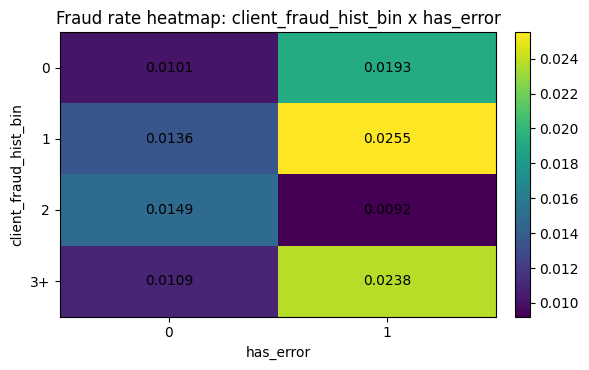


=== Interaction: client_fraud_hist_bin x client_error_last1 ===
Fraud rate:


client_error_last1,0,1
client_fraud_hist_bin,,
0,0.010190,0.015778
1,0.013523,0.026570
2,0.014614,0.023148
3+,0.011053,0.018503


Count:


client_error_last1,0,1
client_fraud_hist_bin,,
0,368217,8683
1,16860,414
2,9717,216
3+,199675,4648


Uplift vs client_error_last1=0 within each client_fraud_hist_bin:


client_error_last1,0,1
client_fraud_hist_bin,,
0,1.0,1.55
1,1.0,1.96
2,1.0,1.58
3+,1.0,1.67


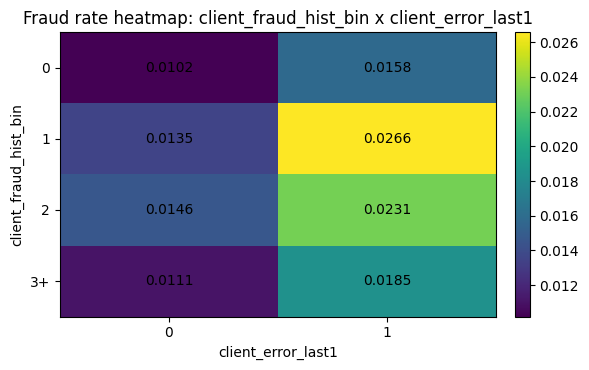


=== Interaction: client_fraud_hist_bin x client_error_last3 ===
Fraud rate:


client_error_last3,0,1,2,3
client_fraud_hist_bin,,,,
0,0.009981,0.014929,0.019403,0.0
1,0.013196,0.022090,0.031250,NaN
2,0.013688,0.029641,0.071429,NaN
3+,0.010793,0.016888,0.028902,0.0


Count:


client_error_last3,0,1,2,3
client_fraud_hist_bin,,,,
0,351777,24449,670,4
1,16065,1177,32,0
2,9278,641,14,0
3+,190591,13382,346,4


Uplift vs client_error_last3=0 within each client_fraud_hist_bin:


client_error_last3,0,1,2,3
client_fraud_hist_bin,,,,
0,1.0,1.50,1.94,0.0
1,1.0,1.67,2.37,NaN
2,1.0,2.17,5.22,NaN
3+,1.0,1.56,2.68,0.0


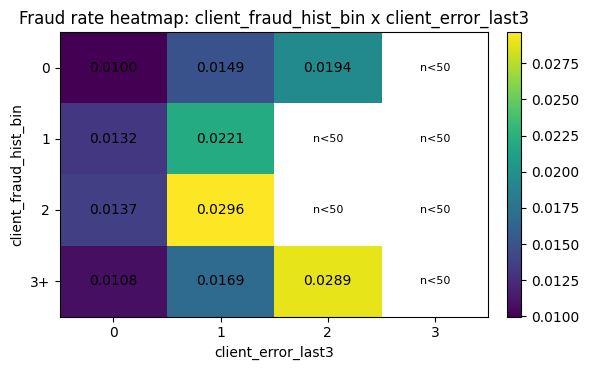

In [47]:
interaction_report(df, "client_fraud_hist_bin", "has_error")
interaction_report(df, "client_fraud_hist_bin", "client_error_last1")
interaction_report(df, "client_fraud_hist_bin", "client_error_last3")

In [48]:
g = df.groupby("card_id")["has_error"]
df["card_error_last1"] = g.shift(1).fillna(0).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
df["card_error_last3"] = (e1 + e2 + e3).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
e4 = g.shift(4).fillna(0).astype("int8")
e5 = g.shift(5).fillna(0).astype("int8")
df["card_error_last5"] = (e1 + e2 + e3 + e4 + e5).astype("int8")


=== Interaction: card_fraud_hist_bin x has_error ===
Fraud rate:


has_error,0,1
card_fraud_hist_bin,,
0,0.009963,0.019713
1,0.015835,0.034375
2,0.016790,0.026316
3+,0.012597,0.024537


Count:


has_error,0,1
card_fraud_hist_bin,,
0,488891,11515
1,14083,320
2,7326,152
3+,84146,1997


Uplift vs has_error=0 within each card_fraud_hist_bin:


has_error,0,1
card_fraud_hist_bin,,
0,1.0,1.98
1,1.0,2.17
2,1.0,1.57
3+,1.0,1.95


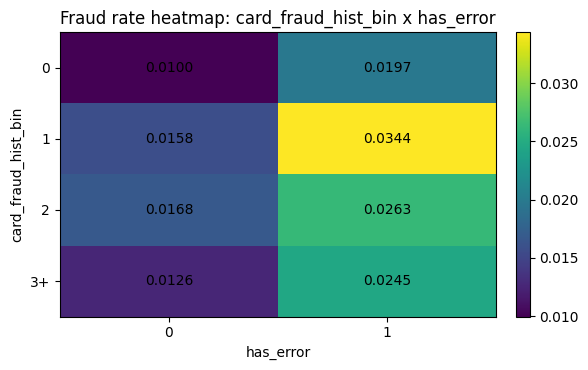


=== Interaction: card_fraud_hist_bin x card_error_last1 ===
Fraud rate:


card_error_last1,0,1
card_fraud_hist_bin,,
0,0.010017,0.017498
1,0.015753,0.038710
2,0.017246,0.005814
3+,0.012763,0.017579


Count:


card_error_last1,0,1
card_fraud_hist_bin,,
0,488976,11430
1,14093,310
2,7306,172
3+,84152,1991


Uplift vs card_error_last1=0 within each card_fraud_hist_bin:


card_error_last1,0,1
card_fraud_hist_bin,,
0,1.0,1.75
1,1.0,2.46
2,1.0,0.34
3+,1.0,1.38


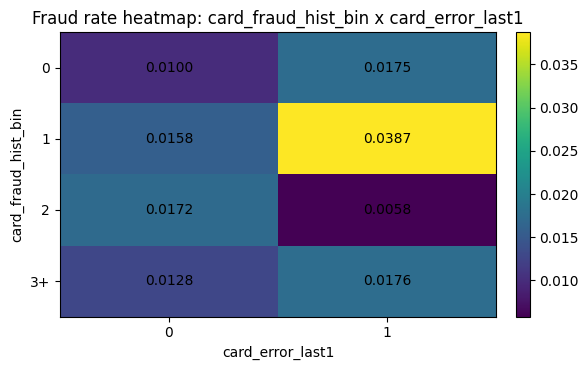


=== Interaction: card_fraud_hist_bin x card_error_last3 ===
Fraud rate:


card_error_last3,0,1,2,3
card_fraud_hist_bin,,,,
0,0.009831,0.015072,0.021053,0.0
1,0.015252,0.029598,0.062500,NaN
2,0.016549,0.021442,0.062500,NaN
3+,0.012391,0.019124,0.036364,0.0


Count:


card_error_last3,0,1,2,3
card_fraud_hist_bin,,,,
0,467298,32245,855,8
1,13441,946,16,0
2,6949,513,16,0
3+,80382,5595,165,1


Uplift vs card_error_last3=0 within each card_fraud_hist_bin:


card_error_last3,0,1,2,3
card_fraud_hist_bin,,,,
0,1.0,1.53,2.14,0.0
1,1.0,1.94,4.10,NaN
2,1.0,1.30,3.78,NaN
3+,1.0,1.54,2.93,0.0


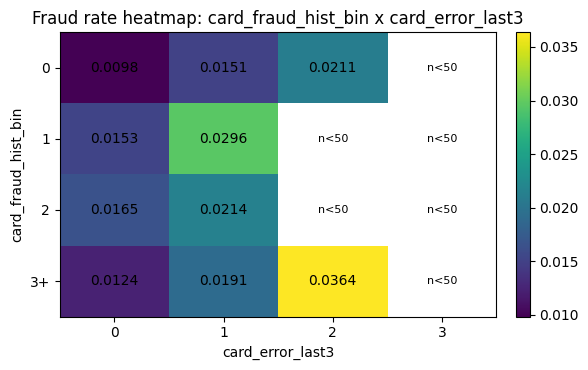

In [49]:
interaction_report(df, "card_fraud_hist_bin", "has_error")
interaction_report(df, "card_fraud_hist_bin", "card_error_last1")
interaction_report(df, "card_fraud_hist_bin", "card_error_last3")

In [50]:
df["client_has_fraud_history"] = (
    df["client_fraud_cum_prev"] > 0
).astype("int8")
df["card_has_fraud_history"] = (
    df["card_fraud_cum_prev"] > 0
).astype("int8")

In [51]:
df["client_hist_x_error"] = (
    df["client_has_fraud_history"] * df["has_error"]
)
df["card_hist_x_error"] = (
    df["card_has_fraud_history"] * df["card_error_last1"]
)

### **2.4 Statistical Validation (Quantitative Validation Layer)**

In [326]:
ERROR_TYPES = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_bad_pin",
    "err_bad_zipcode",
    "err_insufficient_balance",
    "err_technical_glitch",
    "client_has_fraud_history",
    "card_has_fraud_history",
    "client_hist_x_error",
    "card_hist_x_error"
]

for i in ERROR_TYPES:
    print(df[i].value_counts())

err_bad_card_number
0    605283
1      3147
Name: count, dtype: int64
err_bad_expiration
0    605942
1      2488
Name: count, dtype: int64
err_bad_cvv
0    605981
1      2449
Name: count, dtype: int64
err_bad_pin
0    608430
Name: count, dtype: int64
err_bad_zipcode
0    608430
Name: count, dtype: int64
err_insufficient_balance
0    603654
1      4776
Name: count, dtype: int64
err_technical_glitch
0    607155
1      1275
Name: count, dtype: int64
client_has_fraud_history
0    376900
1    231530
Name: count, dtype: int64
card_has_fraud_history
0    500406
1    108024
Name: count, dtype: int64
client_hist_x_error
0    603065
1      5365
Name: count, dtype: int64
card_hist_x_error
0    605957
1      2473
Name: count, dtype: int64


In [329]:
ERROR_PRESENCE = ["has_error"]

ERROR_TYPES = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_insufficient_balance",
    "err_technical_glitch",
    "client_hist_x_error",
    "card_hist_x_error"
]

ERROR_CANDIDATES = ERROR_PRESENCE + ERROR_TYPES
ERROR_CANDIDATES = [c for c in ERROR_CANDIDATES if c in df.columns]

print("Error candidates used:", ERROR_CANDIDATES)


# 1) util

def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }


# 2) (A) 단변량 검증

rows_uni = []

for col in ERROR_CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)
    lift = top_decile_lift(y, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

print("\n=== Univariate (Error Block) ===")
display(uni_df)


# 3) (B) Baseline + add-one (다변량 incremental)

base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("\n=== BASELINE ===")
print(base_lift)

rows_inc = []

for col in ERROR_CANDIDATES:
    if col in BASELINE:
        rows_inc.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]
    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows_inc.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows_inc)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

print("\n=== Multivariate Add-one vs BASELINE (Error Block) ===")
display(inc_df)


Error candidates used: ['has_error', 'err_bad_card_number', 'err_bad_expiration', 'err_bad_cvv', 'err_insufficient_balance', 'err_technical_glitch', 'client_hist_x_error', 'card_hist_x_error']

=== Univariate (Error Block) ===


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,has_error,0.688805,1.991335,5.942531e-30,0.010795,1.0,608430
1,err_bad_card_number,0.308843,1.361848,3.826141e-02,0.010795,1.0,608430
2,err_bad_expiration,0.298092,1.347286,7.660855e-02,0.010795,1.0,608430
3,err_bad_cvv,1.444414,4.239365,1.293118e-47,0.010795,1.0,608430
4,err_insufficient_balance,0.559732,1.750204,2.038510e-07,0.010795,1.0,608430
5,err_technical_glitch,0.152679,1.164952,5.444247e-01,0.010795,1.0,608430
6,client_hist_x_error,0.792526,2.208970,4.164450e-18,0.010795,1.0,608430
7,card_hist_x_error,0.598731,1.819807,4.262551e-05,0.010795,1.0,608430



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}

=== Multivariate Add-one vs BASELINE (Error Block) ===


,added_feature,status,coef,OR,p_value,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_hist_x_error,OK,0.575705,1.778383,9.173616e-05,0.042355,3.923569,0.000131,0.012180,60843.0
1,err_bad_card_number,OK,-0.349565,0.704994,3.331684e-02,0.042338,3.922046,0.000115,0.010658,60843.0
2,client_hist_x_error,OK,0.206422,1.229271,8.783793e-02,0.042256,3.914434,0.000033,0.003045,60843.0
3,err_technical_glitch,OK,-0.548719,0.577690,3.970301e-02,0.042223,3.911389,0.000000,0.000000,60843.0
4,err_bad_expiration,OK,-0.315589,0.729359,8.100200e-02,0.042174,3.906821,-0.000049,-0.004568,60843.0
5,err_bad_cvv,OK,1.086882,2.965014,5.020901e-18,0.042076,3.897686,-0.000148,-0.013703,60843.0
6,err_insufficient_balance,OK,-0.363753,0.695063,4.940961e-03,0.042076,3.897686,-0.000148,-0.013703,60843.0
7,has_error,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Block: Error + Error × History

### 1. 유지 (Main Effect 유지)

| Feature           | 판단 | 근거                                       |
| ----------------- | -- | ---------------------------------------- |
| has_error         | 유지 | 에러 존재 자체가 강한 기본 리스크 신호로 Baseline 핵심 축    |
| err_bad_cvv       | 유지 | 단변량·다변량 모두에서 강한 독립 리스크 유지                |
| card_hist_x_error | 유지 | Baseline 이후에도 안정적 유의성 유지 및 lift 개선 효과 확인 |

---

### 2. 조건부 유지 / Interaction 검토

| Feature                  | 판단             | 근거                                  |
| ------------------------ | -------------- | ----------------------------------- |
| client_hist_x_error      | 조건부 유지         | 단변량에서는 강하나 다변량에서 약화 → 일부 변수에 흡수 가능성 |
| err_bad_card_number      | Interaction 후보 | 다변량에서 계수 방향 반전 → 맥락 의존형 신호 가능성      |
| err_insufficient_balance | Interaction 후보 | 다변량에서 보호 효과 방향 전환 → 구조적 상호작용 가능성    |

---

### 3. 제거

| Feature              | 판단 | 근거                          |
| -------------------- | -- | --------------------------- |
| err_technical_glitch | 제거 | 단·다변량 모두 영향 미미, 구조적 노이즈 가능성 |
| err_bad_expiration   | 제거 | 일관되게 약한 영향                  |

---

## Error 블록 구조 요약

### 핵심 리스크 축

* has_error
* err_bad_cvv
* card_hist_x_error

### 맥락 의존형 (Interaction 유력)

* err_bad_card_number
* err_insufficient_balance
* client_hist_x_error (흡수 여부 추가 검증 필요)

---


In [ ]:
ERR_BLOCK = [c for c in (ERROR_TYPES) if c in df.columns]

model_errblock, y_e, s_e = fit_logit_and_score(df, BASELINE + ERR_BLOCK, y_col=LABEL)
lift_errblock = top_decile_lift(y_e, s_e)

print("\n=== BASELINE + Error Type Block ===")
print(lift_errblock)
print("Δlift vs beline:", lift_errblock["top_decile_lift"] - base_lift["top_decile_lift"])


=== BASELINE + Error Type Block ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04209194155449271, 'top_decile_lift': 3.8992082825822165, 'thr': 0.020360782704595706, 'top_n': 60843}
Δlift vs baseline: -0.012180267965895109


/tmp/ipykernel_2216042/2809418986.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["amount_bin", "has_error"])["fraud"]


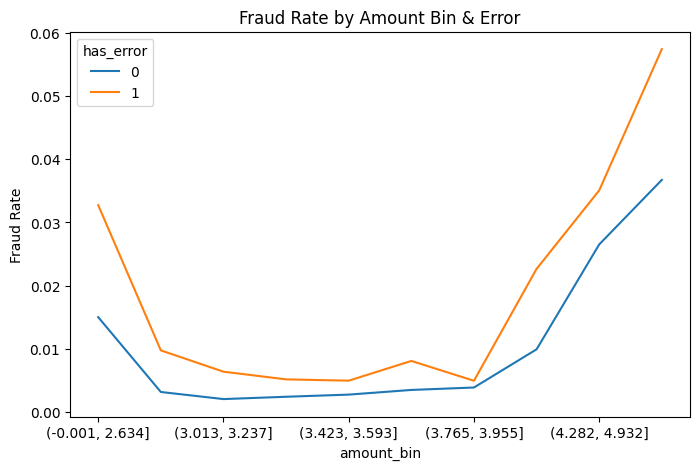

In [56]:
# error 유무별 fraud rate vs amount 구간 비교

df["amount_bin"] = pd.qcut(df["log_abs_amount"], 10, duplicates="drop")

pivot = (
    df.groupby(["amount_bin", "has_error"])["fraud"]
      .mean()
      .unstack()
)

pivot.plot(figsize=(8,5))
plt.title("Fraud Rate by Amount Bin & Error")
plt.ylabel("Fraud Rate")
plt.show()

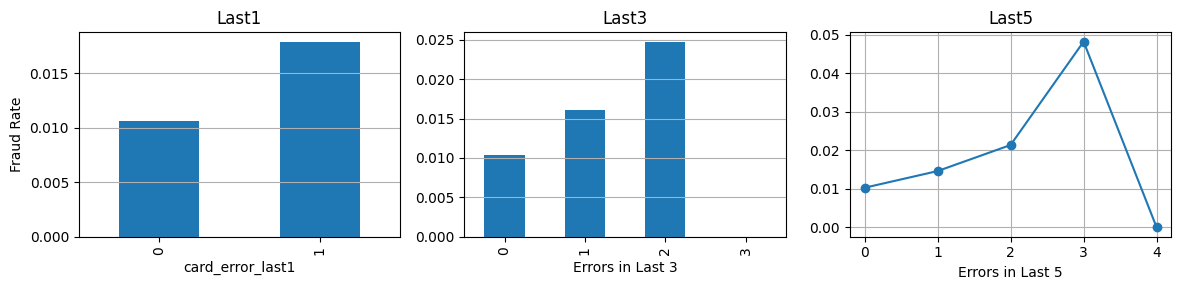

In [57]:
rate_last1 = df.groupby("card_error_last1")["fraud"].mean()
rate_last3 = df.groupby("card_error_last3")["fraud"].mean()
rate_last5 = df.groupby("card_error_last5")["fraud"].mean()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

rate_last1.plot(kind="bar", ax=axes[0])
axes[0].set_title("Last1")
axes[0].set_xlabel("card_error_last1")
axes[0].set_ylabel("Fraud Rate")
axes[0].grid(axis="y")

rate_last3.plot(kind="bar", ax=axes[1])
axes[1].set_title("Last3")
axes[1].set_xlabel("Errors in Last 3")
axes[1].grid(axis="y")

axes[2].plot(rate_last5.index, rate_last5.values, marker="o")
axes[2].set_title("Last5")
axes[2].set_xlabel("Errors in Last 5")
axes[2].grid(True)

plt.tight_layout()
plt.show()


In [290]:
df["card_error_last3"].value_counts()

card_error_last3
0    568070
1     39299
2      1052
3         9
Name: count, dtype: int64

In [58]:
col = [
    "client_error_last1",
    "client_error_last3",
    "client_error_last5",
    "card_error_last1",
    "card_error_last3",
    "card_error_last5",
]

for c in col:
    table = (
        df.groupby(["tx_year", c])["fraud"]
          .mean()
          .unstack()
          .round(4)
    )
    
    print(f"\n===== {c} =====")
    display(table)


===== client_error_last1 =====


client_error_last1,0,1
tx_year,,
2010,0.0253,0.0442
2011,0.0004,0.0005
2012,0.0070,0.0068
2013,0.0105,0.0181
2014,0.0051,0.0098
2015,0.0161,0.0250



===== client_error_last3 =====


client_error_last3,0,1,2,3
tx_year,,,,
2010,0.0248,0.0384,0.0581,NaN
2011,0.0004,0.0005,0.0000,0.0
2012,0.0069,0.0084,0.0000,NaN
2013,0.0102,0.0170,0.0355,0.0
2014,0.0049,0.0095,0.0107,0.0
2015,0.0158,0.0237,0.0417,0.0



===== client_error_last5 =====


...

card_error_last1,0,1
tx_year,,
2010,0.0252,0.0457
2011,0.0004,0.0005
2012,0.0070,0.0072
2013,0.0105,0.0186
2014,0.0051,0.0099
2015,0.0161,0.0270



===== card_error_last3 =====


card_error_last3,0,1,2,3
tx_year,,,,
2010,0.0245,0.0427,0.0552,NaN
2011,0.0004,0.0005,0.0000,NaN
2012,0.0070,0.0063,0.0000,NaN
2013,0.0102,0.0166,0.0220,0.0
2014,0.0049,0.0084,0.0330,0.0
2015,0.0157,0.0247,0.0392,0.0



===== card_error_last5 =====


card_error_last5,0,1,2,3,4
tx_year,,,,,
2010,0.0242,0.0384,0.0596,0.1667,NaN
2011,0.0004,0.0003,0.0000,0.0000,NaN
2012,0.0072,0.0056,0.0041,0.0000,NaN
2013,0.0101,0.0148,0.0197,0.0000,0.0
2014,0.0048,0.0081,0.0214,0.0000,0.0
2015,0.0154,0.0233,0.0290,0.1429,0.0


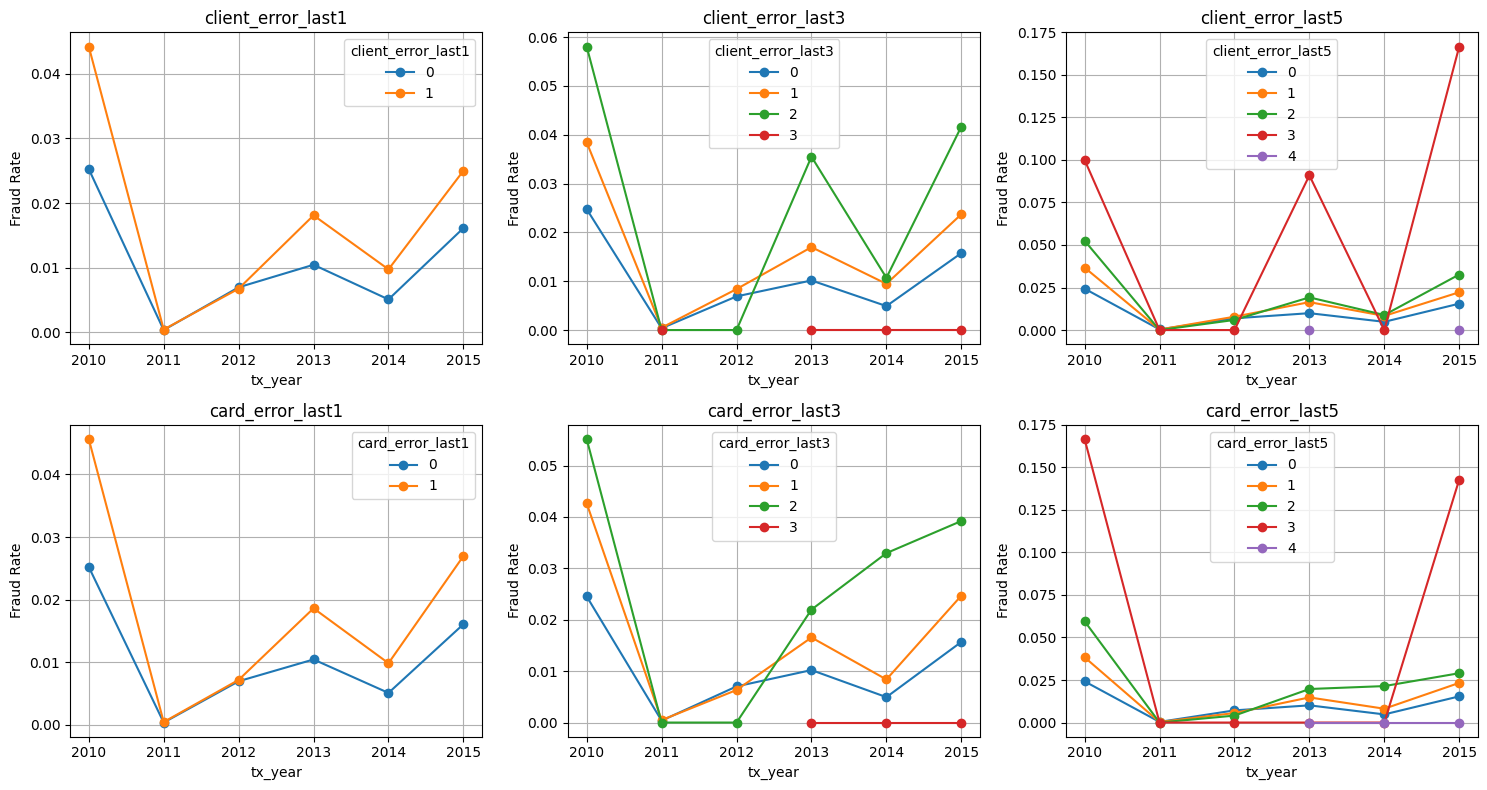

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, c in enumerate(col):
    pivot = (
        df.groupby(["tx_year", c])["fraud"]
          .mean()
          .unstack()
    )
    
    pivot.plot(ax=axes[i], marker="o")
    axes[i].set_title(c)
    axes[i].set_ylabel("Fraud Rate")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


In [60]:
cols = [
    "client_error_last1",
    "client_error_last3",
    "card_error_last1",
    "card_error_last3",
]

result = []

for c in cols:
    for year in sorted(df["tx_year"].unique()):
        sub = df[df["tx_year"] == year]
        
        base = sub[sub[c] == 0]["fraud"].mean()
        burst = sub[sub[c] >= 1]["fraud"].mean()
        
        uplift = burst / base if base > 0 else None
        
        result.append({
            "feature": c,
            "tx_year": year,
            "uplift": round(uplift, 2) if uplift else None
        })

uplift_all = pd.DataFrame(result)
display(uplift_all.pivot(index="tx_year", columns="feature", values="uplift"))


feature,card_error_last1,card_error_last3,client_error_last1,client_error_last3
tx_year,,,,
2010,1.81,1.75,1.75,1.57
2011,1.22,1.26,1.21,1.26
2012,1.03,0.88,0.97,1.19
2013,1.78,1.63,1.73,1.72
2014,1.93,1.82,1.91,1.93
2015,1.68,1.60,1.55,1.53


In [61]:
error_cols = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_bad_pin",
    "err_bad_zipcode",
    "err_insufficient_balance",
    "err_technical_glitch"
]

df["error_count"] = df[error_cols].sum(axis=1)

In [62]:
df.groupby("error_count")["log_abs_amount"].mean()

error_count
0    3.643297
1    3.801359
2    4.054979
3    4.142182
Name: log_abs_amount, dtype: float32

In [63]:
df.groupby(["error_count", "fraud"])["log_abs_amount"].mean().unstack()

fraud,0,1
error_count,,
0,3.636876,4.244958
1,3.792805,4.203688
2,4.031517,5.196802
3,4.142182,NaN


In [64]:
df["error_amount_interaction"] = (
    df["error_count"] * df["log_abs_amount"]
)

In [65]:
base = df["fraud"].mean()

for q in [0.8, 0.85, 0.9, 0.95]:
    threshold = df["log_abs_amount"].quantile(q)
    rate = df[df["log_abs_amount"] >= threshold]["fraud"].mean()
    print(q, rate / base)


0.8 2.967320242956759
0.85 3.1596087232546473
0.9 3.4469025295300684
0.95 4.259838680211935


In [66]:
threshold = df["log_abs_amount"].quantile(0.9)

df["high_amount"] = (df["log_abs_amount"] >= threshold).astype("int8")

df["error_high_amount"] = (
    (df["error_count"] >= 2) &
    (df["high_amount"] == 1)
).astype("int8")

In [67]:
df["card_err1_x_amount"] = (
    df["card_error_last1"] * df["log_abs_amount"]
)

df["card_hist_err_x_amount"] = (
    df["card_hist_x_error"] * df["log_abs_amount"]
)

In [70]:
# for i in ERROR_CANDIDATES:
#     print(df[i].value_counts())

has_error
0    594446
1     13984
Name: count, dtype: int64
err_bad_card_number
0    605283
1      3147
Name: count, dtype: int64
err_bad_expiration
0    605942
1      2488
Name: count, dtype: int64
err_bad_cvv
0    605981
1      2449
Name: count, dtype: int64
err_bad_pin
0    608430
Name: count, dtype: int64
err_bad_zipcode
0    608430
Name: count, dtype: int64
err_insufficient_balance
0    603654
1      4776
Name: count, dtype: int64
err_technical_glitch
0    607155
1      1275
Name: count, dtype: int64
client_error_last1
0    594469
1     13961
Name: count, dtype: int64
client_error_last3
0    567711
1     39649
2      1062
3         8
Name: count, dtype: int64
client_error_last5
0    542253
1     62936
2      3168
3        68
4         5
Name: count, dtype: int64
card_error_last1
0    594527
1     13903
Name: count, dtype: int64
card_error_last3
0    568070
1     39299
2      1052
3         9
Name: count, dtype: int64
card_error_last5
0    543236
1     61923
2      3181
3        83

In [71]:

ERROR_PRESENCE = ["has_error"]

ERROR_TYPES = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_insufficient_balance",
    "err_technical_glitch",
]

ERROR_INTERACTIONS = [
    "client_error_last1",
    "client_error_last3",
    "client_error_last5",
    "card_error_last1",
    "card_error_last3",
    "card_error_last5",
    "client_hist_x_error",
    "card_hist_x_error",
]

ERROR_CANDIDATES = ERROR_PRESENCE + ERROR_TYPES + ERROR_INTERACTIONS

ERROR_CANDIDATES = [c for c in ERROR_CANDIDATES if c in df.columns]

print("Error candidates used:", ERROR_CANDIDATES)


# 1) util

def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }


# 2) (A) 단변량 검증

rows_uni = []

for col in ERROR_CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)
    lift = top_decile_lift(y, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

print("\n=== Univariate (Error Block) ===")
display(uni_df)


# 3) (B) Baseline + add-one (다변량 incremental)

base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("\n=== BASELINE ===")
print(base_lift)

rows_inc = []

for col in ERROR_CANDIDATES:
    if col in BASELINE:
        rows_inc.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]
    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows_inc.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows_inc)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

print("\n=== Multivariate Add-one vs BASELINE (Error Block) ===")
display(inc_df)


Error candidates used: ['has_error', 'err_bad_card_number', 'err_bad_expiration', 'err_bad_cvv', 'err_insufficient_balance', 'err_technical_glitch', 'client_error_last1', 'client_error_last3', 'client_error_last5', 'card_error_last1', 'card_error_last3', 'card_error_last5', 'client_hist_x_error', 'card_hist_x_error']

=== Univariate (Error Block) ===


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,client_error_last5,0.377652,1.458855,4.566461e-34,0.015292,1.416612,66177
1,card_error_last5,0.362159,1.436427,6.208926e-31,0.014986,1.388240,65194
2,err_bad_expiration,0.298092,1.347286,7.660855e-02,0.010795,1.000000,608430
3,err_bad_cvv,1.444414,4.239365,1.293118e-47,0.010795,1.000000,608430
4,has_error,0.688805,1.991335,5.942531e-30,0.010795,1.000000,608430
5,err_bad_card_number,0.308843,1.361848,3.826141e-02,0.010795,1.000000,608430
6,err_technical_glitch,0.152679,1.164952,5.444247e-01,0.010795,1.000000,608430
7,err_insufficient_balance,0.559732,1.750204,2.038510e-07,0.010795,1.000000,608430
8,client_error_last3,0.433833,1.543162,1.014183e-28,0.010795,1.000000,608430
9,client_error_last1,0.481531,1.618550,4.304410e-13,0.010795,1.000000,608430



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663464, 'top_n': 60843}

=== Multivariate Add-one vs BASELINE (Error Block) ===


,added_feature,status,coef,OR,p_value,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_error_last5,OK,0.325959,1.385358,7.537572e-25,0.042733,3.958587,0.000510,0.047199,60843.0
1,client_error_last5,OK,0.334412,1.397118,1.399894e-26,0.042716,3.957065,0.000493,0.045676,60843.0
2,client_error_last3,OK,0.393694,1.482447,1.474852e-23,0.042618,3.947929,0.000394,0.036541,60843.0
3,card_error_last3,OK,0.396939,1.487265,9.972428e-24,0.042536,3.940317,0.000312,0.028928,60843.0
4,card_hist_x_error,OK,0.575705,1.778383,9.173616e-05,0.042355,3.923569,0.000131,0.012180,60843.0
5,err_bad_card_number,OK,-0.349565,0.704994,3.331684e-02,0.042338,3.922046,0.000115,0.010658,60843.0
6,client_error_last1,OK,0.430222,1.537598,1.464180e-10,0.042322,3.920524,0.000099,0.009135,60843.0
7,card_error_last1,OK,0.483765,1.622170,2.238085e-13,0.042322,3.920524,0.000099,0.009135,60843.0
8,client_hist_x_error,OK,0.206422,1.229271,8.783793e-02,0.042256,3.914434,0.000033,0.003045,60843.0
9,err_technical_glitch,OK,-0.548719,0.577690,3.970301e-02,0.042223,3.911389,0.000000,0.000000,60843.0


# 📦 Block: Error Recency / Frequency Structure

---

## ✅ 유지 (Main effect로 충분히 강함)

| Feature            | 판단 | 근거                      |
| ------------------ | -- | ----------------------- |
| client_error_last5 | 유지 | 다변량에서도 안정적이며 lift 개선 존재 |
| card_error_last5   | 유지 | 다변량에서도 안정적이며 lift 개선 존재 |
| client_error_last3 | 유지 | 일관된 유의성 + ranking 개선    |
| card_error_last3   | 유지 | 일관된 유의성 + ranking 개선    |
| client_error_last1 | 유지 | 최근 1건 효과 명확             |
| card_error_last1   | 유지 | 최근성 효과 명확               |
| card_hist_x_error  | 유지 | 기존 블록과 동일, 안정적          |
| err_bad_cvv        | 유지 | 강한 독립 리스크 유지            |

---

## 🔎 구조 중복 가능성 (정리 필요)

| Feature                            | 판단       | 근거                           |
| ---------------------------------- | -------- | ---------------------------- |
| client_error_last1 / last3 / last5 | 중복 정리 필요 | 윈도우만 다름 → 다중공선성 가능성 높음       |
| card_error_last1 / last3 / last5   | 중복 정리 필요 | recency 계열 중 최적 window 선택 필요 |

> 이 그룹은 “interaction 후보”라기보다는
> **window 선택 문제 (feature compression 필요)**

---

## 🔎 Interaction 후보 (맥락 의존형)

| Feature                  | 판단             | 근거                             |
| ------------------------ | -------------- | ------------------------------ |
| err_bad_card_number      | Interaction 후보 | 다변량에서 방향 반전 지속                 |
| err_insufficient_balance | Interaction 후보 | 보호 방향 전환 → 단독효과 아님             |
| client_hist_x_error      | Interaction 후보 | 다변량에서 약화, 다른 recency 변수에 일부 흡수 |

---

## ❌ 제거

| Feature              | 판단 | 근거        |
| -------------------- | -- | --------- |
| err_technical_glitch | 제거 | 일관된 약한 영향 |
| err_bad_expiration   | 제거 | 구조적으로 약함  |

---

# 🔎 Error 블록 전체 현재 구조 요약

### 📌 핵심 축 (Strong Independent Signal)

* has_error
* err_bad_cvv
* card_error_last5
* client_error_last5

### 📌 Recency 계열 (정리 필요)

* last1 / last3 / last5 → window 최적화 필요

### 📌 맥락 의존형 (Interaction 유력)

* err_bad_card_number
* err_insufficient_balance
* client_hist_x_error

---


---
# 3. Temporal Risk Block

> 시간 기반 리스크 패턴

## 3.1 Calendar Components

- tx_year
 
- tx_month

- tx_day

- tx_hour

- weekday

## 3.2 Cyclical Encoding

- hour_sin

- hour_cos

## 3.3 Statistical Validation

## 3.4 Time Deviation History 

- client_weekday_prev

- client_weekday_match_last1

- client_weekday_prior_count

- client_weekday_is_new

- sin_shift

- cos_shift

- sin_cumsum

- cos_cumsum

- cnt_past

- client_sin_mean_past

- client_cos_mean_past

- hour_circular_distance

## 3.5 Statistical Validation 
---

### **3.1 Calendar Componenets**

**tx_year**

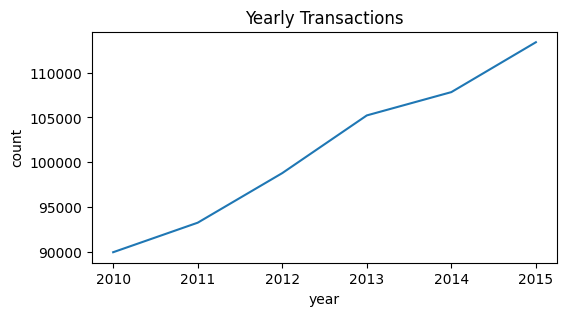

In [72]:
yearly = df["tx_year"].value_counts()

plt.figure(figsize=(6,3))
yearly.plot()
plt.title("Yearly Transactions")
plt.xlabel("year")
plt.ylabel("count")
plt.show()

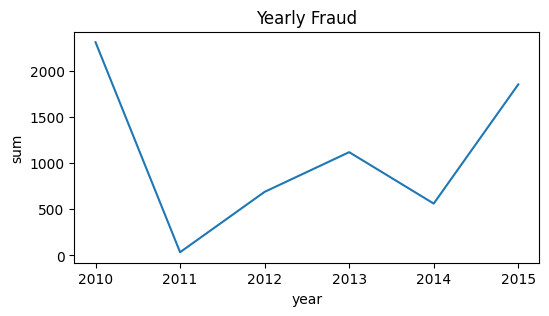

tx_year
2010    2310
2011      35
2012     689
2013    1119
2014     562
2015    1853
Name: fraud, dtype: int64

tx_year
2010    0.025683
2011    0.000375
2012    0.006975
2013    0.010634
2014    0.005212
2015    0.016340
Name: fraud, dtype: float64


In [73]:
yearly_fraud = (
    df
    .groupby("tx_year")[LABEL]
    .sum()
)
plt.figure(figsize=(6,3))
yearly_fraud.plot()
plt.title("Yearly Fraud")
plt.xlabel("year")
plt.ylabel("sum")
plt.show()
print(yearly_fraud)
print()
yearly_fraud = (
    df
    .groupby("tx_year")[LABEL]
    .mean()
)
print(yearly_fraud)

**tx_month**

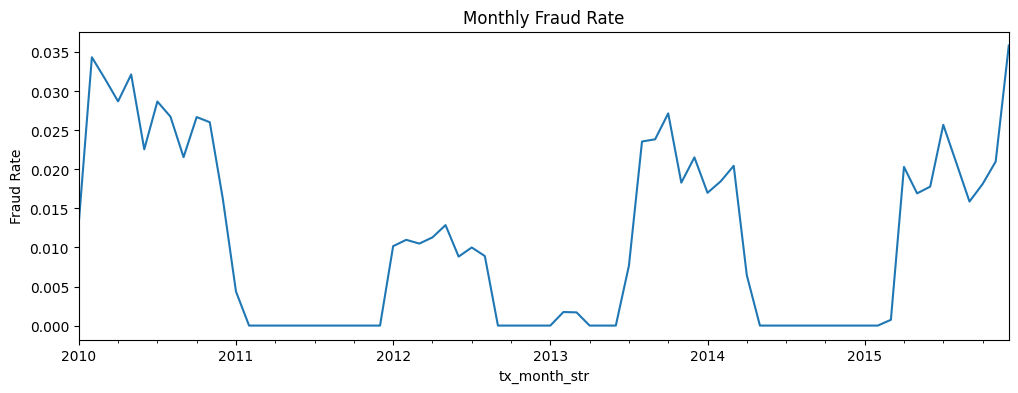

In [74]:
monthly_fraud = (
    df
    .assign(tx_month_str=df["date"].dt.to_period("M"))
    .groupby("tx_month_str")[LABEL]
    .mean()
)

plt.figure(figsize=(12,4))
monthly_fraud.plot()
plt.title("Monthly Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

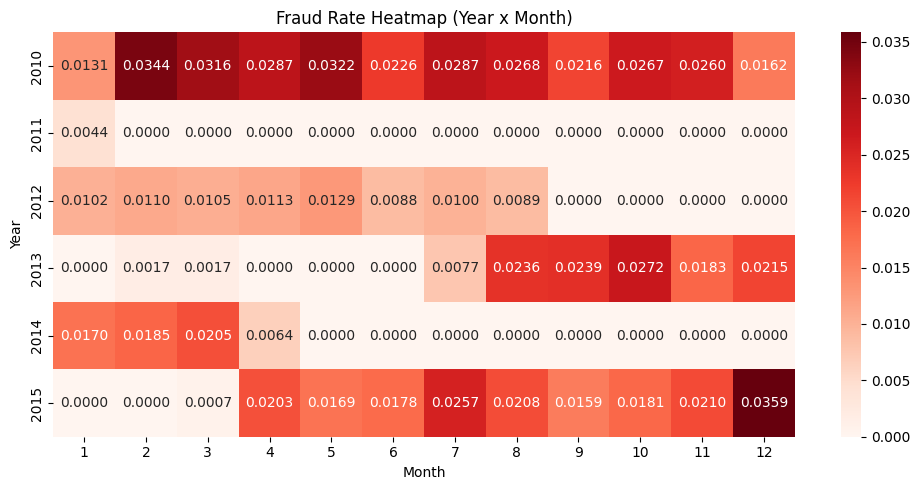

In [75]:
pivot_df = (
    df.groupby(["tx_year", "tx_month"])[LABEL]
    .mean()
    .unstack()
)
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".4f",
    cmap="Reds"
)
plt.title("Fraud Rate Heatmap (Year x Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

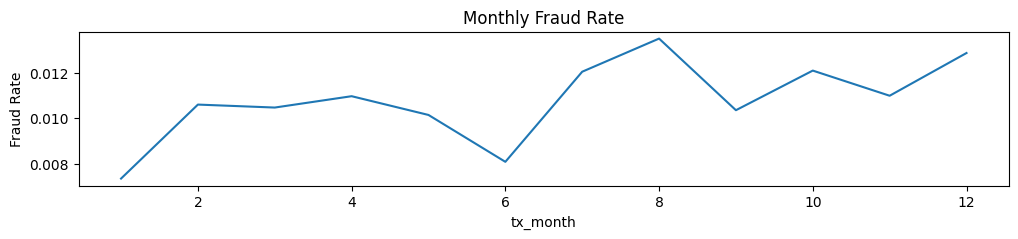

tx_month
1     0.007347
2     0.010595
3     0.010464
4     0.010962
5     0.010139
6     0.008082
7     0.012037
8     0.013491
9     0.010348
10    0.012087
11    0.010982
12    0.012858
Name: fraud, dtype: float64


In [76]:
monthly_fraud = (
    df
    .groupby("tx_month")[LABEL]
    .mean()
)

plt.figure(figsize=(12,2))
monthly_fraud.plot()
plt.title("Monthly Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()
print(monthly_fraud)

**tx_day**

tx_day
1     0.010634
2     0.010200
3     0.009280
4     0.010273
5     0.012225
6     0.011711
7     0.011009
8     0.010206
9     0.010411
10    0.009284
11    0.008733
12    0.011902
13    0.009208
14    0.009689
15    0.010825
16    0.009872
17    0.008423
18    0.013231
19    0.013180
20    0.010193
21    0.010574
22    0.010907
23    0.012124
24    0.008841
25    0.010645
26    0.011746
27    0.012606
28    0.011903
29    0.013095
30    0.010184
31    0.012369
Name: fraud, dtype: float64


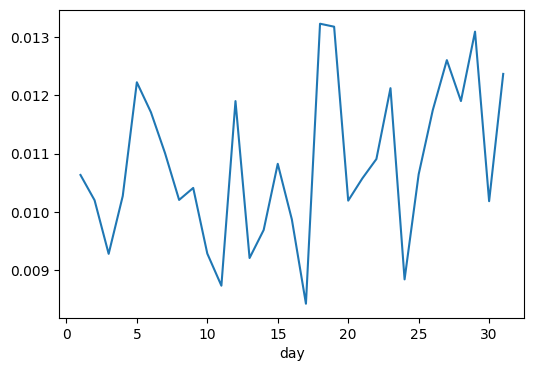

In [77]:
day = (
    df
    .groupby("tx_day")[LABEL]
    .mean()
)

plt.figure(figsize=(6, 4))
day.plot()
plt.xlabel("day")
plt.ylabel("")

print(day)

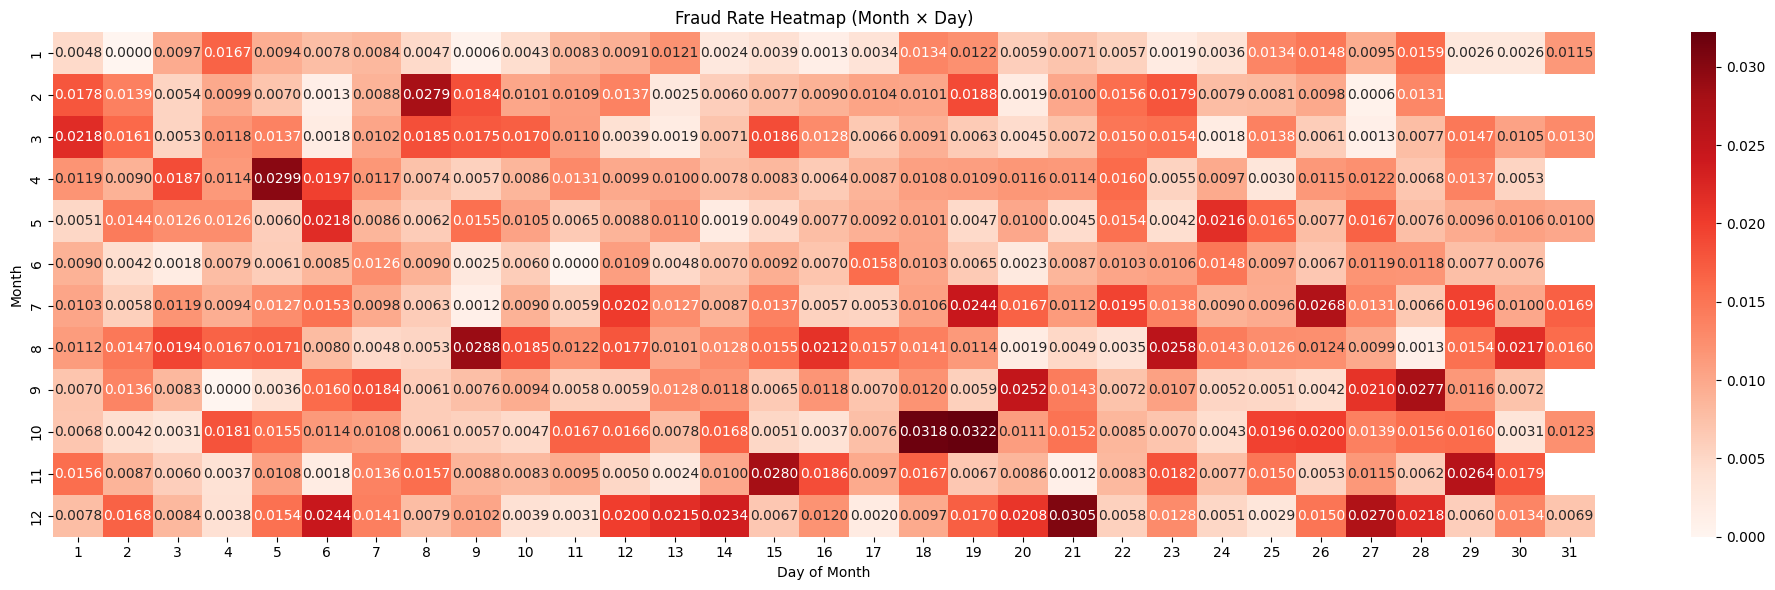

In [78]:
pivot_day = (
    df
    .groupby(["tx_month", "tx_day"])[LABEL]
    .mean()
    .unstack()  # day를 열로
)

plt.figure(figsize=(20,6))
sns.heatmap(
    pivot_day,
    cmap="Reds",
    annot=True,
    fmt=".4f"
)

plt.xlabel("Day of Month")
plt.ylabel("Month")
plt.title("Fraud Rate Heatmap (Month × Day)")
plt.tight_layout()
plt.show()

In [292]:
# month 더미
X = pd.get_dummies(df["tx_month"].astype("int16"), prefix="m", drop_first=True)

# statsmodels용: 전부 float로 (object 제거)
X = sm.add_constant(X).astype("float64")

y = df["fraud"].astype("int8")

model = sm.Logit(y, X).fit(disp=0)
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                  fraud   No. Observations:               608430
Model:                          Logit   Df Residuals:                   608418
Method:                           MLE   Df Model:                           11
Date:                Fri, 20 Feb 2026   Pseudo R-squ.:                0.002396
Time:                        14:49:47   Log-Likelihood:                -36190.
converged:                       True   LL-Null:                       -36277.
Covariance Type:            nonrobust   LLR p-value:                 1.898e-31
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.9061      0.052    -95.035      0.000      -5.007      -4.805
m_2            0.3694      0.069      5.377      0.000       0.235       0.504
m_3            0.3569      0.067      5.288      0.0

**tx_hour**

tx_hour
0     0.001067
1     0.004360
2     0.004988
3     0.019449
4     0.013244
5     0.019768
6     0.012154
7     0.011155
8     0.013148
9     0.017965
10    0.019061
11    0.018269
12    0.018029
13    0.015214
14    0.010227
15    0.009567
16    0.006353
17    0.005318
18    0.003194
19    0.003147
20    0.000786
21    0.001046
22    0.000741
23    0.001941
Name: fraud, dtype: float64


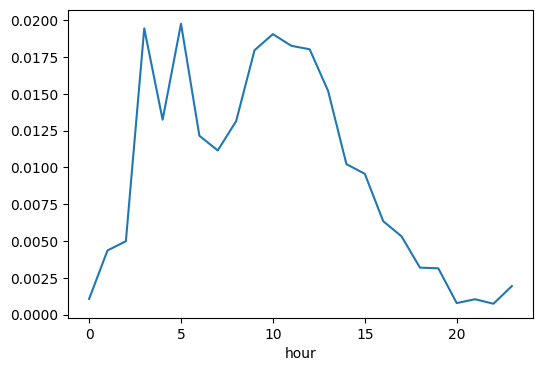

In [79]:
hour = (
    df
    .groupby("tx_hour")[LABEL]
    .mean()
)

plt.figure(figsize=(6, 4))
hour.plot()
plt.xlabel("hour")
plt.ylabel("")

print(hour)

In [83]:
df["weekday_name"] = df["date"].dt.day_name().str[:3]

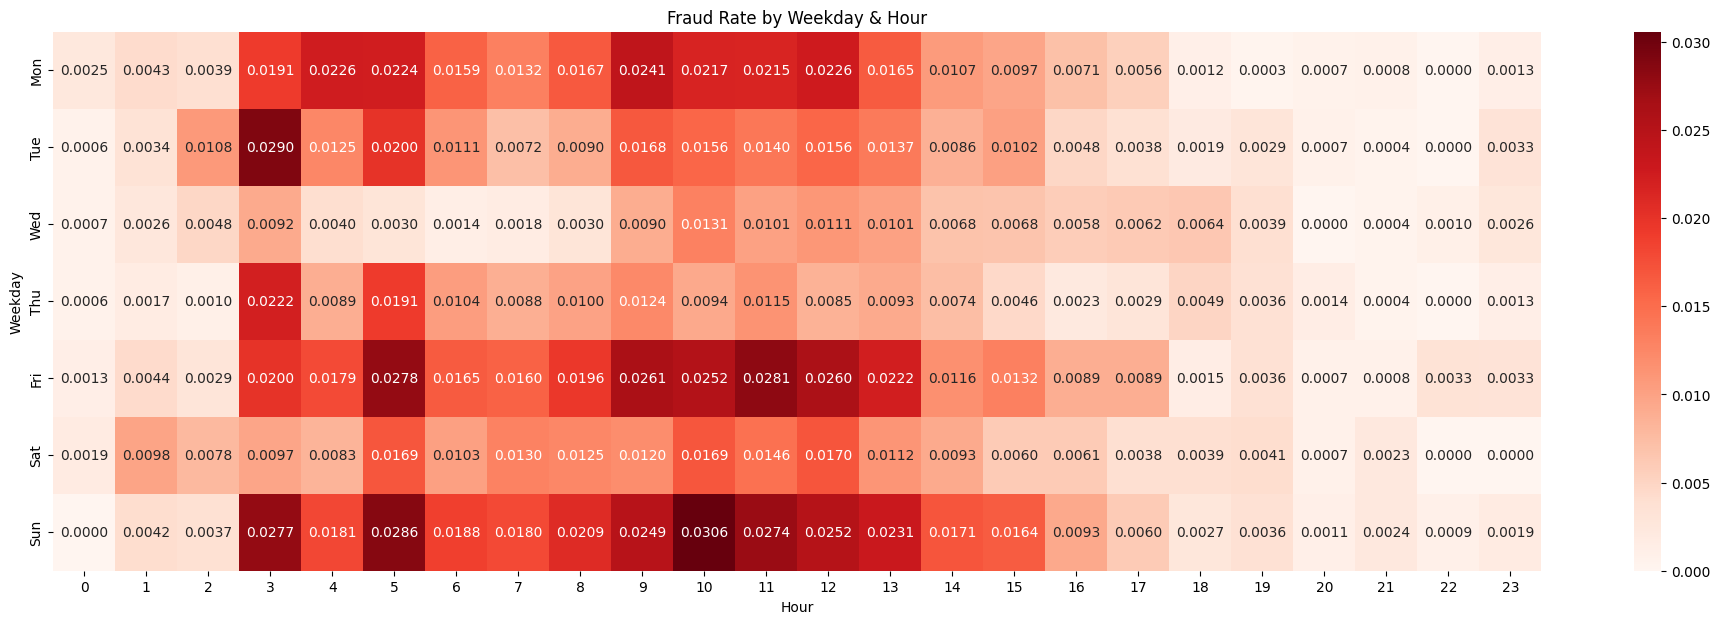

In [84]:
pivot_weekday_hour = (
    df.groupby(["weekday_name", "tx_hour"])["fraud"]
      .mean()
      .unstack()  
      .reindex(index=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)

plt.figure(figsize=(24,7))
sns.heatmap(
    pivot_weekday_hour,
    cmap="Reds",
    annot=True,
    fmt=".4f"
)
plt.title("Fraud Rate by Weekday & Hour")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

In [85]:
df.drop("weekday_name", axis=1, inplace=True)

**weekday**

weekday
6    0.016239
4    0.015035
0    0.012547
5    0.009294
1    0.009273
3    0.006994
2    0.006005
Name: fraud, dtype: float64


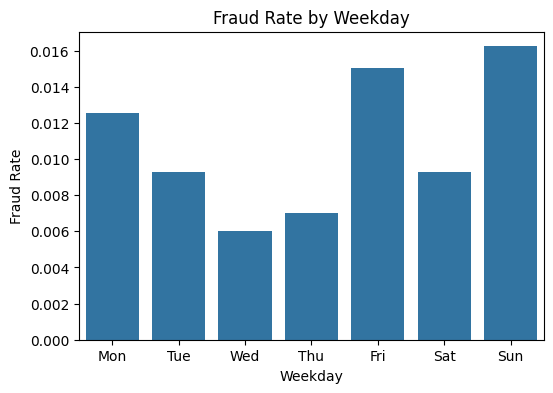

In [86]:
weekday_rate = (
    df.groupby("weekday")["fraud"]
      .mean()
      .sort_values(ascending=False)
)

print(weekday_rate)

weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed",
    3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}

weekday_df = weekday_rate.reset_index()
weekday_df.columns = ["weekday", "fraud_rate"]

weekday_df["weekday_name"] = weekday_df["weekday"].map(weekday_map)

weekday_df = weekday_df.sort_values("weekday")

plt.figure(figsize=(6,4))
sns.barplot(data=weekday_df, x="weekday_name", y="fraud_rate")
plt.xlabel("Weekday")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Weekday")
plt.show()

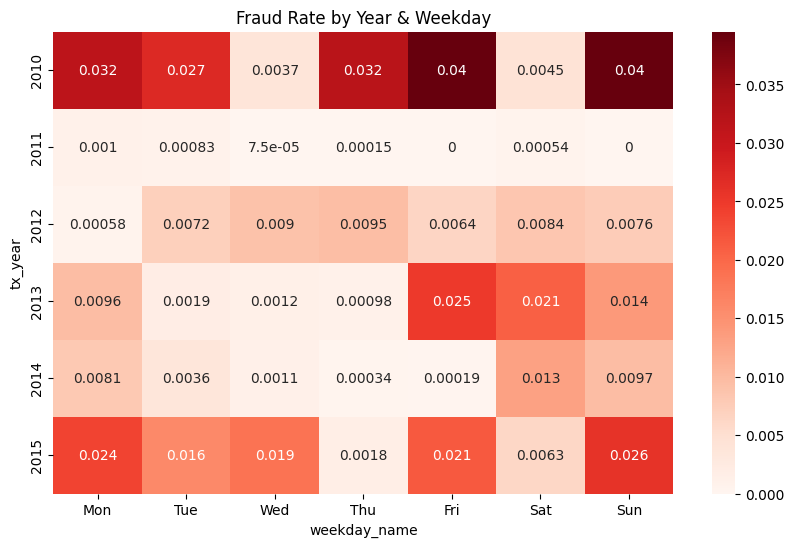

In [87]:
df["weekday_name"] = df["date"].dt.day_name().str[:3]
pivot_weekday = (
    df.groupby(["tx_year", "weekday_name"])["fraud"]
      .mean()
      .unstack()
      .reindex(columns=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)
plt.figure(figsize=(10,6))
sns.heatmap(pivot_weekday, cmap="Reds", annot=True)
plt.title("Fraud Rate by Year & Weekday")
plt.show()

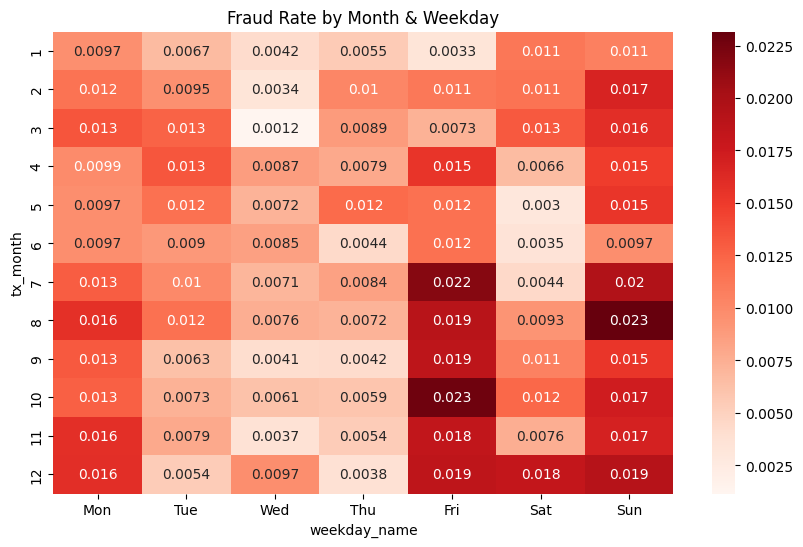

In [88]:
pivot_weekday = (
    df.groupby(["tx_month", "weekday_name"])["fraud"]
      .mean()
      .unstack()
      .reindex(columns=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)
plt.figure(figsize=(10,6))
sns.heatmap(pivot_weekday, cmap="Reds", annot=True)
plt.title("Fraud Rate by Month & Weekday")
plt.show()


### **3.2 Cyclical Encoding**

**hour_sin**

In [89]:
df["hour_sin"] = np.sin(2 * np.pi * df["tx_hour"] / 24).astype("float32")

**hour_cos**

In [90]:
df["hour_cos"] = np.cos(2 * np.pi * df["tx_hour"] / 24).astype("float32")

### **3.3 Statistical Validation (Quantitative Validation Layer)**

**단변량 Signal 확인**

In [91]:
results = []

for col in ["tx_year",
            "tx_month",
            "tx_day",
            "tx_hour",
            "weekday",
            "hour_sin",
            "hour_cos"]:

    X = sm.add_constant(df[[col]].dropna())
    y = df.loc[X.index, "fraud"]

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params[col]
    pval = model.pvalues[col]
    or_val = np.exp(coef)

    results.append([col, coef, or_val, pval])

pd.DataFrame(results, columns=["feature","coef","OR","p_value"])

,feature,coef,OR,p_value
0,tx_year,-0.055146,0.946347,3.415689e-14
1,tx_month,0.028936,1.029358,1.220676e-15
2,tx_day,0.004505,1.004516,1.392776e-03
3,tx_hour,-0.056707,0.944871,3.820954e-131
4,weekday,0.067188,1.069496,3.570199e-27
5,hour_sin,0.509089,1.663774,1.785236e-179
6,hour_cos,-0.828663,0.436633,4.156424e-215


**다변량 Incrementality**

In [92]:
TIME_CANDIDATES = [
    "tx_year",
    "tx_month",
    "tx_day",
    "tx_hour",
    "weekday",
    "hour_sin",
    "hour_cos",
]

# 1) 유틸: 모델 학습 + 점수
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score

def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

# 2) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 3) 시간 피처 add-one 다변량 검증
rows = []

for tcol in TIME_CANDIDATES:
    feats = BASELINE + [tcol]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    # 추가된 피처의 coef/OR/p-value만 뽑기
    coef = model.params.get(tcol, np.nan)
    pval = model.pvalues.get(tcol, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    # baseline 대비 lift 개선량
    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_time_feature": tcol,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": delta_rate,
        "delta_lift_vs_baseline": delta_lift,
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values("delta_lift_vs_baseline", ascending=False)
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663464, 'top_n': 60843}


,added_time_feature,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,hour_cos,-0.874981,0.416870,4.254266e-244,0.010795,0.045823,4.244823,0.003599,0.333435,60843
1,hour_sin,0.531479,1.701447,7.304009e-187,0.010795,0.045330,4.199147,0.003106,0.287759,60843
2,tx_hour,-0.056596,0.944976,3.206836e-132,0.010795,0.043653,4.043849,0.001430,0.132460,60843
3,weekday,0.067492,1.069822,7.538463e-27,0.010795,0.043127,3.995128,0.000904,0.083739,60843
4,tx_month,0.028726,1.029143,4.249762e-15,0.010795,0.042618,3.947929,0.000394,0.036541,60843
5,tx_year,-0.049918,0.951307,1.069509e-11,0.010795,0.042536,3.940317,0.000312,0.028928,60843
6,tx_day,0.004495,1.004506,1.626665e-03,0.010795,0.042371,3.925091,0.000148,0.013703,60843


# 📦 Block: Time Structure

---

## ✅ 유지 (핵심 시간 구조)

| Feature  | 판단        | 근거                                     |
| -------- | --------- | -------------------------------------- |
| hour_cos | **강력 유지** | 가장 큰 lift 개선, 시간대 분포 구조를 가장 잘 설명       |
| hour_sin | **강력 유지** | hour_cos와 함께 원형 시간 구조 완성, ranking 개선 큼 |

> 시간은 **원형 변수(circular)**로 다루는 것이 가장 적절
> sin/cos 조합이 tx_hour 단일 변수보다 구조적으로 우수

---

## 🔎 조건부 유지

| Feature  | 판단     | 근거                        |
| -------- | ------ | ------------------------- |
| tx_hour  | 조건부 유지 | sin/cos 포함 시 정보 중복 가능성 있음 |
| weekday  | 유지 가능  | 요일 효과 존재하나 영향은 중간 수준      |
| tx_month | 약한 유지  | 계절성은 있으나 영향 제한적           |
| tx_year  | 약한 유지  | 장기 추세 보정용 변수로는 의미 있음      |
| tx_day   | 제거 후보  | 효과 미미, 구조적 설명력 낮음         |

---

## ❌ 제거 후보

| Feature                | 판단    | 근거              |
| ---------------------- | ----- | --------------- |
| tx_day                 | 제거    | 독립적 설명력 거의 없음   |
| tx_hour (sin/cos 포함 시) | 제거 가능 | 원형 변환 변수에 정보 흡수 |

---

# 🔎 Time 블록 구조 요약

### 📌 핵심 시간 표현

* hour_sin
* hour_cos

### 📌 보조 시간 변수

* weekday
* tx_month
* tx_year (drift 보정 목적이면 유지 가능)

### 📌 제거 우선 후보

* tx_day
* tx_hour (sin/cos 사용 시)

---

이 블록은 interaction 후보라기보다는
**표현 방식 선택 문제 (representation choice)**에 가까움.

---


### **3.4 Time Deviation History**

- client_weekday_prev

- client_weekday_match_last1

- client_weekday_prior_count

- client_weekday_is_new

- sin_shift

- cos_shift

- sin_cumsum

- cos_cumsum

- cnt_past

- client_sin_mean_past

- client_cos_mean_past

- hour_circular_distance


In [93]:
df = df.sort_values(["client_id", "date"])

df["client_weekday_prev"] = (
    df.groupby("client_id")["weekday"]
      .shift(1)
)

df["client_weekday_match_last1"] = (
    df["weekday"] == df["client_weekday_prev"]
).astype("int8")


In [94]:
df["client_weekday_prev"] = df.groupby("client_id")["weekday"].shift(1)

df["client_weekday_prev"] = df["client_weekday_prev"].fillna(df["weekday"]).astype(df["weekday"].dtype)

df["client_weekday_match_last1"] = (df["weekday"] == df["client_weekday_prev"]).astype("int8")


In [95]:
df["client_weekday_prior_count"] = (
    df.groupby(["client_id", "weekday"])
      .cumcount()
)

df["client_weekday_is_new"] = (
    df["client_weekday_prior_count"] == 0
).astype("int8")

In [96]:
pd.crosstab(
    df["client_weekday_is_new"],
    df["fraud"],
    normalize="index"
)

fraud,0,1
client_weekday_is_new,,
0,0.989348,0.010652
1,0.979038,0.020962


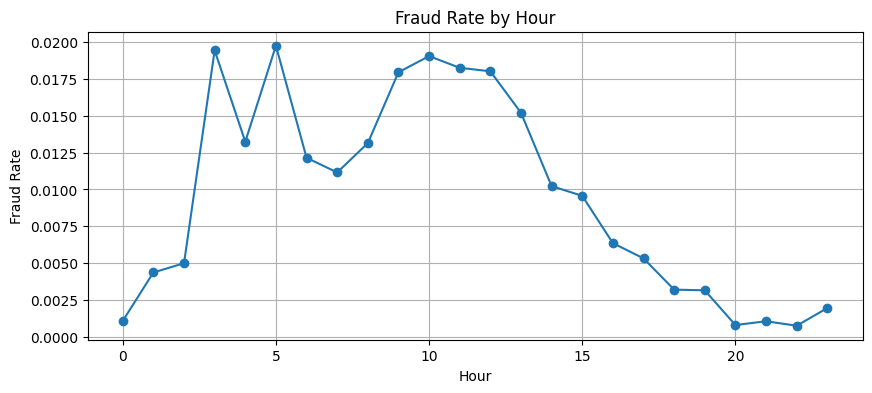

In [97]:
hour_rate = (
    df.groupby("tx_hour")["fraud"]
      .mean()
)

plt.figure(figsize=(10,4))
hour_rate.plot(marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.grid(True)
plt.show()


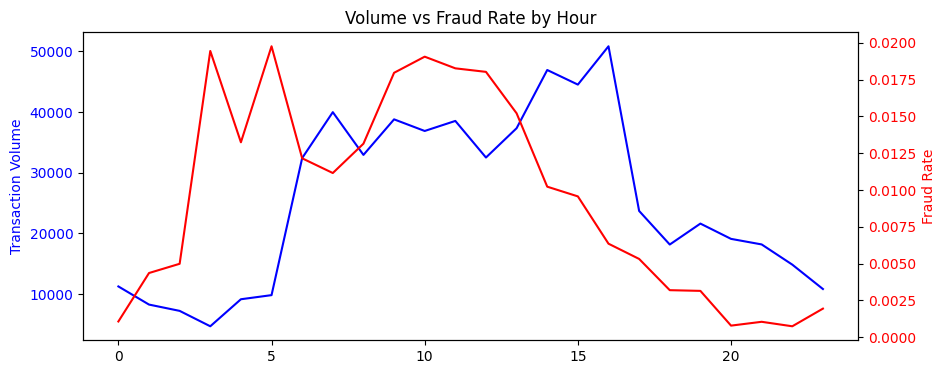

In [98]:
hour_full = (
    df.groupby("tx_hour")["fraud"]
      .agg(["mean", "count"])
)

fig, ax1 = plt.subplots(figsize=(10,4))

# 거래량 - 파랑
ax1.plot(hour_full.index, hour_full["count"], color="blue", label="Transaction Volume")
ax1.set_ylabel("Transaction Volume", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# fraud rate - 빨강
ax2 = ax1.twinx()
ax2.plot(hour_full.index, hour_full["mean"], color="red", label="Fraud Rate")
ax2.set_ylabel("Fraud Rate", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Volume vs Fraud Rate by Hour")
plt.show()


In [99]:
# 1-1) shift (과거값)
df["sin_shift"] = (
    df.groupby("client_id")["hour_sin"]
      .shift(1)
      .fillna(df["hour_sin"])
)

df["cos_shift"] = (
    df.groupby("client_id")["hour_cos"]
      .shift(1)
      .fillna(df["hour_cos"])
)
# 1-2) 누적합
df["sin_cumsum"] = df["sin_shift"].fillna(0).groupby(df["client_id"]).cumsum()
df["cos_cumsum"] = df["cos_shift"].fillna(0).groupby(df["client_id"]).cumsum()

# 1-3) 과거 개수 (첫 거래는 0)
df["cnt_past"] = df.groupby("client_id").cumcount()

# 1-4) 과거 평균 (0으로 나누기 방지)
df["client_sin_mean_past"] = np.where(
    df["cnt_past"] > 0,
    df["sin_cumsum"] / df["cnt_past"],
    np.nan
)
df["client_cos_mean_past"] = np.where(
    df["cnt_past"] > 0,
    df["cos_cumsum"] / df["cnt_past"],
    np.nan
)

# 1-5) 첫 거래 결측 채우기:
df["client_sin_mean_past"] = df["client_sin_mean_past"].fillna(df["hour_sin"])
df["client_cos_mean_past"] = df["client_cos_mean_past"].fillna(df["hour_cos"])

# 1-6) 원형 거리
df["hour_circular_distance"] = np.sqrt(
    (df["hour_sin"] - df["client_sin_mean_past"])**2 +
    (df["hour_cos"] - df["client_cos_mean_past"])**2
)


### **3.5 Statistical Validation**

In [100]:
time_behavior_features = [
    "client_weekday_prev",
    "client_weekday_match_last1",
    "client_weekday_prior_count",
    "client_weekday_is_new",
    "sin_shift",
    "cos_shift",
    "sin_cumsum",
    "cos_cumsum",
    "cnt_past",
    "client_sin_mean_past",
    "client_cos_mean_past",
    "hour_circular_distance"
]

In [101]:
rows_uni = []

for col in time_behavior_features:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,cnt_past,-0.001478,0.998523,0.000000e+00,0.034088,3.157753,61224
1,client_weekday_prior_count,-0.009977,0.990073,0.000000e+00,0.029616,2.743527,66990
2,client_weekday_match_last1,1.333375,3.793824,0.000000e+00,0.022404,2.075361,177740
3,hour_circular_distance,1.170350,3.223122,0.000000e+00,0.021646,2.005177,60843
4,client_weekday_prev,0.071780,1.074419,9.768882e-31,0.015661,1.450756,87479
5,cos_shift,-0.542209,0.581462,5.756346e-114,0.015588,1.443997,108353
6,sin_shift,0.432754,1.541497,1.097098e-132,0.012660,1.172730,82230
7,client_cos_mean_past,0.446719,1.563175,9.398556e-36,0.010880,1.007917,60843
8,client_weekday_is_new,0.687429,1.988597,4.346538e-19,0.010795,1.000000,608430
9,client_sin_mean_past,0.227996,1.256081,2.781473e-13,0.007495,0.694275,60843


In [102]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in time_behavior_features:
    if col in BASELINE:
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,client_weekday_match_last1,OK,1.393025,4.027013,0.000000e+00,0.010795,0.050852,4.710719,0.008629,0.799330,60843
1,cos_shift,OK,-0.576966,0.561600,7.835954e-129,0.010795,0.044771,4.147381,0.002548,0.235993,60843
2,sin_shift,OK,0.444373,1.559512,1.867696e-134,0.010795,0.044311,4.104750,0.002087,0.193362,60843
3,client_weekday_prev,OK,0.072575,1.075274,9.859522e-31,0.010795,0.043423,4.022533,0.001200,0.111145,60843
4,cnt_past,OK,-0.001228,0.998773,6.522595e-301,0.010795,0.042848,3.969245,0.000625,0.057856,60843
5,client_sin_mean_past,OK,0.245126,1.277782,1.309627e-13,0.010795,0.042700,3.955542,0.000477,0.044153,60843
6,client_cos_mean_past,OK,0.351621,1.421370,2.991521e-21,0.010795,0.042684,3.954019,0.000460,0.042631,60843
7,client_weekday_prior_count,OK,-0.008269,0.991765,1.049898e-294,0.010795,0.042240,3.912911,0.000016,0.001523,60843
8,client_weekday_is_new,OK,0.454731,1.575749,8.478766e-09,0.010795,0.042174,3.906821,-0.000049,-0.004568,60843
9,sin_cumsum,OK,0.000102,1.000102,1.839785e-03,0.010795,0.042141,3.903776,-0.000082,-0.007613,60843


# 📦 Block: Client Temporal Pattern / Habit Deviation

---

## ✅ 강력 유지 (핵심 패턴 이탈 신호)

| Feature                    | 판단        | 근거                                   |
| -------------------------- | --------- | ------------------------------------ |
| client_weekday_match_last1 | **강력 유지** | lift 개선 가장 큼, 최근 요일 일치 여부가 강한 리스크 신호 |
| cos_shift                  | **유지**    | 과거 시간 패턴 대비 이탈 신호, ranking 개선 명확     |
| sin_shift                  | **유지**    | cos_shift와 함께 시간 이탈 구조 설명            |
| client_weekday_prev        | 유지        | 직전 요일 맥락 반영, 안정적 개선                  |

---

## 🔎 유지 가능 (보조 패턴 변수)

| Feature                    | 판단     | 근거                    |
| -------------------------- | ------ | --------------------- |
| cnt_past                   | 유지 가능  | 거래 누적량에 따른 안정성 신호     |
| client_cos_mean_past       | 유지 가능  | 고객 평균 시간 패턴 정보        |
| client_sin_mean_past       | 유지 가능  | 위와 동일 구조              |
| client_weekday_prior_count | 조건부 유지 | 반복 패턴 반영하나 추가 개선은 제한적 |

---

## 🔎 Interaction 후보 (패턴 × 시간 / error 결합 가능성 높음)

| Feature                    | 판단             | 근거                                      |
| -------------------------- | -------------- | --------------------------------------- |
| client_weekday_match_last1 | Interaction 유력 | 시간 이탈, error, refund와 결합 시 증폭 가능성       |
| cos_shift / sin_shift      | Interaction 유력 | error / refund / 신규 merchant와 구조적 결합 가능 |
| client_weekday_is_new      | Interaction 후보 | 신규 요일 패턴은 단독보다는 결합형 가능성 높음              |

---

## ❌ 제거 후보

| Feature                | 판단    | 근거                       |
| ---------------------- | ----- | ------------------------ |
| cos_cumsum             | 제거    | lift 감소, 구조적 설명력 낮음      |
| sin_cumsum             | 제거    | 효과 미미                    |
| hour_circular_distance | 제거 후보 | sin/cos shift에 정보 흡수 가능성 |

---

# 🔎 Temporal Pattern 블록 구조 요약

### 📌 핵심 축

* client_weekday_match_last1
* cos_shift
* sin_shift

### 📌 패턴 안정성 축

* cnt_past
* client_cos_mean_past
* client_sin_mean_past

### 📌 제거 우선

* cos_cumsum
* sin_cumsum
* hour_circular_distance

---

이 블록은 **“습관 대비 이탈(deviation from habit)” 구조가 핵심**임.
특히 `match_last1`과 `shift` 계열은 interaction 탐색 시 중요한 축이 될 가능성 매우 높음.

---


---
# 4. Static Profile Block (Customer Context)

> 거래를 해석하기 위한 고객의 구조적 배경

## 4.1 Demographics

- current_age

- male

## 4.2 Income & Financial Status

- per_capita_income

- yearly_income

- log_yearly_income

- income_ratio_region

- log_income_ratio_region

- total_debt

- credit_score

## 4.3 Card Holdings

- num_credit_cards

- num_cards_issued

- credit_limit

## 4.4 Account Age & Lifecycle

- months_from_account

- year_pin_last_changed

- years_since_pin_change

- years_to_retirement

## 4.5 Expiry Information

- expires_year

- expires_month

- months_to_expire

### **4.1 Demographics**

**current_age**

In [103]:
df["current_age"].describe()

count    608430.000000
mean         54.572924
std          15.481459
min          23.000000
25%          44.000000
50%          52.000000
75%          63.000000
max         101.000000
Name: current_age, dtype: float64

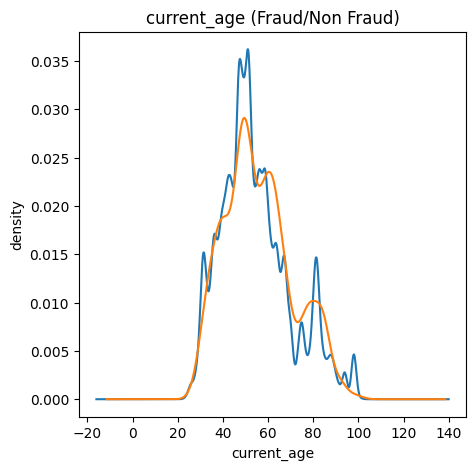

In [104]:
plt.figure(figsize=(5,5))
df[df["fraud"]==0]["current_age"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"]==1]["current_age"].plot(kind="kde", label="Fraud")
plt.xlabel("current_age")
plt.title("current_age (Fraud/Non Fraud)")
plt.ylabel("density")
plt.show()

**male**

In [105]:
df.groupby("fraud")["male"].mean()

fraud
0    0.473675
1    0.484166
Name: male, dtype: float64

### **4.2 Income & Financial Status**

**per_capita_income**

In [106]:
col = "per_capita_income"

# 기본 통계
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

# fraud 그룹별 평균/중앙값
grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)

=== Basic Stats ===
count    608430.000000
mean      24982.570312
std       12965.945312
min           0.000000
1%        11512.000000
5%        13759.000000
25%       17845.000000
50%       22247.000000
75%       28147.000000
95%       45812.000000
99%       74205.000000
max      163145.000000
Name: per_capita_income, dtype: float64

=== Group Stats (by fraud) ===
        count          mean   median          std
fraud                                            
0      601862  25004.992188  22247.0  12987.15625
1        6568  22928.000000  20570.0  10649.94043


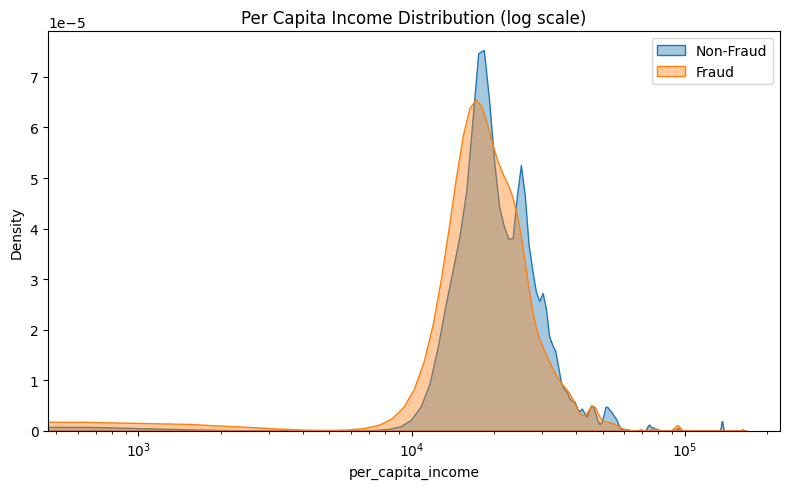

In [107]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x=col,
    label="Non-Fraud",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df[LABEL]==1],
    x=col,
    label="Fraud",
    fill=True,
    alpha=0.4
)

plt.xscale("log") 
plt.title("Per Capita Income Distribution (log scale)")
plt.legend()
plt.tight_layout()
plt.show()


**yearly_income**


In [108]:
df["yearly_income"].describe()

count    608430.000000
mean      48209.937500
std       26794.488281
min           1.000000
25%       34302.000000
50%       41902.000000
75%       56350.000000
max      280199.000000
Name: yearly_income, dtype: float64

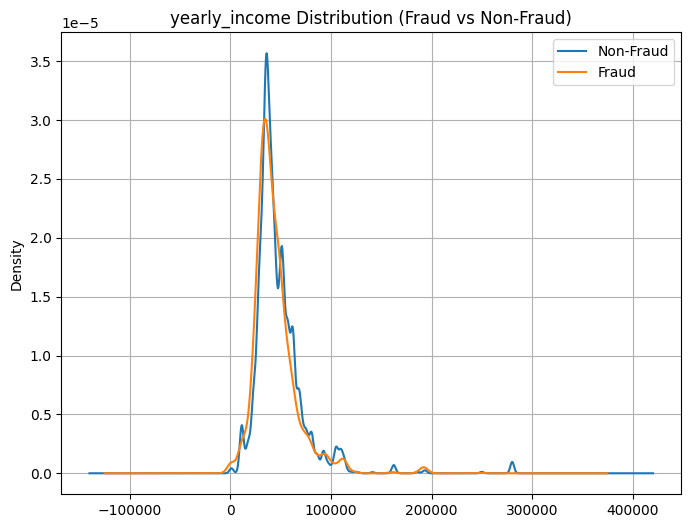

In [109]:
plt.figure(figsize=(8,6))
df[df["fraud"]==0]["yearly_income"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"]==1]["yearly_income"].plot(kind="kde", label="Fraud")
plt.title("yearly_income Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

In [110]:
low_vals = [1,0, 2.0, 4.0, 399.0, 553.0, 645.0, 920.0, 1426.0]

(df[df["yearly_income"].isin(low_vals)]
 .groupby("yearly_income")["fraud"]
 .agg(["count","mean"])
 .sort_index())

,count,mean
yearly_income,,
1.0,65,0.000000
2.0,3,0.000000
4.0,1,1.000000
399.0,224,0.120536
553.0,110,0.036364
645.0,124,0.024194
920.0,255,0.023529
1426.0,254,0.000000


> 비현실적인 연소득이 존재해서 flag 필요

In [111]:
df["low_income_flag"] = (df["yearly_income"] < 1000).astype("int8")

**log_yearly_income**


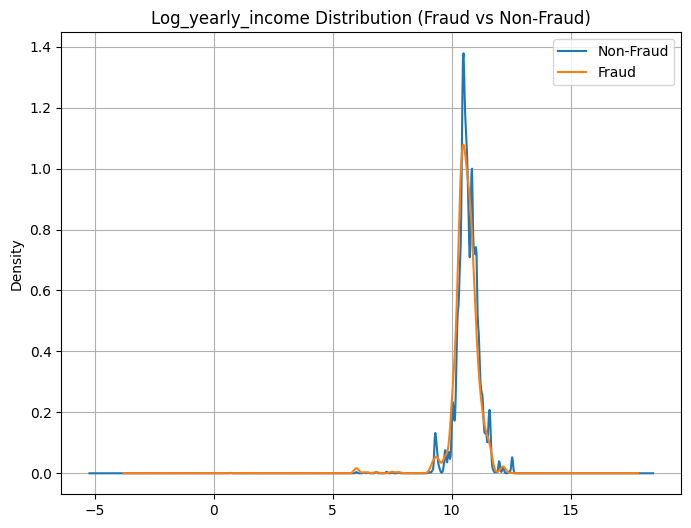

In [112]:
plt.figure(figsize=(8,6))
df[df["fraud"]==0]["log_yearly_income"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"]==1]["log_yearly_income"].plot(kind="kde", label="Fraud")
plt.title("Log_yearly_income Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2216042/2217625789.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("log_income_bin")["fraud"].mean()


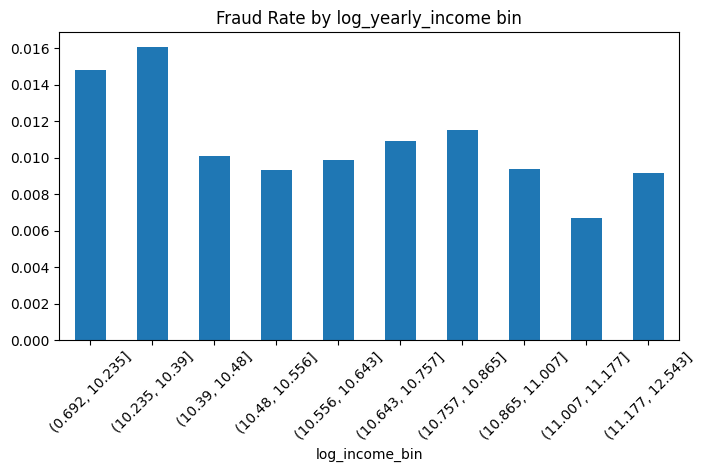

In [113]:
df["log_income_bin"] = pd.qcut(df["log_yearly_income"], 10, duplicates="drop")

bin_rate = df.groupby("log_income_bin")["fraud"].mean()

plt.figure(figsize=(8,4))
bin_rate.plot(kind="bar")
plt.title("Fraud Rate by log_yearly_income bin")
plt.xticks(rotation=45)
plt.show()


**income_ratio_region**

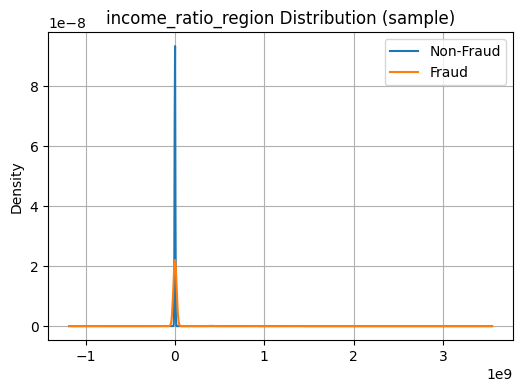

In [114]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["income_ratio_region"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["income_ratio_region"].plot(kind="kde", label="Fraud")

plt.title("income_ratio_region Distribution (sample)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2216042/2401710794.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("income_region_bin")["fraud"].mean()


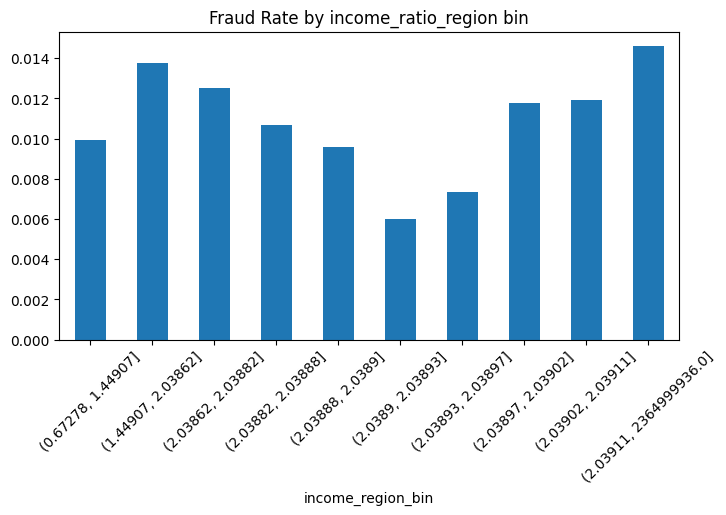

In [115]:
df["income_region_bin"] = pd.qcut(df["income_ratio_region"], 10, duplicates="drop")

bin_rate = df.groupby("income_region_bin")["fraud"].mean()

plt.figure(figsize=(8,4))
bin_rate.plot(kind="bar")
plt.title("Fraud Rate by income_ratio_region bin")
plt.xticks(rotation=45)
plt.show()

In [116]:
df.groupby("fraud")["income_ratio_region"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,601862.0,2310740.0,58491840.0,0.672793,2.038778,2.038904,2.038995,2.365000e+09
1,6568.0,7447322.0,103636504.0,0.672793,2.038728,2.038898,2.039018,2.365000e+09


**log_income_ratio_region**


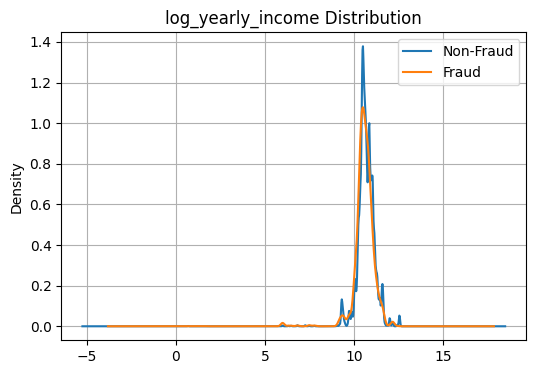

In [117]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["log_yearly_income"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["log_yearly_income"].plot(kind="kde", label="Fraud")

plt.title("log_yearly_income Distribution")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2216042/2237376754.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("log_income_region_bin")["fraud"].mean()


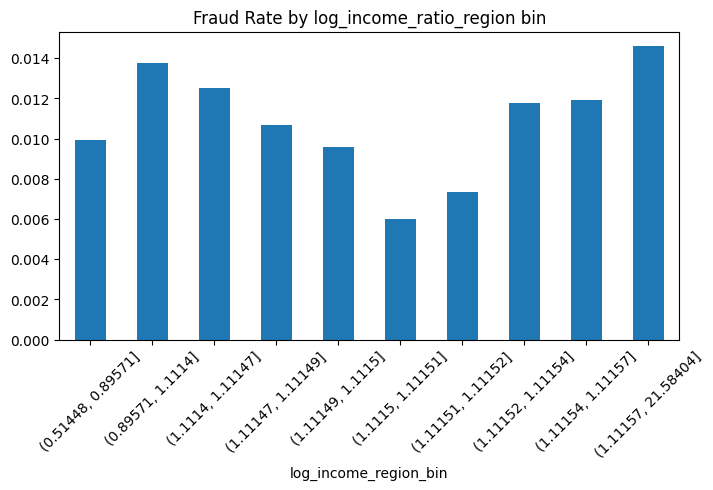

In [118]:
df["log_income_region_bin"] = pd.qcut(df["log_income_ratio_region"], 10, duplicates="drop")

bin_rate = df.groupby("log_income_region_bin")["fraud"].mean()

plt.figure(figsize=(8,4))
bin_rate.plot(kind="bar")
plt.title("Fraud Rate by log_income_ratio_region bin")
plt.xticks(rotation=45)
plt.show()

In [119]:
df.groupby("fraud")["log_income_ratio_region"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,601862.0,1.106302,0.899798,0.514495,1.111455,1.111497,1.111527,21.584044
1,6568.0,1.226522,1.757264,0.514495,1.111439,1.111495,1.111534,21.584044


**total_debt**

In [120]:
df["total_debt"].describe()

count    608430.000000
mean      58777.468750
std       49365.179688
min           0.000000
25%       18006.000000
50%       52248.000000
75%       89743.000000
max      461854.000000
Name: total_debt, dtype: float64

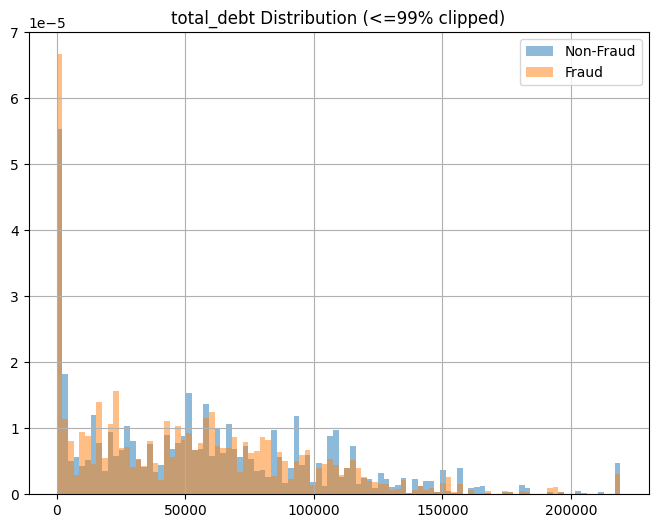

In [121]:
non = df[df["fraud"]==0].copy()
fraud = df[df["fraud"]==1].copy()

col = "total_debt"

non = df.loc[df["fraud"] == 0, col].dropna()
fraud = df.loc[df["fraud"] == 1, col].dropna()

xmax = df[col].quantile(0.99)
non = non.clip(upper=xmax)
fraud = fraud.clip(upper=xmax)

plt.figure(figsize=(8,6))
plt.hist(non, bins=100, alpha=0.5, label="Non-Fraud", density=True)
plt.hist(fraud, bins=100, alpha=0.5, label="Fraud", density=True)
plt.legend()
plt.title(f"{col} Distribution (<=99% clipped)")
plt.grid(True)
plt.show()


**credit_score**

In [122]:
df["credit_score"].describe()

count    608430.000000
mean        709.295457
std          71.234803
min         488.000000
25%         679.000000
50%         710.000000
75%         755.000000
max         850.000000
Name: credit_score, dtype: float64

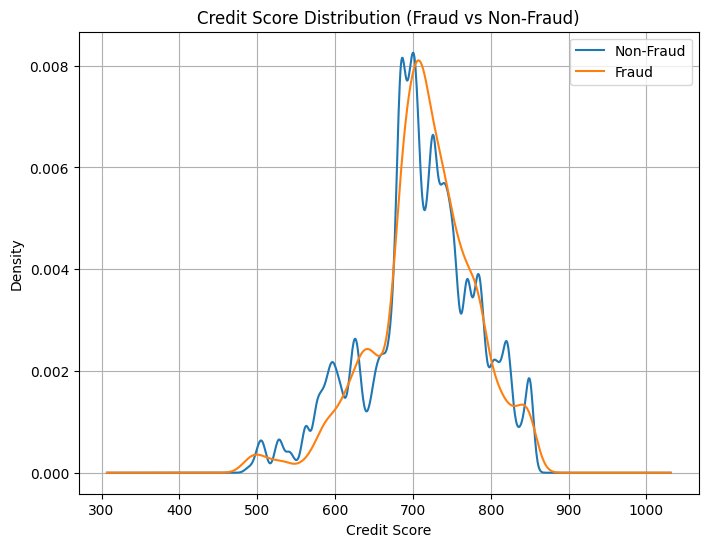

In [123]:
plt.figure(figsize=(8,6))

df[df["fraud"]==0]["credit_score"].plot(
    kind="kde", label="Non-Fraud"
)
df[df["fraud"]==1]["credit_score"].plot(
    kind="kde", label="Fraud"
)

plt.title("Credit Score Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


## 4.3 Card Holdings

- num_credit_cards

- num_cards_issued

- credit_limit

**num_credit_cards**

In [124]:
p = (
    df.groupby(["fraud", "num_credit_cards"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack(fill_value=0)
)

p

,num_credit_cards,1,2,3,4,5,6,7,8,9
fraud,fraud,,,,,,,,,
0,0,0.088216,0.132198,0.224128,0.231498,0.172757,0.082755,0.052417,0.015183,0.000847
1,1,0.039586,0.117996,0.205542,0.259135,0.190469,0.107491,0.046285,0.028471,0.005024


In [125]:
df.groupby("num_credit_cards")["fraud"].agg(
    ["count", "mean"]
)

,count,mean
num_credit_cards,,
1,53354,0.004873
2,80340,0.009647
3,136244,0.009909
4,141032,0.012068
5,105227,0.011889
6,50513,0.013977
7,31852,0.009544
8,9325,0.020054
9,543,0.060773


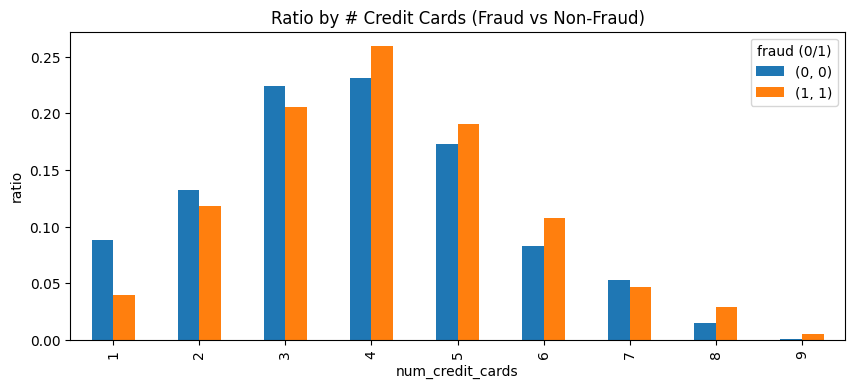

In [126]:
p = p.T
ax = p.sort_index().plot(kind="bar", figsize=(10,4))
ax.set_xlabel("num_credit_cards")
ax.set_ylabel("ratio")
ax.set_title("Ratio by # Credit Cards (Fraud vs Non-Fraud)")
ax.legend(title="fraud (0/1)")

**num_cards_issued**

In [127]:
p = (
    df.groupby(["fraud", "num_cards_issued"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack(fill_value=0)
)

p

,num_cards_issued,1,2,3
fraud,fraud,,,
0,0,0.493254,0.502185,0.004561
1,1,0.490256,0.499543,0.010201


**credit_limit**

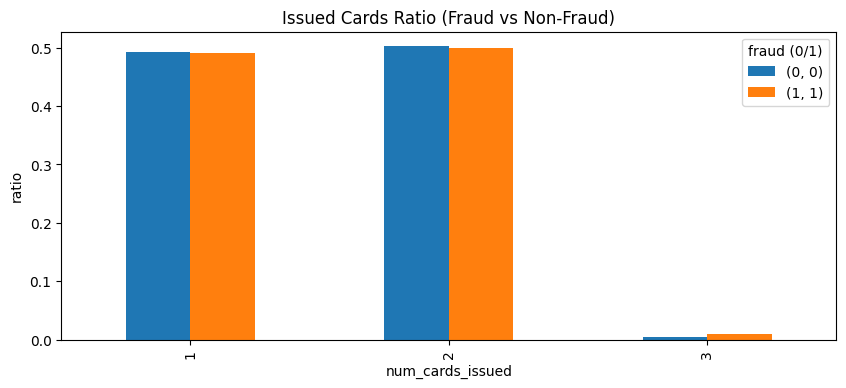

In [128]:
p = p.T
ax = p.sort_index().plot(kind="bar", figsize=(10,4))
ax.set_xlabel("num_cards_issued")
ax.set_ylabel("ratio")
ax.set_title("Issued Cards Ratio (Fraud vs Non-Fraud)")
ax.legend(title="fraud (0/1)")

**credit_limit**

In [129]:
df["credit_limit"].describe()

count    608430.000000
mean      16190.116211
std       12274.958984
min           1.000000
25%        8500.000000
50%       14448.000000
75%       21820.000000
max      141391.000000
Name: credit_limit, dtype: float64

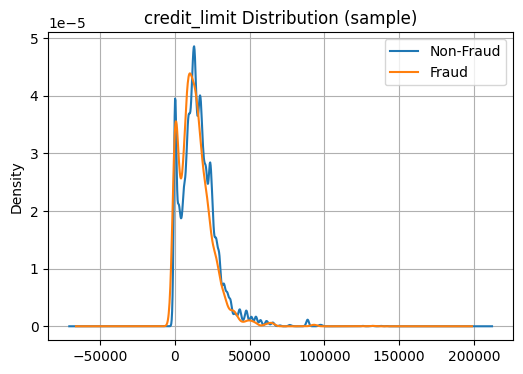

In [130]:
sample_df = df.copy()
plt.figure(figsize=(6,4))

sample_df[sample_df["fraud"] == 0]["credit_limit"].plot(kind="kde", label="Non-Fraud")
sample_df[sample_df["fraud"] == 1]["credit_limit"].plot(kind="kde", label="Fraud")

plt.title("credit_limit Distribution (sample)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_2216042/3149035856.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("limit_bin")["fraud"].mean().plot(kind="bar", figsize=(8,4))


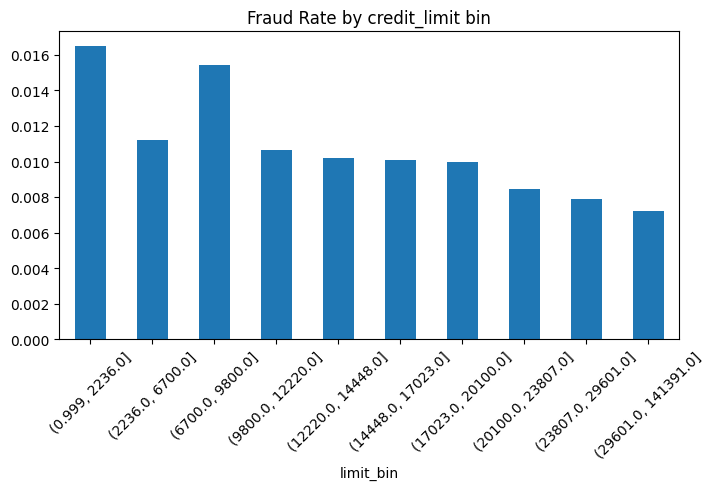

In [131]:
df["limit_bin"] = pd.qcut(df["credit_limit"], 10, duplicates="drop")
df.groupby("limit_bin")["fraud"].mean().plot(kind="bar", figsize=(8,4))
plt.title("Fraud Rate by credit_limit bin")
plt.xticks(rotation=45)
plt.show()

### **4.4 Account Age & Lifecycle**

- months_from_account

- year_pin_last_changed

- years_since_pin_change

- years_to_retirement


**months_from_account**

In [132]:
df["months_from_account"].describe()

count    608430.000000
mean         70.985906
std          47.242727
min           0.000000
25%          34.000000
50%          63.000000
75%         100.000000
max         299.000000
Name: months_from_account, dtype: float64

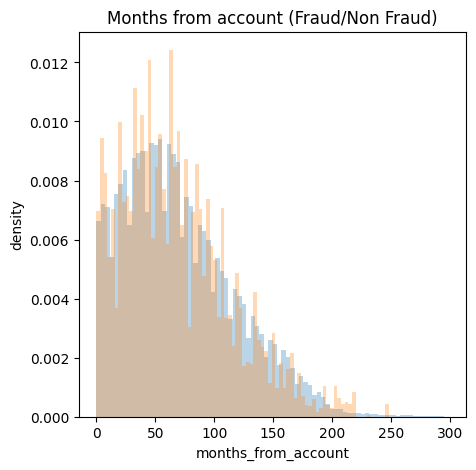

In [133]:
non = df[df["fraud"]==0]
fraud = df[df["fraud"]==1]

plt.figure(figsize=(5,5))
plt.hist(non["months_from_account"], bins=80, density=True, alpha=0.3, label="Non-Fraud")
plt.hist(fraud["months_from_account"], bins=80, density=True, alpha=0.3, label="Fraud")
plt.xlabel("months_from_account")
plt.title("Months from account (Fraud/Non Fraud)")
plt.ylabel("density")
plt.show()

**year_pin_last_changed**

In [134]:
df["year_pin_last_changed"].describe()

count       608430.0
mean     2011.065179
std         2.688831
min           2002.0
25%           2009.0
50%           2011.0
75%           2012.0
max           2020.0
Name: year_pin_last_changed, dtype: Float64

**years_since_pin_change**

In [135]:
df["years_since_pin_change"] = df["tx_year"] - df["year_pin_last_changed"]
col = "years_since_pin_change"

print("Using column:", col)

Using column: years_since_pin_change


In [136]:
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)


=== Basic Stats ===
count    608430.0
mean      1.57248
std      3.101071
min         -10.0
1%           -7.0
5%           -4.0
25%           0.0
50%           2.0
75%           4.0
95%           6.0
99%           8.0
max          13.0
Name: years_since_pin_change, dtype: Float64

=== Group Stats (by fraud) ===
        count      mean  median       std
fraud                                    
0      601862  1.572806     2.0  3.098512
1        6568  1.542631     2.0   3.32733


음수 -> PIN 변경 연도가 거래 연도보다 미래에 있음


In [137]:
df["years_since_pin_change"] = df["years_since_pin_change"].clip(lower=0)

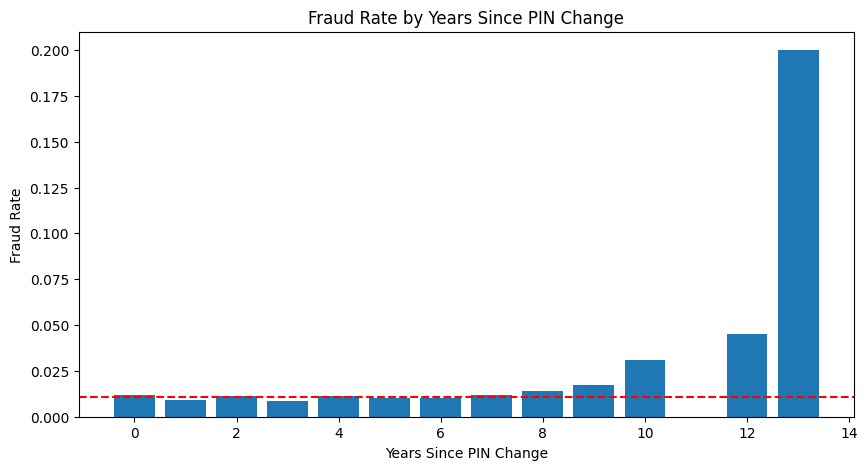

In [138]:
tmp = df[["years_since_pin_change", "fraud"]].dropna().copy()

rate_table = (
    tmp.groupby("years_since_pin_change")["fraud"]
       .agg(["count", "mean"])
       .reset_index()
)

base_rate = tmp["fraud"].mean()
rate_table["lift"] = rate_table["mean"] / base_rate

plt.figure(figsize=(10,5))
plt.bar(rate_table["years_since_pin_change"], rate_table["mean"])
plt.axhline(base_rate, color="red", linestyle="--")
plt.title("Fraud Rate by Years Since PIN Change")
plt.xlabel("Years Since PIN Change")
plt.ylabel("Fraud Rate")
plt.show()


In [139]:
rate_table = (
    df.groupby("years_since_pin_change")["fraud"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

rate_table["lift"] = rate_table["mean"] / df["fraud"].mean()

print(rate_table.sort_values("years_since_pin_change"))


    years_since_pin_change   count   sum      mean       lift
0                        0  197802  2298  0.011618   1.076210
1                        1   89664   813  0.009067   0.839943
2                        2   84129   960  0.011411   1.057068
3                        3   77230   667  0.008637   0.800050
4                        4   65204   741  0.011364   1.052741
5                        5   42841   449  0.010481   0.970877
6                        6   25268   263  0.010408   0.964189
7                        7   14115   171  0.012115   1.122258
8                        8    6976    98  0.014048   1.301359
9                        9    3161    55  0.017400   1.611817
10                      10    1064    33  0.031015   2.873094
11                      11     586     0  0.000000   0.000000
12                      12     375    17  0.045333   4.199476
13                      13      15     3  0.200000  18.527101


선형 변수로 쓰면 안 됨
binning해서 써야 함

In [140]:
df["pin_age_group"] = pd.cut(
    df["years_since_pin_change"],
    bins=[-100, 2, 7, 10, 20],
    labels=["0-2", "3-7", "8-10", "10+"]
)

In [141]:
df.drop("years_since_pin_change", axis=1, inplace=True)

In [142]:
group_table = (
    df.groupby("pin_age_group")[LABEL]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

base_rate = df[LABEL].mean()
group_table["lift"] = group_table["mean"] / base_rate

print(group_table)

  pin_age_group   count   sum      mean      lift
0           0-2  371595  4071  0.010955  1.014866
1           3-7  224658  2291  0.010198  0.944671
2          8-10   11201   186  0.016606  1.538274
3           10+     976    20  0.020492  1.898269


/tmp/ipykernel_2216042/774970047.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pin_age_group")[LABEL]


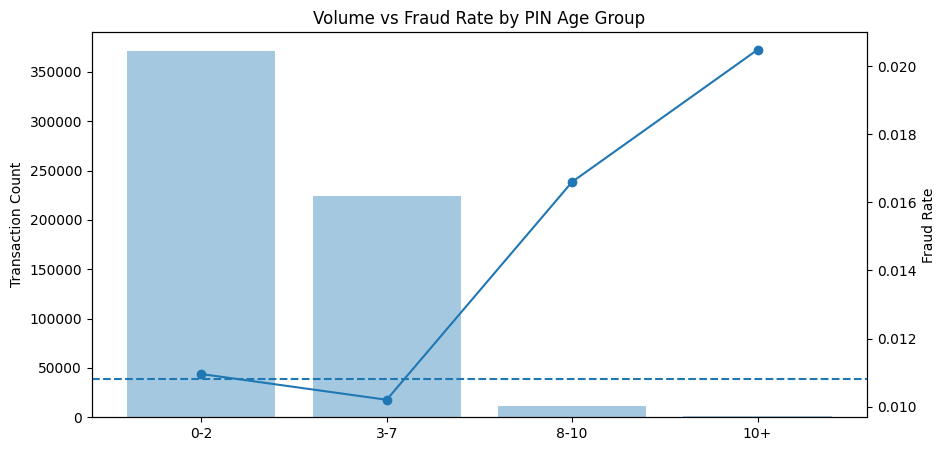

In [143]:
fig, ax1 = plt.subplots(figsize=(10,5))

# 거래 수
ax1.bar(group_table["pin_age_group"], group_table["count"], alpha=0.4)
ax1.set_ylabel("Transaction Count")

# fraud rate
ax2 = ax1.twinx()
ax2.plot(group_table["pin_age_group"], group_table["mean"], marker="o")
ax2.axhline(base_rate, linestyle="--")
ax2.set_ylabel("Fraud Rate")

plt.title("Volume vs Fraud Rate by PIN Age Group")
plt.show()


In [144]:
df.drop("pin_age_group", axis=1, inplace=True)

**years_to_retirement**

In [145]:
col = "years_to_retirement"

# 기본 통계
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

# 결측률
print("\nMissing rate:", df[col].isna().mean())

# fraud 그룹별 통계
grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)


=== Basic Stats ===
count    608430.000000
mean         14.561422
std          11.725148
min           0.000000
1%            0.000000
5%            0.000000
25%           2.000000
50%          14.000000
75%          23.000000
95%          35.000000
99%          41.000000
max          48.000000
Name: years_to_retirement, dtype: float64

Missing rate: 0.0

=== Group Stats (by fraud) ===
        count       mean  median        std
fraud                                      
0      601862  14.574982    14.0  11.725732
1        6568  13.318819    12.0  11.605269


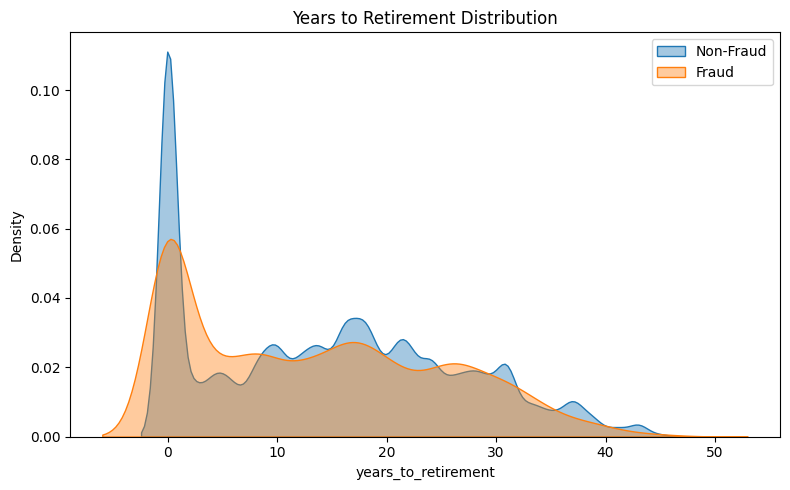

In [146]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x=col,
    label="Non-Fraud",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df[LABEL]==1],
    x=col,
    label="Fraud",
    fill=True,
    alpha=0.4
)

plt.title("Years to Retirement Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 4.5 Expiry Information

- expires_year

- expires_month

- months_to_expire

In [147]:
df.drop(columns=["expiers_year", "expiers_month"], inplace=True)

KeyError: "['expiers_year', 'expiers_month'] not found in axis"

In [ ]:
col = "months_to_expire"
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

na_rate = df[col].isna().mean()
print(f"\nMissing rate: {na_rate:.4%}")

grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)

=== Basic Stats ===
count    5.312525e+06
mean     1.031152e+02
std      3.575659e+01
min      0.000000e+00
1%       6.000000e+00
5%       3.100000e+01
25%      8.200000e+01
50%      1.070000e+02
75%      1.280000e+02
95%      1.560000e+02
99%      1.690000e+02
max      1.790000e+02
Name: months_to_expire, dtype: float64

Missing rate: 0.0000%

=== Group Stats (by fraud) ===
         count        mean  median        std
fraud                                        
0      5304837  103.117252   107.0  35.752140
1         7688  101.680151   105.0  38.678244


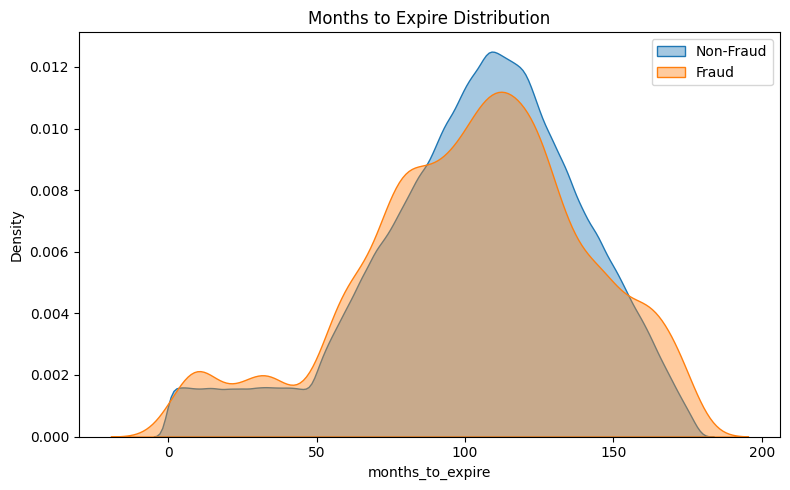

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x=col,
    label="Non-Fraud",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df[LABEL]==1],
    x=col,
    label="Fraud",
    fill=True,
    alpha=0.4
)

plt.title("Months to Expire Distribution")
plt.legend()
plt.tight_layout()
plt.show()


   expire_decile   count      mean      lift
0              0  543024  0.001689  1.166912
1              1  548976  0.001574  1.087547
2              2  515517  0.001693  1.170197
3              3  536702  0.001241  0.857489
4              4  563886  0.001344  0.928893
5              5  527583  0.001374  0.949587
6              6  501951  0.001221  0.843892
7              7  522017  0.001293  0.893525
8              8  541206  0.001242  0.858014
9              9  511663  0.001808  1.249238


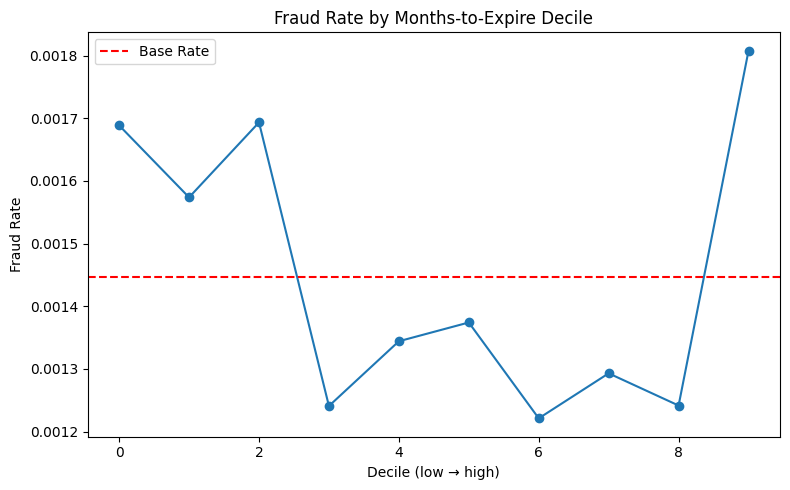

In [ ]:
tmp = df[[col, LABEL]].dropna().copy()

tmp["expire_decile"] = pd.qcut(tmp[col], 10, labels=False, duplicates="drop")

rate_table = (
    tmp.groupby("expire_decile")[LABEL]
       .agg(["count", "mean"])
       .reset_index()
)

base_rate = tmp[LABEL].mean()
rate_table["lift"] = rate_table["mean"] / base_rate

print(rate_table)

plt.figure(figsize=(8,5))
plt.plot(rate_table["expire_decile"], rate_table["mean"], marker="o")
plt.axhline(base_rate, color="red", linestyle="--", label="Base Rate")
plt.title("Fraud Rate by Months-to-Expire Decile")
plt.xlabel("Decile (low → high)")
plt.ylabel("Fraud Rate")
plt.legend()
plt.tight_layout()
plt.show()


### **4.6 Statistical Validation (Quantitative Validation Layer)**

In [330]:
DEMOGRAPHICS = [
    "current_age",
    "male"
]

FINANCIAL = [
    "per_capita_income",
    "yearly_income",
    "log_yearly_income",
    "income_ratio_region",
    "log_income_ratio_region",
    "total_debt",
    "credit_score"
]

CARD_HOLDINGS = [
    "num_credit_cards",
    "num_cards_issued",
    "credit_limit"
]

LIFECYCLE = [
    "months_from_account",
    "years_to_retirement"
]

EXPIRY = [
    "expires_year",
    "expires_month",
    "months_to_expire"
]

ALL_STATIC = (
    DEMOGRAPHICS
    + FINANCIAL
    + CARD_HOLDINGS
    + LIFECYCLE
    + EXPIRY
)

In [331]:
results = []

for col in ALL_STATIC:

    X = sm.add_constant(df[[col]].dropna())
    y = df.loc[X.index, "fraud"]

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params[col]
    pval = model.pvalues[col]
    or_val = np.exp(coef)

    results.append([col, coef, or_val, pval])

uni_df = pd.DataFrame(
    results,
    columns=["feature","coef","OR","p_value"]
).sort_values("p_value")

display(uni_df)


,feature,coef,OR,p_value
11,credit_limit,-2.185297e-05,0.999978,5.736238e-71
4,log_yearly_income,-3.109209e-01,0.732772,1.462813e-63
9,num_credit_cards,1.122768e-01,1.118822,5.264328e-53
2,per_capita_income,-1.830681e-05,0.999982,5.258446e-40
3,yearly_income,-7.539885e-06,0.999992,8.251002e-34
6,log_income_ratio_region,7.033351e-02,1.072866,6.806725e-23
7,total_debt,-2.530816e-06,0.999997,7.648928e-21
13,years_to_retirement,-9.319082e-03,0.990724,6.329746e-18
0,current_age,5.249348e-03,1.005263,1.740944e-11
5,income_ratio_region,7.279878e-10,1.000000,5.399906e-11


# 📦 Block: Demographic / Financial Profile

---

## ✅ 유지 (구조적으로 의미 있음)

| Feature                 | 판단    | 근거                         |
| ----------------------- | ----- | -------------------------- |
| log_yearly_income       | 유지    | 일관된 보호 효과, 소득 수준은 기본 리스크 축 |
| credit_limit            | 유지    | 신용 한도는 안정성 지표로 의미 있음       |
| num_credit_cards        | 유지    | 카드 수 증가는 리스크 행동성과 연결 가능    |
| log_income_ratio_region | 유지    | 지역 대비 소득 편차는 구조적 리스크 신호    |
| credit_score            | 유지 가능 | 개별 효과는 작지만 금융 안정성 핵심 변수    |
| current_age             | 유지 가능 | 연령은 행동 패턴 차이 반영            |

---

## 🔎 조건부 유지 (보조적 안정성 변수)

| Feature             | 판단       | 근거                         |
| ------------------- | -------- | -------------------------- |
| years_to_retirement | 보조 유지    | 연령과 중복 가능성 존재              |
| months_from_account | 보조 유지    | 계정 성숙도 반영                  |
| total_debt          | 조건부 유지   | income/limit 변수와 상관 가능성 높음 |
| per_capita_income   | 중복 점검 필요 | yearly_income 계열과 중복 가능성   |
| yearly_income       | 제거 후보    | log_yearly_income와 중복      |
| income_ratio_region | 제거 후보    | log 변환 변수에 흡수 가능           |

---

## ❌ 제거

| Feature          | 판단 | 근거     |
| ---------------- | -- | ------ |
| male             | 제거 | 유의성 약함 |
| num_cards_issued | 제거 | 설명력 낮음 |
| expires_month    | 제거 | 효과 없음  |
| months_to_expire | 제거 | 효과 없음  |

---

## 🔎 Interaction 후보 (Profile × Behavior 결합 가능성)

| Feature           | 판단             | 근거                                             |
| ----------------- | -------------- | ---------------------------------------------- |
| log_yearly_income | Interaction 유력 | 고액 거래 / refund / income_ratio_risk_zone와 결합 가능 |
| credit_limit      | Interaction 유력 | amount 계열과 구조적 결합 가능                           |
| num_credit_cards  | Interaction 후보 | velocity / merchant_change와 결합 가능              |
| credit_score      | Interaction 후보 | error/velocity와 결합 가능                          |

---

# 🔎 Profile 블록 구조 요약

### 📌 안정성 축 (Protection axis)

* log_yearly_income
* credit_limit
* credit_score

### 📌 행동 확장 축

* num_credit_cards

### 📌 제거 우선

* male
* expires_month
* months_to_expire
* num_cards_issued

---

이 블록은 대부분 **“기저 위험도 조정 변수 (baseline calibration layer)”** 역할임.
단독으로 폭발적인 lift를 만드는 변수는 아니지만
interaction과 결합 시 구조적으로 의미가 커질 가능성이 있음.

---



---
# 5. Card & Channel Block

> 카드 유형/결제 수단 특성 기반 리스크

## 5.1 Card Type

- is_credit

- is_prepaid

(파생: card_type category)

## 5.2 Chip Capability

- has_chip

## 5.3 Card Brand One-hot

- cb_Visa

- cb_Mastercard

- cb_Amex

- cb_Discover

---

### **5.1 Card Type**

**is_credit**

In [149]:
df.groupby("is_credit")["fraud"].mean()

is_credit
0    0.010557
1    0.011337
Name: fraud, dtype: float64

**is_prepaid**

In [150]:
df.groupby("is_prepaid")["fraud"].mean()

is_prepaid
0    0.010276
1    0.017110
Name: fraud, dtype: float64

In [151]:
df["card_type"] = np.select(
    [
        df["is_credit"] == 1,
        df["is_prepaid"] == 1
    ],
    [
        "credit",
        "debit(prepaid)"
    ],
    default="debit(non_prepaid)"
)

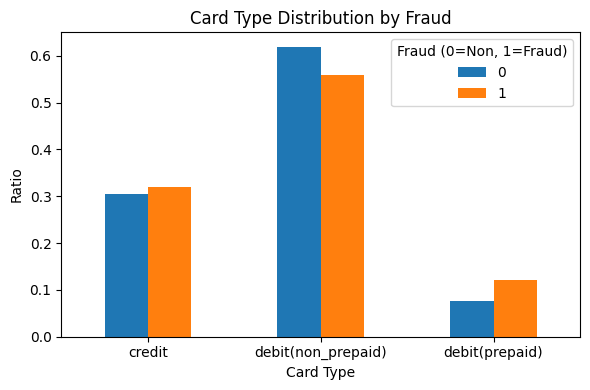

In [152]:
df["card_type"] = df["card_type"].astype("category")

card_ratio = (
    df.groupby("fraud")["card_type"]
      .value_counts(normalize=True)
      .unstack()
)

card_ratio.T.plot(kind="bar", figsize=(6,4))
plt.ylabel("Ratio")
plt.xlabel("Card Type")
plt.title("Card Type Distribution by Fraud")
plt.xticks(rotation=0)
plt.legend(title="Fraud (0=Non, 1=Fraud)")
plt.tight_layout()
plt.show()

In [153]:
fraud_rate = (
    df.groupby("card_type")["fraud"]
      .mean()
      .sort_values(ascending=False)
)
fraud_rate

/tmp/ipykernel_2216042/1246485000.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("card_type")["fraud"]


card_type
debit(prepaid)        0.017110
credit                0.011337
debit(non_prepaid)    0.009753
Name: fraud, dtype: float64

*왜 prepaid가 더 높을까*

In [154]:
df["is_prepaid"] = (df["card_type"] == "debit(prepaid)").astype("int8")

Text(0, 0.5, '')

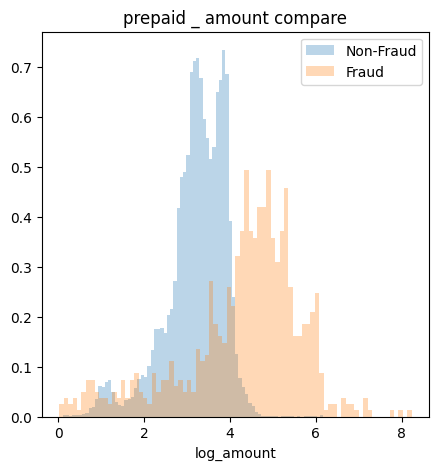

In [155]:
prepaid = df[df["card_type"]=="debit(prepaid)"].copy()

plt.figure(figsize=(5,5))
plt.hist(prepaid[prepaid["fraud"]==0]["log_abs_amount"], bins=80, density=True, alpha=0.3, label="Non-Fraud")
plt.hist(prepaid[prepaid["fraud"]==1]["log_abs_amount"], bins=80, density=True, alpha=0.3, label="Fraud")
plt.xlabel("log_amount")
plt.title("prepaid _ amount compare")
plt.legend()
plt.ylabel("")

In [156]:
df["prepaid_logamount_interaction"] = (
    (df["card_type"] == "debit(prepaid)").astype(int)
    * df["log_abs_amount"]
)

### **5.2 Chip Capability**

**has_chip**

In [157]:
df["has_chip"].value_counts()

has_chip
1    556094
0     52336
Name: count, dtype: int64

In [158]:
df.groupby("has_chip")["fraud"].mean()

has_chip
0    0.008503
1    0.011011
Name: fraud, dtype: float64

### **5.3 Card Brand One-hot**

- `cb_Visa`
- `cb_Mastercard`
- `cb_Amex`
- `cb_Discover`

In [159]:
df["card_brand"] = np.select([
    df["cb_Visa"] == 1,
    df["cb_Mastercard"] == 1,
    df["cb_Amex"] == 1,
],
[
    "visa",
    "mastercard",
    "amex",
],
    default="discover"
)

In [160]:
p = (
    df.groupby(["card_brand", "fraud"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack()
)
p

,fraud,0,1
card_brand,card_brand,,
amex,amex,0.988428,0.011572
discover,discover,0.982315,0.017685
mastercard,mastercard,0.989141,0.010859
visa,visa,0.989903,0.010097


In [161]:
df["discover_x_cvv"] = df["cb_Discover"] * df["err_bad_cvv"]

### **5.4 Statistical Validation (Quantitative Validation Layer)**

In [162]:
CARD_CANDIDATES = [
    # 5.1 Card Type
    "is_credit",
    "is_prepaid",

    # 5.2 Chip Capability
    "has_chip",
    "prepaid_logamount_interaction",
    
    # 5.3 Card Brand One-hot
    "cb_Visa",
    "cb_Mastercard",
    "cb_Amex",
    "cb_Discover",

    "discover_x_cvv"
]


In [163]:
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

for col in CARD_CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,is_credit,0.072032,1.074690,6.739010e-03,0.011337,1.050166,185771
1,cb_Visa,-0.104457,0.900814,6.537260e-05,0.011196,1.037148,386477
2,has_chip,0.261013,1.298245,1.202118e-07,0.011011,1.019984,556094
3,cb_Mastercard,0.013046,1.013132,6.002913e-01,0.010859,1.005955,327554
4,is_prepaid,0.516736,1.676546,1.347003e-41,0.010795,1.000000,608430
5,prepaid_logamount_interaction,0.246533,1.279581,5.286390e-132,0.010795,1.000000,608430
6,cb_Amex,0.076049,1.079016,9.951036e-02,0.010795,1.000000,608430
7,cb_Discover,0.516407,1.675995,1.110420e-15,0.010795,1.000000,608430
8,discover_x_cvv,1.934342,6.919492,1.919327e-04,0.010795,1.000000,608430


In [164]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in CARD_CANDIDATES:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,cb_Visa,OK,-0.152357,0.858681,1.083493e-08,0.010795,0.042651,3.950974,0.000427,0.039586,60843.0
1,cb_Discover,OK,0.447551,1.564475,4.057915e-11,0.010795,0.042569,3.943362,0.000345,0.031973,60843.0
2,cb_Amex,OK,0.069485,1.071956,1.755466e-01,0.010795,0.042306,3.919001,0.000082,0.007613,60843.0
3,cb_Mastercard,OK,0.080473,1.083800,2.909247e-03,0.010795,0.042273,3.915956,0.000049,0.004568,60843.0
4,discover_x_cvv,OK,1.171328,3.226274,2.689869e-02,0.010795,0.042256,3.914434,0.000033,0.003045,60843.0
5,is_prepaid,OK,0.137524,1.147430,8.239693e-03,0.010795,0.041829,3.874848,-0.000394,-0.036541,60843.0
6,prepaid_logamount_interaction,OK,0.106278,1.112130,8.970739e-15,0.010795,0.040941,3.792631,-0.001282,-0.118758,60843.0
7,is_credit,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,has_chip,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 📦 Block: Card Type / Brand / Channel

---

## ✅ 유지 (구조적으로 의미 있음)

| Feature        | 판단            | 근거                      |
| -------------- | ------------- | ----------------------- |
| is_credit      | 유지 (baseline) | 기본 카드 타입 축              |
| has_chip       | 유지 (baseline) | 채널 특성 반영                |
| cb_Visa        | 유지            | 일관된 방향성, brand 효과 존재    |
| cb_Discover    | 유지            | 다변량에서도 안정적 효과           |
| cb_Mastercard  | 유지 가능         | baseline 이후 유의성 확보      |
| is_prepaid     | 유지            | prepaid는 구조적으로 고위험 세그먼트 |
| discover_x_cvv | 유지            | brand × error 결합 구조 명확  |

---

## 🔎 Interaction 핵심 후보

| Feature                       | 판단               | 근거                              |
| ----------------------------- | ---------------- | ------------------------------- |
| prepaid_logamount_interaction | 강한 Interaction 축 | prepaid × 금액 구조적 결합             |
| discover_x_cvv                | Interaction 축 유지 | 브랜드 특이 CVV 오류 패턴                |
| is_prepaid                    | Interaction 유력   | 금액 / 신규 merchant / error와 결합 가능 |

---

## 🔎 조건부 유지

| Feature       | 판단           | 근거                    |
| ------------- | ------------ | --------------------- |
| cb_Amex       | 조건부 유지       | 효과 약함, 브랜드 분리 목적이면 유지 |
| cb_Mastercard | 브랜드 분리 목적 유지 | 단독 효과는 크지 않음          |

---

## ❌ 제거 후보

| Feature                       | 판단               | 근거                                      |
| ----------------------------- | ---------------- | --------------------------------------- |
| prepaid_logamount_interaction | 단독으로는 ranking 감소 | 이미 log_abs_amount와 결합 존재 시 중복 가능성 점검 필요 |

(단, interaction 분석 단계에서는 재검토 필요)

---

# 🔎 Card 블록 구조 요약

### 📌 기본 채널 축

* is_credit
* has_chip

### 📌 브랜드 축

* cb_Visa
* cb_Discover
* cb_Mastercard

### 📌 구조적 Interaction 축

* is_prepaid
* prepaid_logamount_interaction
* discover_x_cvv

---

이 블록은 **“세그먼트 분리 레이어” 역할**에 가깝고
특히 prepaid와 brand × error 결합은 interaction 탐색 시 중요한 축이 될 가능성 높음.

---

In [165]:
BRANDS = ["cb_Visa", "cb_Mastercard", "cb_Amex", "cb_Discover"]

# baseline + brand block
model_brand, y_b2, s_b2 = fit_logit_and_score(df, BASELINE + BRANDS, y_col=LABEL)
lift_brand = top_decile_lift(y_b2, s_b2)

print("\n=== BASELINE + BRAND BLOCK ===")
print(lift_brand)
print("Δlift vs baseline:", lift_brand["top_decile_lift"] - base_lift["top_decile_lift"])


=== BASELINE + BRAND BLOCK ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04279867856614565, 'top_decile_lift': 3.9646772228989033, 'thr': 0.020365219589590235, 'top_n': 60843}
Δlift vs baseline: 0.05328867235079171


> is_prepared, cb_Discover, prepaid log amount interaction

> Discover 자체가 위험한 게 아니라\
> Discover는 고액에서 더 위험해진다.

---
# 6. MCC & Merchant Semantic Block

> 업종/상점 기반 구조적 리스크

## 6.1 Raw MCC

- mcc

## 6.2 MCC Behavioral Features (Client-Level)

- client_mcc_match_last1

- client_mcc_seen_last3

- client_mcc_seen_last5

- client_mcc_repeat_cnt_last3

- client_mcc_repeat_cnt_last5

- client_mcc_is_new

- client_mcc_change_cnt_last5

## 6.3 High Risk MCC

- mcc_is_highrisk (cutoff 기반 정의)

---

### **6.1 Raw MCC**

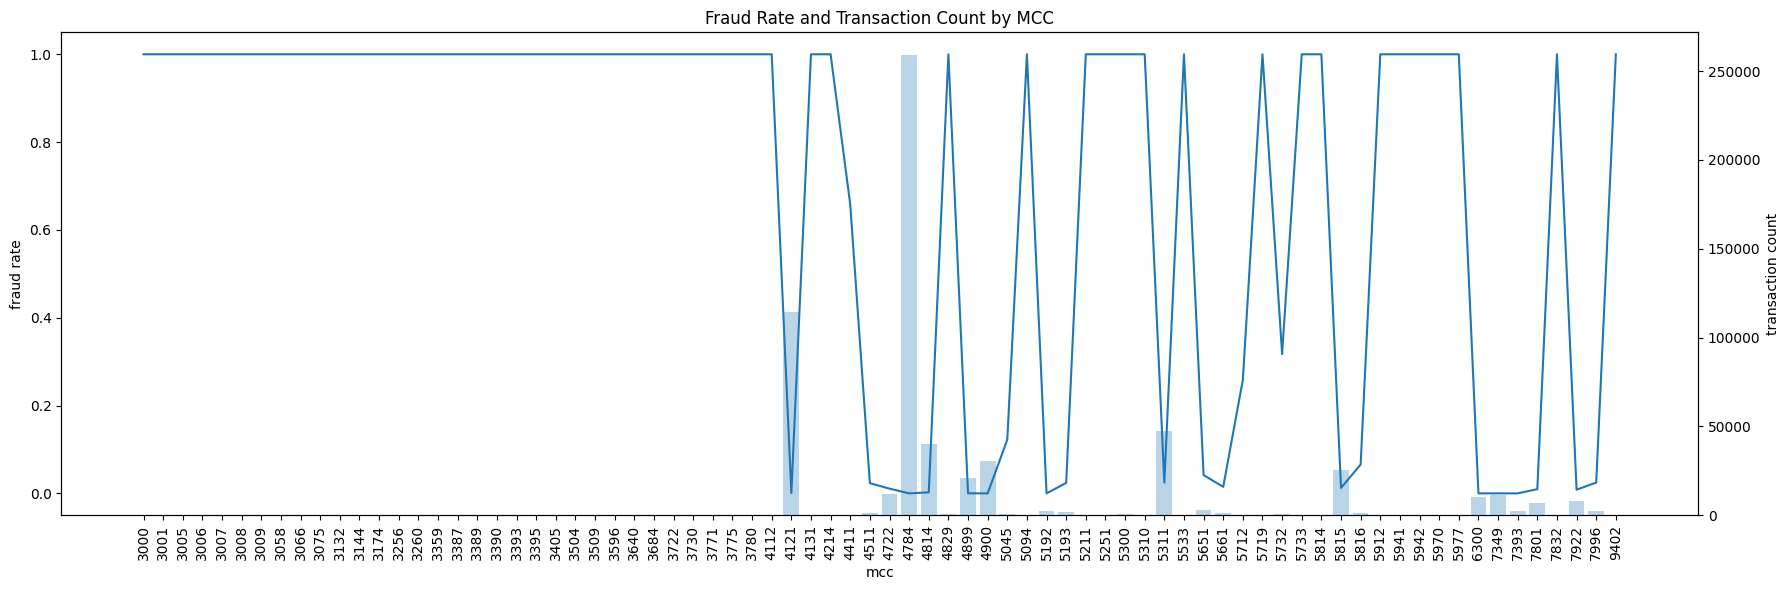

In [166]:
mcc_rate = df.groupby("mcc")["fraud"].mean()
mcc_count = df.groupby("mcc")["fraud"].count()

mcc_rate = mcc_rate.sort_index()
mcc_count = mcc_count.sort_index()

fig, ax1 = plt.subplots(figsize=(18,6))

# fraud rate
ax1.plot(mcc_rate.index.astype(str), mcc_rate.values)
ax1.set_xlabel("mcc")
ax1.set_ylabel("fraud rate")

ax1.set_xticks(range(len(mcc_rate)))
ax1.set_xticklabels(mcc_rate.index.astype(str), rotation=90)

# count
ax2 = ax1.twinx()
ax2.bar(range(len(mcc_count)), mcc_count.values, alpha=0.3)
ax2.set_ylabel("transaction count")

plt.title("Fraud Rate and Transaction Count by MCC")
plt.tight_layout()
plt.show()

In [190]:
df["fraud"].value_counts()

fraud
0    601862
1      6568
Name: count, dtype: int64

In [188]:
mcc_data = pd.concat([mcc_rate, mcc_count], axis=1)
mcc_data.columns = ["fraud_rate", "tx_count"]
mcc_data = mcc_data.sort_values("fraud_rate", ascending=False)
mcc_data.head(100)

,fraud_rate,tx_count
mcc,,
3000,1.000000,31
3001,1.000000,20
3005,1.000000,14
3006,1.000000,21
3007,1.000000,11
3008,1.000000,10
3009,1.000000,11
3058,1.000000,16
3066,1.000000,7


In [ ]:
mcc_stats = (
    df.groupby("mcc")
      .agg(
          fraud_rate=("fraud", "mean"),
          tx_count=("fraud", "count"),
      )
)

global_rate = df["fraud"].mean()
alpha = 1000

mcc_stats["smoothed_rate"] = (
    (mcc_stats["fraud_rate"] * mcc_stats["tx_count"]
     + alpha * global_rate)
    / (mcc_stats["tx_count"] + alpha)
)

In [192]:
df["mcc_smoothed_risk"] = df["mcc"].map(
    mcc_stats["smoothed_rate"]
)

In [194]:
high_risk_days = [0, 4, 6]

df["is_highrisk_weekday"] = df["weekday"].isin(high_risk_days).astype("int8")

In [205]:
df[["mcc_smoothed_risk"]+ BASELINE].corr()

,mcc_smoothed_risk,log_abs_amount,amount_income_ratio,amount_limit_ratio,has_error,credit_limit,current_age,is_credit,has_chip
mcc_smoothed_risk,1.000000,0.072581,0.003222,0.054920,0.013740,-0.029818,0.000084,0.020458,-0.006181
log_abs_amount,0.072581,1.000000,0.005831,0.032427,0.025821,0.062157,-0.030498,0.156772,-0.029288
amount_income_ratio,0.003222,0.005831,1.000000,0.062694,-0.001306,-0.012111,0.012805,-0.005186,0.002706
amount_limit_ratio,0.054920,0.032427,0.062694,1.000000,0.000508,-0.160437,0.006726,-0.071702,-0.017001
has_error,0.013740,0.025821,-0.001306,0.000508,1.000000,-0.005833,-0.000795,0.006104,-0.002665
credit_limit,-0.029818,0.062157,-0.012111,-0.160437,-0.005833,1.000000,-0.023226,-0.164848,0.004152
current_age,0.000084,-0.030498,0.012805,0.006726,-0.000795,-0.023226,1.000000,-0.007720,-0.017276
is_credit,0.020458,0.156772,-0.005186,-0.071702,0.006104,-0.164848,-0.007720,1.000000,0.004400
has_chip,-0.006181,-0.029288,0.002706,-0.017001,-0.002665,0.004152,-0.017276,0.004400,1.000000


In [204]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = sm.add_constant(df[BASELINE + ["mcc_smoothed_risk"]])

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,feature,VIF
0,const,42.837240
1,log_abs_amount,1.045066
2,amount_income_ratio,1.004145
3,amount_limit_ratio,1.047407
4,has_error,1.000869
5,credit_limit,1.072291
6,current_age,1.001931
7,is_credit,1.071524
8,has_chip,1.001558
9,mcc_smoothed_risk,1.009020


In [296]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def build_mcc_dummies(df, mcc_col="mcc", drop_first=True):
    X = pd.get_dummies(df[mcc_col].astype("int32"), prefix="mcc", drop_first=drop_first)
    return X

def drop_constant_cols(X: pd.DataFrame) -> pd.DataFrame:
    nun = X.nunique(dropna=False)
    return X.drop(columns=nun[nun <= 1].index, errors="ignore")

def drop_rare_cols(X: pd.DataFrame, min_pos=50) -> pd.DataFrame:
    # 더미가 1인 샘플 수가 너무 적으면 수치적으로 불안정 + 분리 잘 생김
    pos = X.sum(axis=0)
    return X.drop(columns=pos[pos < min_pos].index, errors="ignore")

def drop_perfect_separation_cols(X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    # 더미=1인 곳에서 y가 한쪽(0만 또는 1만)으로만 존재하면 제거
    yv = y.values
    drop_cols = []
    for c in X.columns:
        m = X[c].values.astype(bool)
        if m.sum() == 0:
            drop_cols.append(c); continue
        y_sub = yv[m]
        # y_sub가 모두 0이거나 모두 1이면 완전분리 가능성
        if y_sub.min() == y_sub.max():
            drop_cols.append(c)
    return X.drop(columns=drop_cols, errors="ignore")

def compute_vif_df(X: pd.DataFrame) -> pd.DataFrame:
    # VIF 계산(상수 제외)
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_ = X.copy()
    if "const" in X_.columns:
        X_ = X_.drop(columns=["const"])
    arr = X_.astype(float).values
    vifs = []
    for i, col in enumerate(X_.columns):
        vifs.append((col, variance_inflation_factor(arr, i)))
    return pd.DataFrame(vifs, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)

def fit_logit_drop_until_ok(df, y_col="fraud", mcc_col="mcc",
                           min_pos=50, max_drop_steps=500):
    y = df[y_col].astype("int8")

    # 1) 더미 생성 + 기본 정리
    X = build_mcc_dummies(df, mcc_col=mcc_col, drop_first=True)
    X = drop_constant_cols(X)
    X = drop_rare_cols(X, min_pos=min_pos)
    X = drop_perfect_separation_cols(X, y)

    # 상수 추가
    X = sm.add_constant(X, has_constant="add").astype("float64")

    dropped = []
    last_err = None

    for step in range(max_drop_steps + 1):
        try:
            model = sm.Logit(y, X).fit(disp=0, maxiter=200)
            return model, X, dropped
        except np.linalg.LinAlgError as e:
            # Singular matrix
            last_err = e

            # 2) VIF로 제일 문제 큰 애 하나 드랍
            vif_df = compute_vif_df(X)
            if vif_df.empty:
                raise

            worst = vif_df.iloc[0]["feature"]
            X = X.drop(columns=[worst], errors="ignore")
            dropped.append(worst)

        except Exception as e:
            # Perfect separation / convergence 등도 같이 처리(필요 시)
            last_err = e

            # 너무 희소한 컬럼 다시 한 번 제거 시도
            if "const" in X.columns:
                X_no_const = X.drop(columns=["const"])
            else:
                X_no_const = X

            pos = X_no_const.sum(axis=0)
            rare = pos[pos < min_pos].index.tolist()

            if rare:
                X = X.drop(columns=rare, errors="ignore")
                dropped.extend(rare)
                continue

            raise

    raise RuntimeError(f"Failed to fit after dropping {len(dropped)} cols. Last error: {last_err}")

# ---- 실행 ----
model, X_used, dropped_cols = fit_logit_drop_until_ok(
    df,
    y_col="fraud",
    mcc_col="mcc",
    min_pos=100,          # 너무 희소하면 올려 (50~500 사이 추천)
    max_drop_steps=1000
)

print("FIT OK. used cols:", X_used.shape[1], "dropped:", len(dropped_cols))
print("top dropped (first 20):", dropped_cols[:20])
print(model.summary())

FIT OK. used cols: 20 dropped: 0
top dropped (first 20): []
                           Logit Regression Results                           
Dep. Variable:                  fraud   No. Observations:               608430
Model:                          Logit   Df Residuals:                   608410
Method:                           MLE   Df Model:                           19
Date:                Fri, 20 Feb 2026   Pseudo R-squ.:                 0.09449
Time:                        14:54:35   Log-Likelihood:                -32849.
converged:                       True   LL-Null:                       -36277.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4164      0.017   -266.348      0.000      -4.449      -4.384
mcc_4121      -2.6154      0.101    -25.916      0.000      -2.813     

In [300]:
high = ["5732", "5712", "5045", "5816", "5651", "4411"]
mid  = ["5193", "5311", "7996"]

df["mcc_risk_level"] = 0
df.loc[df["mcc"].isin(mid), "mcc_risk_level"] = 1
df.loc[df["mcc"].isin(high), "mcc_risk_level"] = 2

In [301]:
df["mcc_risk_level"].value_counts()

mcc_risk_level
0    549993
1     52002
2      6435
Name: count, dtype: int64

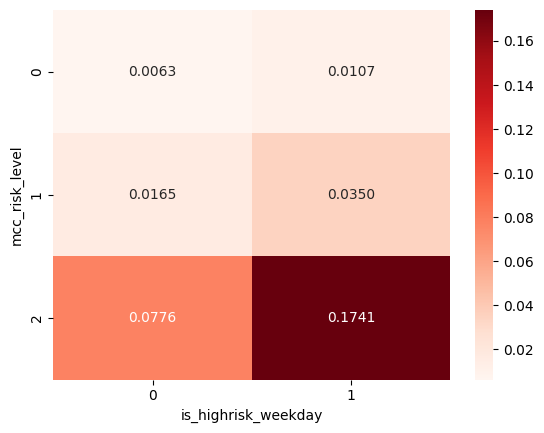

In [304]:
pivot = (
    df.groupby(["mcc_risk_level", "is_highrisk_weekday"])["fraud"]
      .mean()
      .unstack()
)

sns.heatmap(pivot, annot=True, fmt=".4f", cmap="Reds")
plt.show()

In [306]:
df["high_mcc_high_weekday"] = (
    (df["mcc_risk_level"] == 2) &
    (df["is_highrisk_weekday"] == 1)
).astype("int8")

In [307]:
CANDIDATES = [
   "is_highrisk_weekday", "mcc_smoothed_risk", "mcc_risk_level", "high_mcc_high_weekday"
]


def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

for col in CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,mcc_smoothed_risk,57.743512,1.195883e+25,0.000000e+00,0.092270,8.547505,62111
1,is_highrisk_weekday,0.621072,1.860922e+00,2.014609e-134,0.014603,1.352747,262756
2,mcc_risk_level,1.324449,3.760112e+00,0.000000e+00,0.010795,1.000000,608430
3,high_mcc_high_weekday,3.037507,2.085320e+01,0.000000e+00,0.010795,1.000000,608430


In [308]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in CANDIDATES:
    if col in BASELINE:
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)

=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,mcc_smoothed_risk,OK,53.476925,1.677774e+23,0.000000e+00,0.010795,0.092648,8.582521,0.050425,4.671133,60843
1,mcc_risk_level,OK,1.161635,3.195154e+00,0.000000e+00,0.010795,0.047006,4.354446,0.004783,0.443057,60843
2,high_mcc_high_weekday,OK,2.624875,1.380285e+01,0.000000e+00,0.010795,0.045264,4.193057,0.003041,0.281669,60843
3,is_highrisk_weekday,OK,0.631535,1.880495e+00,1.314522e-135,0.010795,0.044886,4.158039,0.002663,0.246650,60843


# 📦 Block: MCC Risk Structure

---

## ✅ 강력 유지 (핵심 리스크 축)

| Feature               | 판단            | 근거                                      |
| --------------------- | ------------- | --------------------------------------- |
| mcc_smoothed_risk     | **최상위 핵심 유지** | 압도적 ranking 개선, lift 폭발적 증가, 실질적 분리력 최고 |
| mcc_risk_level        | 유지            | 세그먼트형 MCC 리스크 구조, 안정적 개선                |
| high_mcc_high_weekday | 유지            | MCC × 요일 결합 구조 명확                       |
| is_highrisk_weekday   | 유지            | 요일 기반 리스크 패턴 독립적 존재                     |

---

## 🔎 구조 정리 필요 (중복 가능성)

| Feature               | 판단                       | 근거                            |
| --------------------- | ------------------------ | ----------------------------- |
| mcc_risk_level        | mcc_smoothed_risk와 관계 점검 | 연속형 vs 구간형 표현 중복 가능           |
| high_mcc_high_weekday | smoothed_risk와 부분 중복 가능  | 이미 리스크 스코어에 요일 효과 반영됐는지 확인 필요 |

---

## 🔎 Interaction 축 (상위 레이어 결합 가능성 매우 높음)

| Feature               | 판단                 | 근거                                               |
| --------------------- | ------------------ | ------------------------------------------------ |
| mcc_smoothed_risk     | Interaction 최우선 후보 | amount / error / refund / time과 결합 시 증폭 가능성 매우 큼 |
| high_mcc_high_weekday | Interaction 축 유지   | 시간 × 업종 구조 결합                                    |
| is_highrisk_weekday   | Interaction 가능     | error / 신규 merchant와 결합 가능                       |

---

# 🔎 MCC 블록 구조 요약

### 📌 절대 핵심 축

* mcc_smoothed_risk

### 📌 보조 리스크 세그먼트

* mcc_risk_level
* high_mcc_high_weekday
* is_highrisk_weekday

---

이 블록은 지금까지 전체 블록 중 **가장 강한 구조적 리스크 축**임.
특히 `mcc_smoothed_risk`는 interaction 설계 시 중심 노드 역할을 할 가능성 매우 높음.

---


### **6.3 MCC Behavioral Features**

In [206]:
df = df.sort_values(["client_id", "date"]).copy()
df["mcc"] = df["mcc"].astype("category")
g = df.groupby("client_id")["mcc"]

df["client_mcc_prev"] = g.shift(1)
df["client_mcc_match_last1"] = (df["mcc"] == df["client_mcc_prev"]).fillna(False).astype("int8")

In [207]:
# 최근 3/5거래에서 현재 mcc가 등장했는지 
m1 = (df["mcc"] == g.shift(1))
m2 = (df["mcc"] == g.shift(2))
m3 = (df["mcc"] == g.shift(3))
m4 = (df["mcc"] == g.shift(4))
m5 = (df["mcc"] == g.shift(5))

df["client_mcc_seen_last3"] = (m1 | m2 | m3).fillna(False).astype("int8")
df["client_mcc_seen_last5"] = (m1 | m2 | m3 | m4 | m5).fillna(False).astype("int8")

# 최근 3/5거래에서 현재 mcc가 몇 번 반복됐는지 (0~3 / 0~5)
df["client_mcc_repeat_cnt_last3"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8"))

df["client_mcc_repeat_cnt_last5"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8")
                                   + m4.fillna(False).astype("int8")
                                   + m5.fillna(False).astype("int8"))

# 비율 버전 (0~1)
df["client_mcc_repeat_ratio_last3"] = (df["client_mcc_repeat_cnt_last3"] / 3).astype("float32")
df["client_mcc_repeat_ratio_last5"] = (df["client_mcc_repeat_cnt_last5"] / 5).astype("float32")


In [208]:
df["client_mcc_prior_count"] = df.groupby(["client_id", "mcc"]).cumcount()
df["client_mcc_is_new"] = (df["client_mcc_prior_count"] == 0).astype("int8")

/tmp/ipykernel_2216042/2995284639.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["client_mcc_prior_count"] = df.groupby(["client_id", "mcc"]).cumcount()


In [209]:
prev = g.shift(1)
prev2 = g.shift(2)
prev3 = g.shift(3)
prev4 = g.shift(4)
prev5 = g.shift(5)

# 최근 5개에서 바뀐 횟수
# (prev5->prev4, prev4->prev3, prev3->prev2, prev2->prev1) 중 바뀐 횟수
chg1 = (prev  != prev2)
chg2 = (prev2 != prev3)
chg3 = (prev3 != prev4)
chg4 = (prev4 != prev5)

df["client_mcc_change_cnt_last5"] = (chg1.fillna(False).astype("int8")
                                  + chg2.fillna(False).astype("int8")
                                  + chg3.fillna(False).astype("int8")
                                  + chg4.fillna(False).astype("int8"))

In [210]:
g = df.groupby("card_id")["mcc"]

df["card_mcc_prev"] = g.shift(1)
df["card_mcc_match_last1"] = (df["mcc"] == df["card_mcc_prev"]).fillna(False).astype("int8")

In [211]:
# 최근 3/5거래에서 현재 mcc가 등장했는지 
m1 = (df["mcc"] == g.shift(1))
m2 = (df["mcc"] == g.shift(2))
m3 = (df["mcc"] == g.shift(3))
m4 = (df["mcc"] == g.shift(4))
m5 = (df["mcc"] == g.shift(5))

df["card_mcc_seen_last3"] = (m1 | m2 | m3).fillna(False).astype("int8")
df["card_mcc_seen_last5"] = (m1 | m2 | m3 | m4 | m5).fillna(False).astype("int8")

# 최근 3/5거래에서 '현재 mcc'가 몇 번 반복됐는지 (0~3 / 0~5)
df["card_mcc_repeat_cnt_last3"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8"))

df["card_mcc_repeat_cnt_last5"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8")
                                   + m4.fillna(False).astype("int8")
                                   + m5.fillna(False).astype("int8"))

# 비율 버전 (0~1)
df["card_mcc_repeat_ratio_last3"] = (df["card_mcc_repeat_cnt_last3"] / 3).astype("float32")
df["card_mcc_repeat_ratio_last5"] = (df["card_mcc_repeat_cnt_last5"] / 5).astype("float32")


In [212]:
df["card_mcc_prior_count"] = df.groupby(["card_id", "mcc"]).cumcount()
df["card_mcc_is_new"] = (df["card_mcc_prior_count"] == 0).astype("int8")

/tmp/ipykernel_2216042/2656056192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["card_mcc_prior_count"] = df.groupby(["card_id", "mcc"]).cumcount()


In [213]:
prev = g.shift(1)
prev2 = g.shift(2)
prev3 = g.shift(3)
prev4 = g.shift(4)
prev5 = g.shift(5)

chg1 = (prev  != prev2)
chg2 = (prev2 != prev3)
chg3 = (prev3 != prev4)
chg4 = (prev4 != prev5)

df["card_mcc_change_cnt_last5"] = (chg1.fillna(False).astype("int8")
                                  + chg2.fillna(False).astype("int8")
                                  + chg3.fillna(False).astype("int8")
                                  + chg4.fillna(False).astype("int8"))


In [214]:
def analyze_feature(df, feature):
    
    # Fraud rate 테이블
    table = (
        df.groupby(feature)["fraud"]
          .agg(["mean", "count"])
          .rename(columns={"mean": "fraud_rate"})
    )
    
    # baseline 계산
    baseline = table["fraud_rate"].min()
    table["uplift"] = table["fraud_rate"] / baseline
    
    display(table.round(4))
    
    plt.figure(figsize=(5,4))
    table["fraud_rate"].plot(kind="bar")
    plt.title(f"{feature} vs Fraud Rate")
    plt.ylabel("Fraud Rate")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


In [215]:
mcc_features = [
    "client_mcc_match_last1",
    "client_mcc_seen_last3",
    "client_mcc_seen_last5",
    "client_mcc_repeat_cnt_last3",
    "client_mcc_repeat_cnt_last5",
    "client_mcc_is_new",
    "client_mcc_change_cnt_last5",
    
    "card_mcc_match_last1",
    "card_mcc_seen_last3",
    "card_mcc_seen_last5",
    "card_mcc_repeat_cnt_last3",
    "card_mcc_repeat_cnt_last5",
    "card_mcc_is_new",
    "card_mcc_change_cnt_last5",
]


========== client_mcc_match_last1 ==========


,fraud_rate,count,uplift
client_mcc_match_last1,,,
0,0.0223,264579,11.3461
1,0.0020,343851,1.0000


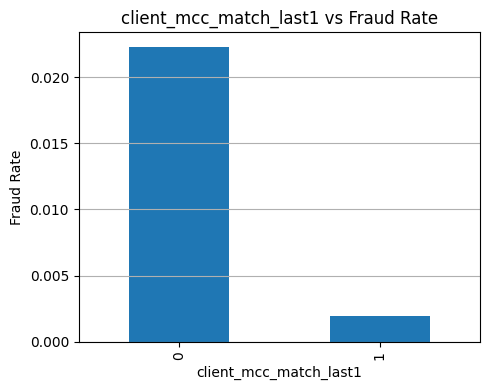


========== client_mcc_seen_last3 ==========


,fraud_rate,count,uplift
client_mcc_seen_last3,,,
0,0.0319,164655,10.8281
1,0.0029,443775,1.0000


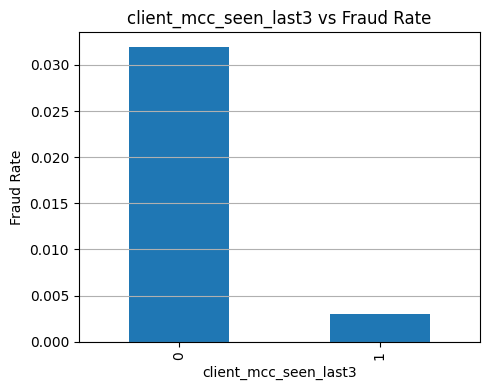


========== client_mcc_seen_last5 ==========


,fraud_rate,count,uplift
client_mcc_seen_last5,,,
0,0.0378,129231,10.7974
1,0.0035,479199,1.0000


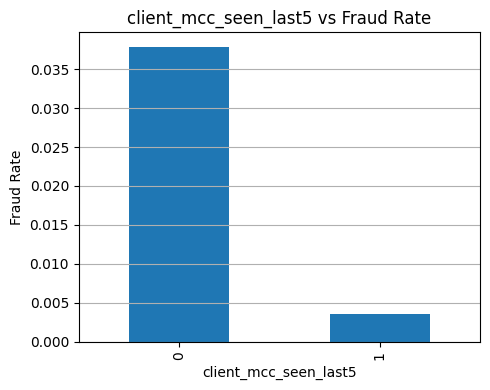


========== client_mcc_repeat_cnt_last3 ==========


,fraud_rate,count,uplift
client_mcc_repeat_cnt_last3,,,
0,0.0319,164655,572.7933
1,0.0109,100209,196.1433
2,0.0018,110428,32.4803
3,0.0001,233138,1.0000


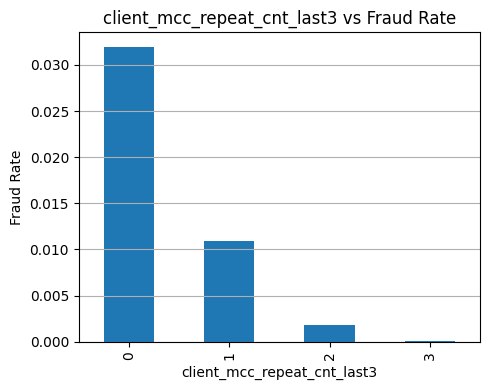


========== client_mcc_repeat_cnt_last5 ==========


,fraud_rate,count,uplift
client_mcc_repeat_cnt_last5,,,
0,0.0378,129231,7074.7516
1,0.0149,81841,2794.5597
2,0.0063,55697,1171.7946
3,0.0017,54027,314.9839
4,0.0001,100627,27.8763
5,0.0000,187007,1.0000


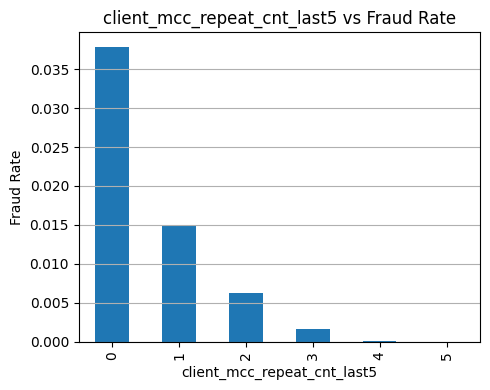


========== client_mcc_is_new ==========


,fraud_rate,count,uplift
client_mcc_is_new,,,
0,0.0049,591464,1.0000
1,0.2159,16966,43.9582


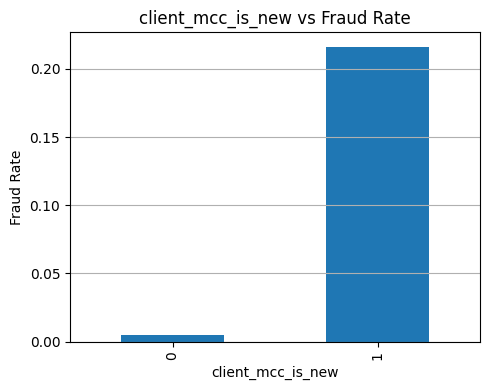


========== client_mcc_change_cnt_last5 ==========


,fraud_rate,count,uplift
client_mcc_change_cnt_last5,,,
0,0.0006,207304,1.0000
1,0.0041,59362,6.6795
2,0.0062,123838,10.1901
3,0.0168,116700,27.6044
4,0.0343,101226,56.4969


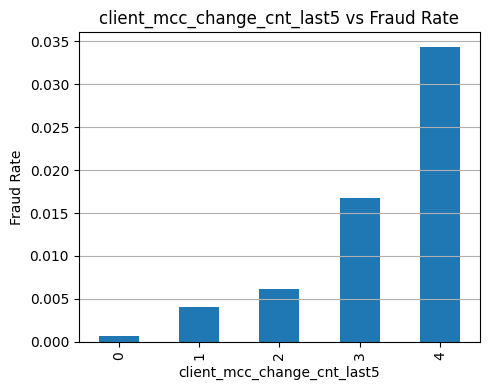


========== card_mcc_match_last1 ==========


,fraud_rate,count,uplift
card_mcc_match_last1,,,
0,0.0224,262926,11.2857
1,0.0020,345504,1.0000


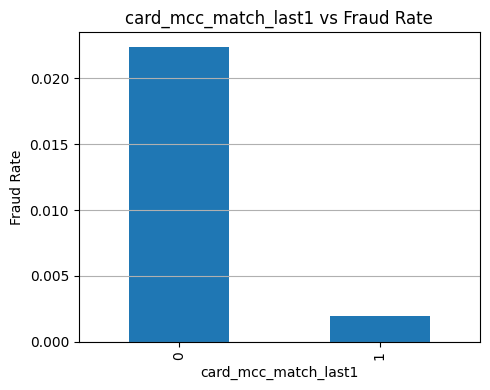


========== card_mcc_seen_last3 ==========


,fraud_rate,count,uplift
card_mcc_seen_last3,,,
0,0.0316,165349,10.3768
1,0.0030,443081,1.0000


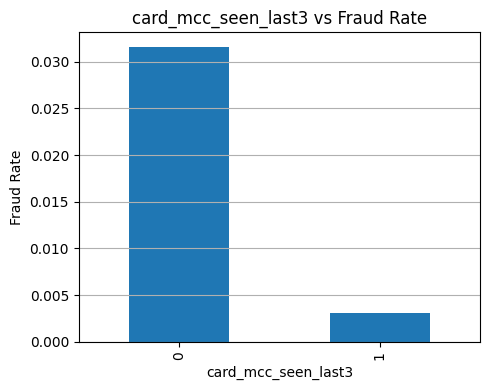


========== card_mcc_seen_last5 ==========


,fraud_rate,count,uplift
card_mcc_seen_last5,,,
0,0.0372,131085,10.4857
1,0.0035,477345,1.0000


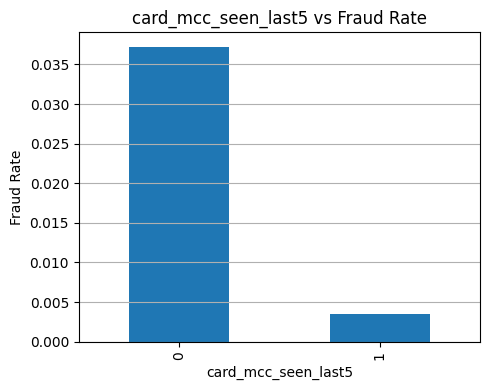


========== card_mcc_repeat_cnt_last3 ==========


,fraud_rate,count,uplift
card_mcc_repeat_cnt_last3,,,
0,0.0316,165349,494.9964
1,0.0114,98697,178.4058
2,0.0019,109191,30.1554
3,0.0001,235193,1.0000


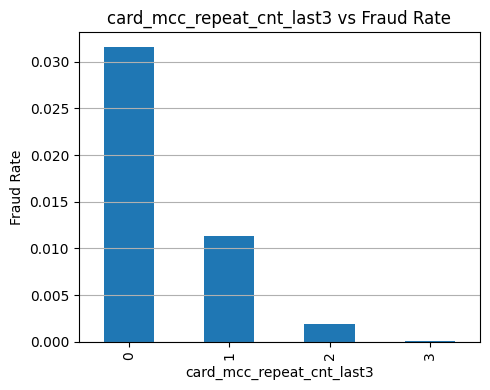


========== card_mcc_repeat_cnt_last5 ==========


,fraud_rate,count,uplift
card_mcc_repeat_cnt_last5,,,
0,0.0372,131085,inf
1,0.0152,80755,inf
2,0.0066,55327,inf
3,0.0015,53269,inf
4,0.0002,98894,inf
5,0.0000,189100,NaN


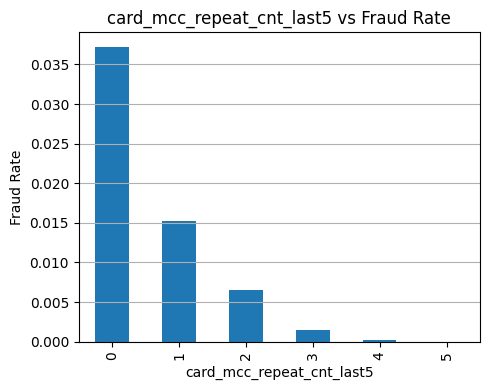


========== card_mcc_is_new ==========


,fraud_rate,count,uplift
card_mcc_is_new,,,
0,0.0043,573756,1.0000
1,0.1180,34674,27.3115


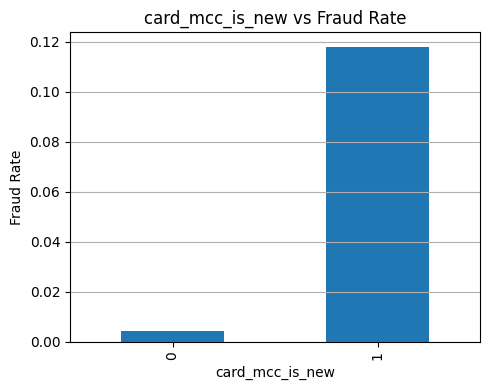


========== card_mcc_change_cnt_last5 ==========


,fraud_rate,count,uplift
card_mcc_change_cnt_last5,,,
0,0.0006,209091,1.0000
1,0.0043,59160,7.0408
2,0.0059,121493,9.7840
3,0.0167,113499,27.5609
4,0.0339,105187,55.8150


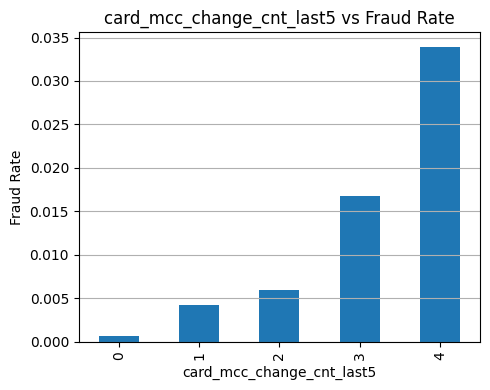

In [216]:
for f in mcc_features:
    print(f"\n========== {f} ==========")
    analyze_feature(df, f)


In [217]:
rows_uni = []

for col in mcc_features:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,client_mcc_repeat_cnt_last5,-1.083075,0.338553,0.0,0.037831,3.504538,129231
1,client_mcc_seen_last5,-2.414360,0.089425,0.0,0.037831,3.504538,129231
2,card_mcc_repeat_cnt_last5,-1.066509,0.344208,0.0,0.037190,3.445078,131085
3,card_mcc_seen_last5,-2.384357,0.092148,0.0,0.037190,3.445078,131085
4,client_mcc_change_cnt_last5,0.881025,2.413373,0.0,0.034339,3.181011,101226
5,card_mcc_change_cnt_last5,0.877793,2.405585,0.0,0.033902,3.140485,105187
6,client_mcc_seen_last3,-2.411649,0.089667,0.0,0.031940,2.958733,164655
7,client_mcc_repeat_cnt_last3,-1.445247,0.235688,0.0,0.031940,2.958733,164655
8,card_mcc_repeat_cnt_last3,-1.414517,0.243043,0.0,0.031570,2.924465,165349
9,card_mcc_seen_last3,-2.368601,0.093612,0.0,0.031570,2.924465,165349


In [218]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in mcc_features:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)

=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_mcc_is_new,OK,3.277820,26.517909,0.0,0.010795,0.075818,7.023447,0.033595,3.112058,60843
1,client_mcc_is_new,OK,3.886426,48.736400,0.0,0.010795,0.072728,6.737211,0.030505,2.825822,60843
2,client_mcc_repeat_cnt_last5,OK,-1.077757,0.340358,0.0,0.010795,0.049669,4.601096,0.007445,0.689708,60843
3,card_mcc_repeat_cnt_last5,OK,-1.061068,0.346086,0.0,0.010795,0.049389,4.575213,0.007166,0.663825,60843
4,client_mcc_seen_last5,OK,-2.294327,0.100829,0.0,0.010795,0.049028,4.541717,0.006804,0.630329,60843
5,card_mcc_seen_last5,OK,-2.257914,0.104568,0.0,0.010795,0.048699,4.511267,0.006476,0.599878,60843
6,card_mcc_change_cnt_last5,OK,0.829549,2.292284,0.0,0.010795,0.047894,4.436663,0.005670,0.525274,60843
7,client_mcc_change_cnt_last5,OK,0.824214,2.280089,0.0,0.010795,0.047499,4.400122,0.005276,0.488733,60843
8,client_mcc_repeat_cnt_last3,OK,-1.415864,0.242716,0.0,0.010795,0.046316,4.290499,0.004093,0.379111,60843
9,client_mcc_seen_last3,OK,-2.289103,0.101357,0.0,0.010795,0.046250,4.284409,0.004027,0.373021,60843


# 📦 Block: MCC Behavioral Pattern (Client / Card Habit Structure)

---

## ✅ 최상위 핵심 유지 (폭발적 분리력)

| Feature           | 판단               | 근거                          |
| ----------------- | ---------------- | --------------------------- |
| client_mcc_is_new | **강력 유지 (핵심 축)** | lift 대폭 증가, 신규 업종은 강한 이상 패턴 |
| card_mcc_is_new   | **강력 유지 (핵심 축)** | client 기준과 독립적으로 강함         |

---

## ✅ 강한 유지 (습관 안정성 / 반복 구조)

| Feature                     | 판단 | 근거            |
| --------------------------- | -- | ------------- |
| client_mcc_repeat_cnt_last5 | 유지 | 반복 감소는 위험 신호  |
| card_mcc_repeat_cnt_last5   | 유지 | 위와 동일 구조      |
| client_mcc_seen_last5       | 유지 | 익숙한 업종은 보호 신호 |
| card_mcc_seen_last5         | 유지 | 안정성 신호        |
| client_mcc_change_cnt_last5 | 유지 | 업종 변화는 리스크 신호 |
| card_mcc_change_cnt_last5   | 유지 | 일관된 구조        |

---

## 🔎 구조 정리 필요 (window 압축)

| Feature           | 판단    | 근거                |
| ----------------- | ----- | ----------------- |
| last3 vs last5 계열 | 정리 필요 | 윈도우 중복, 다중공선성 가능성 |
| match_last1       | 유지 가능 | 최근성 신호로 의미 있음     |

> repeat / seen / change 계열은 구조상 강력하나
> **window 선택 최적화 필요**

---

## 🔥 Interaction 최우선 후보

| Feature                     | 판단              | 근거                                                   |
| --------------------------- | --------------- | ---------------------------------------------------- |
| client_mcc_is_new           | Interaction 최우선 | amount / error / highrisk_weekday와 결합 시 증폭 가능성 매우 높음 |
| card_mcc_is_new             | Interaction 최우선 | 동일                                                   |
| client_mcc_change_cnt_last5 | Interaction 유력  | 변화 × 금액 / error 구조                                   |
| card_mcc_change_cnt_last5   | Interaction 유력  | 동일                                                   |

---

# 🔎 MCC Habit 블록 구조 요약

### 📌 신규성 축 (Anomaly Trigger)

* client_mcc_is_new
* card_mcc_is_new

### 📌 안정성 축 (Protection)

* repeat_cnt
* seen_cnt
* match_last1

### 📌 변화 축 (Volatility)

* change_cnt_last5

---

이 블록은 MCC Risk 블록과 함께
**현재까지 전체 구조 중 가장 강력한 Behavioral Risk Layer**임.

특히:

> mcc_smoothed_risk (업종 자체 위험도)
> ×
> mcc_is_new / change_cnt (고객 습관 대비 이탈)

이 결합은 interaction 설계 시 매우 강력할 가능성이 높음.

---

---
# 7. Merchant Novelty & Switching Block

> 카드/고객 기준 상점 변화 탐지

- merchant_is_new

- card_merchant_is_new

- merchant_change_cnt_last5

- merchant_is_new_x_has_error

- merchant_is_new_x_mcc_is_new

---

**client_merchant_is_new / card_merchant_is_new**

In [219]:
df["client_merchant_is_new"] = (
    df.groupby(["client_id", "merchant_id"], sort=False).cumcount().eq(0).astype("int8")
)

df["card_merchant_is_new"] = (
    df.groupby(["card_id", "merchant_id"], sort=False).cumcount().eq(0).astype("int8")
)

**merchant_change_cnt_last5 (최근 5건에서 merchant가 몇 번 바뀌었는지)**

In [220]:
prev_merchant = df.groupby("card_id", sort=False)["merchant_id"].shift(1)

df["merchant_changed"] = (
    df["merchant_id"].ne(prev_merchant)      # 직전과 다르면 True
    .fillna(True)                            # 첫 거래는 변경
    .astype("int8")
)

# 2) 최근 5건에서 변경 횟수
df["merchant_change_cnt_last5"] = (
    df.groupby("card_id", sort=False)["merchant_changed"]
      .rolling(window=5, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
      .astype("int8")
)

df.drop(columns=["merchant_changed"], inplace=True)

**merchant_is_new × mcc_is_new / has_error**

In [221]:
# merchant_is_new 정의(카드 기준)
df["merchant_is_new"] = df["card_merchant_is_new"].astype("int8")

# merchant_is_new × mcc_is_new 
if "card_mcc_is_new" in df.columns:
    df["merchant_is_new_x_mcc_is_new"] = (
        df["merchant_is_new"].astype("int8") * df["card_mcc_is_new"].astype("int8")
    ).astype("int8")
else:
    # 없으면 대체: card 단위로 mcc 첫 등장 여부 생성
    df["card_mcc_is_new"] = (
        df.groupby(["card_id", "mcc"], sort=False).cumcount().eq(0).astype("int8")
    )
    df["merchant_is_new_x_mcc_is_new"] = (
        df["merchant_is_new"] * df["card_mcc_is_new"]
    ).astype("int8")

# merchant_is_new × has_error
df["merchant_is_new_x_has_error"] = (
    df["merchant_is_new"].astype("int8") * df["has_error"].astype("int8")
).astype("int8")

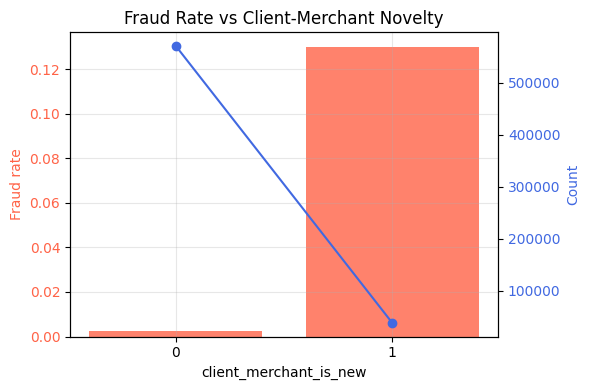

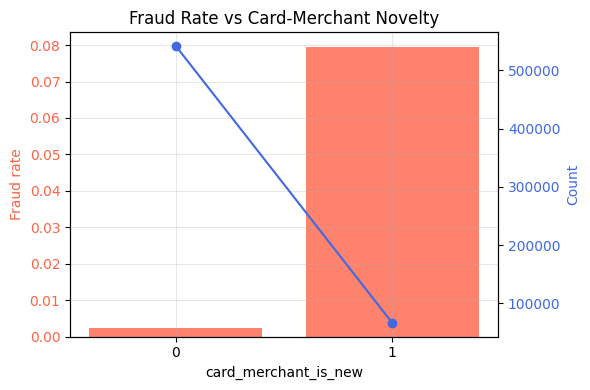

In [222]:
def plot_rate_and_count_by_flag(df, flag_col, title):
    g = df.groupby(flag_col)["fraud"].agg(rate="mean", cnt="size")
    fig, ax1 = plt.subplots(figsize=(6,4))

    # fraud rate (bar)
    ax1.bar(g.index.astype(str), g["rate"], color="tomato", alpha=0.8)
    ax1.set_ylabel("Fraud rate", color="tomato")
    ax1.set_xlabel(flag_col)
    ax1.set_title(title)
    ax1.tick_params(axis="y", labelcolor="tomato")
    ax1.grid(True, alpha=0.3)

    # count (line)
    ax2 = ax1.twinx()
    ax2.plot(g.index.astype(str), g["cnt"], color="royalblue", marker="o")
    ax2.set_ylabel("Count", color="royalblue")
    ax2.tick_params(axis="y", labelcolor="royalblue")

    plt.tight_layout()
    plt.show()

plot_rate_and_count_by_flag(df, "client_merchant_is_new", 
                            "Fraud Rate vs Client-Merchant Novelty")

plot_rate_and_count_by_flag(df, "card_merchant_is_new", 
                            "Fraud Rate vs Card-Merchant Novelty")


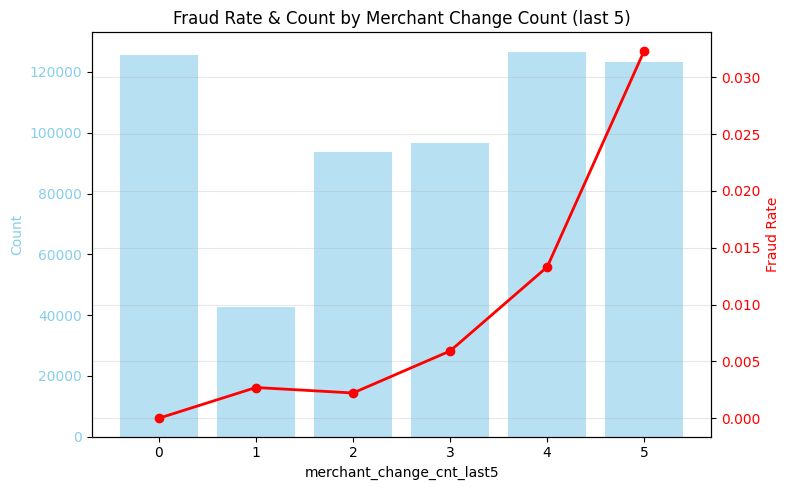

In [309]:
tmp = (
    df.groupby("merchant_change_cnt_last5")["fraud"]
      .agg(rate="mean", cnt="size")
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8,5))

# --- 1) Count (막대) ---
ax1.bar(
    tmp["merchant_change_cnt_last5"].astype(str),
    tmp["cnt"],
    color="skyblue",
    alpha=0.6,
    label="Count"
)
ax1.set_xlabel("merchant_change_cnt_last5")
ax1.set_ylabel("Count", color="skyblue")
ax1.tick_params(axis='y', labelcolor="skyblue")

# --- 2) Fraud Rate (선) ---
ax2 = ax1.twinx()
ax2.plot(
    tmp["merchant_change_cnt_last5"].astype(str),
    tmp["rate"],
    color="red",
    marker="o",
    linewidth=2,
    label="Fraud Rate"
)
ax2.set_ylabel("Fraud Rate", color="red")
ax2.tick_params(axis='y', labelcolor="red")

plt.title("Fraud Rate & Count by Merchant Change Count (last 5)")
plt.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

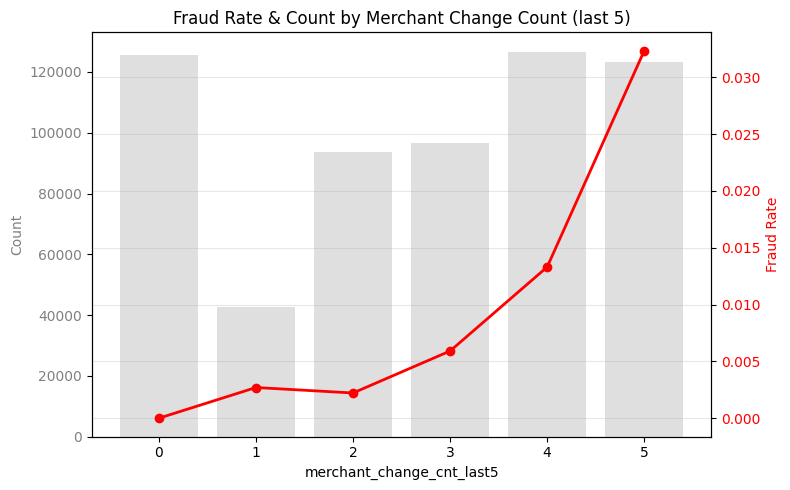

In [310]:
tmp = (
    df.groupby("merchant_change_cnt_last5")["fraud"]
      .agg(rate="mean", cnt="size")
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8,5))

x = tmp["merchant_change_cnt_last5"]

# --- 1) Count (뒤에 투명 막대) ---
ax1.bar(
    x,
    tmp["cnt"],
    color="gray",
    alpha=0.25
)
ax1.set_ylabel("Count", color="gray")
ax1.tick_params(axis='y', labelcolor="gray")

# --- 2) Fraud Rate (앞에 선 그래프) ---
ax2 = ax1.twinx()
ax2.plot(
    x,
    tmp["rate"],
    marker="o",
    linewidth=2,
    color="red"
)
ax2.set_ylabel("Fraud Rate", color="red")
ax2.tick_params(axis='y', labelcolor="red")

ax1.set_xlabel("merchant_change_cnt_last5")
plt.title("Fraud Rate & Count by Merchant Change Count (last 5)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [225]:
cols = ["merchant_is_new_x_has_error",
        "merchant_is_new_x_mcc_is_new",
        "merchant_change_cnt_last5",
        "card_merchant_is_new",
        "client_merchant_is_new"]

In [226]:
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,card_merchant_is_new,3.606242,36.827398,0.0,0.079523,7.366696,66647
1,merchant_change_cnt_last5,0.881115,2.413589,0.0,0.032337,2.995584,123325
2,merchant_is_new_x_has_error,2.761005,15.815731,0.0,0.010795,1.000000,608430
3,merchant_is_new_x_mcc_is_new,3.427844,30.810149,0.0,0.010795,1.000000,608430
4,client_merchant_is_new,4.001996,54.707253,0.0,0.010795,1.000000,608430


In [228]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,client_merchant_is_new,OK,4.060571,58.007436,0.000000e+00,0.010795,0.085992,7.965895,0.043768,4.054507,60843
1,card_merchant_is_new,OK,3.574467,35.675615,0.000000e+00,0.010795,0.080469,7.454324,0.038246,3.542935,60843
2,merchant_is_new_x_mcc_is_new,OK,3.277070,26.498023,0.000000e+00,0.010795,0.075802,7.021924,0.033578,3.110536,60843
3,merchant_change_cnt_last5,OK,0.847215,2.333140,0.000000e+00,0.010795,0.049340,4.570646,0.007117,0.659257,60843
4,merchant_is_new_x_has_error,OK,3.139197,23.085321,1.617344e-97,0.010795,0.043933,4.069732,0.001709,0.158343,60843


# 📦 Block: Merchant Novelty / Merchant Behavior

---

## 🔥 최상위 핵심 축 (현재 전체 중 최강 레벨)

| Feature                      | 판단                          | 근거                                  |
| ---------------------------- | --------------------------- | ----------------------------------- |
| client_merchant_is_new       | **최우선 핵심 유지**               | lift 대폭 증가, 고객 기준 신규 가맹점은 강력한 이상 신호 |
| card_merchant_is_new         | **강력 유지**                   | 카드 기준 신규도 독립적으로 강함                  |
| merchant_is_new_x_mcc_is_new | **강력 유지 (구조적 interaction)** | 업종 신규 + 가맹점 신규 결합 구조                |

---

## ✅ 강한 유지 (행동 변화 축)

| Feature                     | 판단 | 근거                       |
| --------------------------- | -- | ------------------------ |
| merchant_change_cnt_last5   | 유지 | 가맹점 변화는 일관된 리스크 신호       |
| merchant_is_new_x_has_error | 유지 | 신규 가맹점 × 에러 결합은 구조적으로 타당 |

---

# 🔎 Merchant 블록 구조 요약

### 📌 신규성 축 (가장 강력한 이상 트리거)

* client_merchant_is_new
* card_merchant_is_new

### 📌 구조 결합 축

* merchant_is_new_x_mcc_is_new
* merchant_is_new_x_has_error

### 📌 변화 축

* merchant_change_cnt_last5

---

# 🔎 전체적으로 봤을 때

지금까지 나온 모든 블록 중에서

> 🔥 Merchant Novelty 계열
> 🔥 MCC Novelty 계열
> 🔥 MCC Risk 계열

이 세 축이 **현재 구조상 가장 강력한 리스크 중심 노드**임.

특히:

* client_merchant_is_new
* client_mcc_is_new
* mcc_smoothed_risk

이 세 개는 interaction 설계 시 핵심 허브가 될 가능성이 매우 높음.

---

---

# 8. Velocity & Interval Block

> 단시간 급격한 변화 탐지

## 8.1 Interval Features

- seconds_since_prev_tx

- client_avg_interval_prev

- interval_ratio

- log_interval_dev

## 8.2 Velocity Features

- client_tx_1h

- client_tx_1h_avg_prev

- velocity_spike_ratio

- card_tx_1h

- card_velocity_spike_ratio

## 8.3 Burst / Deviation

---

### **8.1 Interval Features**

- seconds_since_prev_tx

- client_avg_interval_prev

- interval_ratio

- log_interval_dev

In [229]:
# 1) 이전 거래 시점
df["prev_tx_time"] = df.groupby("client_id")["date"].shift(1)

# 2) 초 단위 간격
df["seconds_since_prev_tx"] = (
    (df["date"] - df["prev_tx_time"]).dt.total_seconds()
)

# 첫 거래는 간격 없음 → 큰 값으로 처리 (중립)
df["seconds_since_prev_tx"] = df["seconds_since_prev_tx"].fillna(0)

# 로그 변환
df["log_interval"] = np.log1p(df["seconds_since_prev_tx"])

In [ ]:
# 과거값 shift
df["log_interval_shift"] = df.groupby("client_id")["log_interval"].shift(1)

# 누적합
df["interval_cumsum"] = (
    df["log_interval_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

# 과거 개수
df["interval_cnt_past"] = df.groupby("client_id").cumcount()

# 과거 평균
df["client_avg_interval_prev"] = np.where(
    df["interval_cnt_past"] > 0,
    df["interval_cumsum"] / df["interval_cnt_past"],
    df["log_interval"] 
)


In [231]:
# ratio
df["interval_ratio"] = (
    df["log_interval"] /
    (df["client_avg_interval_prev"] + 1e-6)
)

# deviation (z-score 방식)
df["log_interval_dev"] = (
    df["log_interval"] -
    df["client_avg_interval_prev"]
)

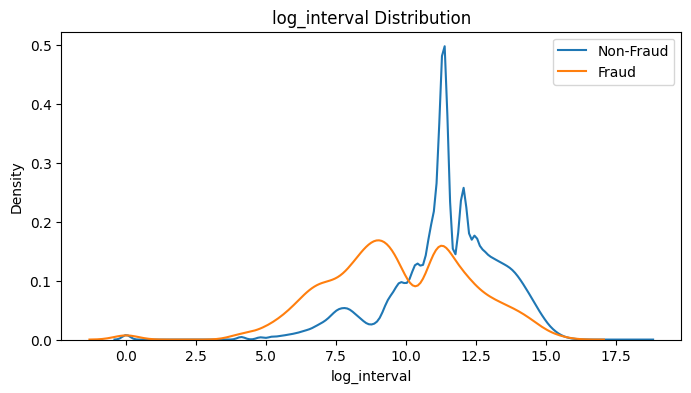

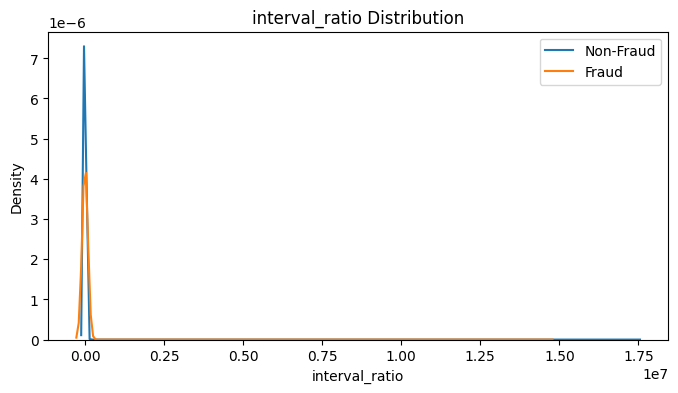

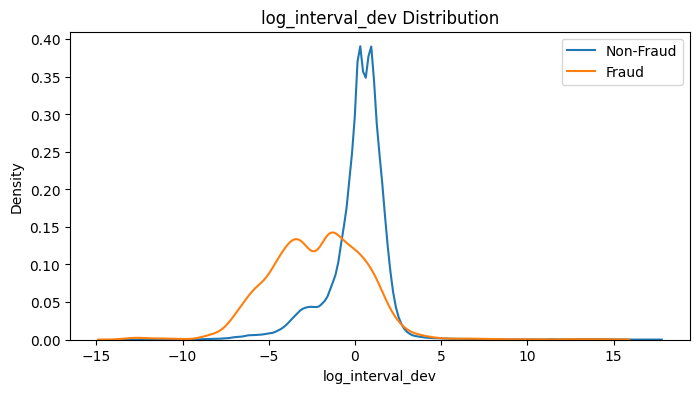

In [232]:
sample = df.copy()

features = [
    "log_interval",
    "interval_ratio",
    "log_interval_dev"
]

for col in features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(sample[sample["fraud"]==0][col], label="Non-Fraud")
    sns.kdeplot(sample[sample["fraud"]==1][col], label="Fraud")
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()


In [233]:
cols = [
    "seconds_since_prev_tx",
    "client_avg_interval_prev",
    "interval_ratio",
    "log_interval_dev"
]

In [234]:
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)


display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,log_interval_dev,-4.276907e-01,0.652013,0.000000e+00,0.053219,4.929963,60843
1,interval_ratio,-7.049454e-09,1.000000,7.555209e-01,0.051559,4.776188,60843
2,seconds_since_prev_tx,-8.335428e-07,0.999999,6.266262e-97,0.035169,3.257940,60962
3,client_avg_interval_prev,5.241944e-01,1.689097,0.000000e+00,0.023010,2.131547,60843


In [235]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,log_interval_dev,OK,-4.170605e-01,0.658981,0.000000e+00,0.010795,0.062094,5.752132,0.019871,1.840743,60843
1,seconds_since_prev_tx,OK,-1.243379e-06,0.999999,1.261430e-173,0.010795,0.053449,4.951279,0.011226,1.039890,60843
2,interval_ratio,OK,-2.970384e-08,1.000000,1.980713e-01,0.010795,0.042240,3.912911,0.000016,0.001523,60843
3,client_avg_interval_prev,OK,3.685179e-01,1.445590,2.092756e-177,0.010795,0.037967,3.517052,-0.004257,-0.394336,60843


# 📦 Block: Velocity / Interval Deviation

---

## 🔥 강력 유지 (핵심 속도 이탈 신호)

| Feature               | 판단               | 근거                                      |
| --------------------- | ---------------- | --------------------------------------- |
| log_interval_dev      | **강력 유지 (핵심 축)** | lift 크게 개선, 고객 평균 간격 대비 이탈은 매우 강한 이상 신호 |
| seconds_since_prev_tx | **유지**           | 최근 거래 간격 자체도 독립적 분리력 존재                 |

---

## 🔎 조건부 유지

| Feature                  | 판단     | 근거                             |
| ------------------------ | ------ | ------------------------------ |
| client_avg_interval_prev | 조건부 유지 | 평균 간격은 보조 지표이나 ranking 개선은 제한적 |

---

## ❌ 제거

| Feature        | 판단 | 근거             |
| -------------- | -- | -------------- |
| interval_ratio | 제거 | 유의성 없음, 설명력 미미 |

---

# 🔎 Velocity 블록 구조 요약

### 📌 핵심 이상 탐지 축

* log_interval_dev (가장 중요)
* seconds_since_prev_tx

### 📌 보조 안정성 지표

* client_avg_interval_prev

---

# 🔎 전체 누적 구조 관점

Velocity 블록은 지금까지 나온 구조 중

> Merchant 신규성
> MCC 신규성
> MCC 위험도

다음으로 강력한 **“행동 이탈 축”**임.

특히:

* log_interval_dev
* client_merchant_is_new
* client_mcc_is_new

이 조합은 interaction 설계 시 매우 유력한 이상 패턴 클러스터를 형성할 가능성이 높음.

---


### **8.2 Velocity Features**

- client_tx_1h

- client_tx_1h_avg_prev

- velocity_spike_ratio

- card_tx_1h

- card_velocity_spike_ratio

In [236]:
df = df.sort_values(["client_id", "date"]).reset_index(drop=True)

# numpy index 준비
n = len(df)

client_tx_1h = np.zeros(n, dtype=np.int32)
card_tx_1h = np.zeros(n, dtype=np.int32)

> 각 거래 시점 기준, 최근 1시간 내에 같은 고객이 몇 번 거래했는가?

In [237]:
for cid, idx in df.groupby("client_id").groups.items():
    g = df.loc[idx]
    times = g["date"].values.astype("datetime64[s]").astype("int64")
    
    # 누적 거래 번호
    cum = np.arange(len(g))
    
    # 1시간 전 timestamp
    t_minus_1h = times - 3600
    
    left = np.searchsorted(times, t_minus_1h)
    
    client_tx_1h[idx] = cum - left + 1

In [238]:
df["client_tx_1h"] = client_tx_1h

In [ ]:
df["client_tx_1h_shift"] = df.groupby("client_id")["client_tx_1h"].shift(1)

# 지금까지의 (과거) 1시간 거래 수 총합
df["client_tx_1h_cumsum"] = (
    df["client_tx_1h_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

# 과거 거래 개수
df["client_tx_cnt_past"] = df.groupby("client_id").cumcount()

# 과거 평균 계산
df["client_tx_1h_avg_prev"] = np.where(
    df["client_tx_cnt_past"] > 0,
    df["client_tx_1h_cumsum"] / df["client_tx_cnt_past"],
    df["client_tx_1h"]
)

In [ ]:
# 현재 1시간 거래 수가 평소 평균 대비 몇 배인가? 
df["velocity_spike_ratio"] = (
    df["client_tx_1h"] /
    (df["client_tx_1h_avg_prev"] + 1e-6)
)

In [241]:
for cid, idx in df.groupby("card_id").groups.items():
    g = df.loc[idx]
    times = g["date"].values.astype("datetime64[s]").astype("int64")
    
    cum = np.arange(len(g))
    t_minus_1h = times - 3600
    
    left = np.searchsorted(times, t_minus_1h)
    
    card_tx_1h[idx] = cum - left + 1

df["card_tx_1h"] = card_tx_1h

In [242]:
df["card_tx_1h_shift"] = df.groupby("card_id")["card_tx_1h"].shift(1)

df["card_tx_1h_cumsum"] = (
    df["card_tx_1h_shift"].fillna(0)
      .groupby(df["card_id"])
      .cumsum()
)

df["card_tx_cnt_past"] = df.groupby("card_id").cumcount()

df["card_tx_1h_avg_prev"] = np.where(
    df["card_tx_cnt_past"] > 0,
    df["card_tx_1h_cumsum"] / df["card_tx_cnt_past"],
    df["card_tx_1h"]
)

df["card_velocity_spike_ratio"] = (
    df["card_tx_1h"] /
    (df["card_tx_1h_avg_prev"] + 1e-6)
)

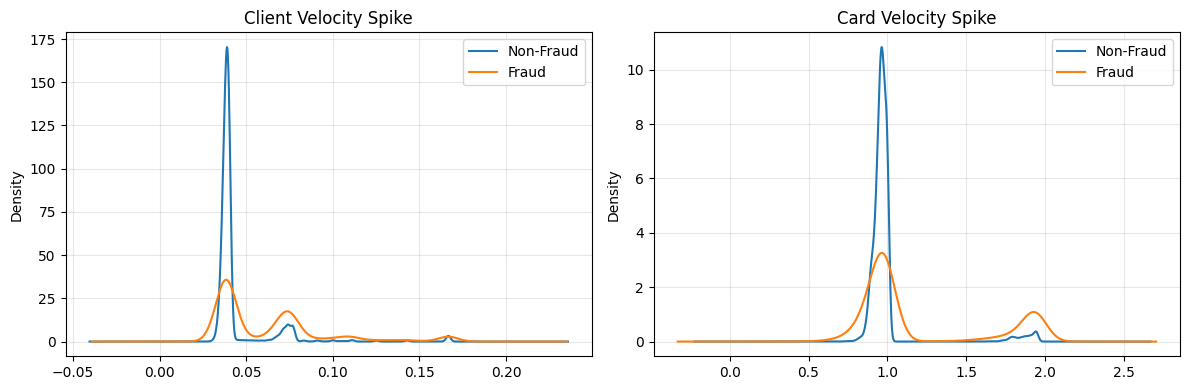

In [311]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Client
xmax = df["velocity_spike_ratio"].quantile(0.99)
df[df["fraud"]==0]["velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[0], label="Non-Fraud"
)
df[df["fraud"]==1]["velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[0], label="Fraud"
)
axes[0].set_title("Client Velocity Spike")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Card
xmax = df["card_velocity_spike_ratio"].quantile(0.99)
df[df["fraud"]==0]["card_velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[1], label="Non-Fraud"
)
df[df["fraud"]==1]["card_velocity_spike_ratio"].clip(upper=xmax).plot(
    kind="kde", ax=axes[1], label="Fraud"
)
axes[1].set_title("Card Velocity Spike")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

> -> 딘독으로는 약할 수 있음

In [312]:
df["vel_x_error"] = (
    df["velocity_spike_ratio"] *
    df["has_error"]
)
df["vel_x_mcc_risk"] = (
    df["velocity_spike_ratio"] *
    df["mcc_risk_level"]
)
df["vel_x_high_mcc"] = (
    df["velocity_spike_ratio"] *
    (df["mcc_risk_level"] == 2).astype("int8")
)
df["vel_x_merchant_new"] = (
    df["velocity_spike_ratio"] *
    df["merchant_is_new"]
)
df["vel_x_client_mcc_new"] = (
    df["velocity_spike_ratio"] *
    df["client_mcc_is_new"]
)
df["vel_x_card_mcc_new"] = (
    df["velocity_spike_ratio"] *
    df["card_mcc_is_new"]
)
df["high_vel_flag"] = (
    df["velocity_spike_ratio"] >
    df["velocity_spike_ratio"].quantile(0.95)
).astype("int8")

df["high_vel_error"] = df["high_vel_flag"] * df["has_error"]
df["high_vel_new_mcc"] = df["high_vel_flag"] * df["client_mcc_is_new"]

In [313]:
cols = [
"client_tx_1h",
"client_tx_1h_avg_prev",
"velocity_spike_ratio",
"card_tx_1h",
"card_velocity_spike_ratio",
"vel_x_error",
"vel_x_mcc_risk",
"vel_x_high_mcc",
"vel_x_merchant_new",
"vel_x_client_mcc_new",
"vel_x_card_mcc_new",
"high_vel_flag",
"high_vel_error",
"high_vel_new_mcc"
]

rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,vel_x_merchant_new,7.965297,2.879286e+03,0.000000e+00,0.077851,7.211747,62851
1,velocity_spike_ratio,6.004330,4.051795e+02,0.000000e+00,0.040026,3.707859,62284
2,card_velocity_spike_ratio,1.980728,7.248018e+00,0.000000e+00,0.023123,2.141979,136403
3,client_tx_1h_avg_prev,-6.012534,2.447878e-03,2.511206e-114,0.018193,1.685333,60902
4,card_tx_1h,1.854879,6.390923e+00,0.000000e+00,0.010795,1.000000,608430
5,client_tx_1h,1.274816,3.578041e+00,0.000000e+00,0.010795,1.000000,608430
6,vel_x_error,4.474862,8.778245e+01,4.964725e-16,0.010795,1.000000,608430
7,vel_x_mcc_risk,9.466413,1.291847e+04,0.000000e+00,0.010795,1.000000,608430
8,vel_x_high_mcc,29.262076,5.109262e+12,7.928839e-294,0.010795,1.000000,608430
9,vel_x_client_mcc_new,7.374615,1.594978e+03,0.000000e+00,0.010795,1.000000,608430


In [314]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,vel_x_merchant_new,OK,7.541102,1.883906e+03,0.000000e+00,0.010795,0.055799,5.169001,0.013576,1.257613,60843
1,vel_x_card_mcc_new,OK,6.951964,1.045201e+03,0.000000e+00,0.010795,0.053104,4.919306,0.010880,1.007917,60843
2,vel_x_client_mcc_new,OK,6.998846,1.095368e+03,0.000000e+00,0.010795,0.052923,4.902558,0.010700,0.991169,60843
3,card_tx_1h,OK,1.847435,6.343528e+00,0.000000e+00,0.010795,0.049389,4.575213,0.007166,0.663825,60843
4,vel_x_mcc_risk,OK,9.015446,8.229219e+03,0.000000e+00,0.010795,0.048387,4.482339,0.006163,0.570950,60843
5,card_velocity_spike_ratio,OK,1.930372,6.892074e+00,0.000000e+00,0.010795,0.047532,4.403167,0.005309,0.491778,60843
6,high_vel_new_mcc,OK,2.122769,8.354235e+00,0.000000e+00,0.010795,0.046497,4.307247,0.004273,0.395859,60843
7,high_vel_flag,OK,1.658345,5.250616e+00,0.000000e+00,0.010795,0.046201,4.279842,0.003977,0.368453,60843
8,vel_x_high_mcc,OK,24.131202,3.020283e+10,3.929040e-228,0.010795,0.046069,4.267661,0.003846,0.356273,60843
9,velocity_spike_ratio,OK,5.385054,2.181218e+02,4.647320e-255,0.010795,0.045921,4.253959,0.003698,0.342570,60843


---

# 📦 Velocity Explosion Block (현재 블록만 기준)

## 🔥 핵심 유지 (강력한 독립/결합 신호)

| Feature                   | 판단    | 근거                      |
| ------------------------- | ----- | ----------------------- |
| vel_x_merchant_new        | 핵심 유지 | 속도 급증 + 신규 가맹점 구조 매우 강함 |
| vel_x_client_mcc_new      | 핵심 유지 | 속도 × 업종 신규 결합           |
| vel_x_card_mcc_new        | 핵심 유지 | 카드 기준 신규성과 속도 결합        |
| vel_x_mcc_risk            | 핵심 유지 | 위험 업종에서 속도 폭증           |
| velocity_spike_ratio      | 유지    | 기본 속도 이상 신호             |
| card_velocity_spike_ratio | 유지    | 카드 단위 속도 신호             |

---

## 🟠 유지 (보조 속도 세그먼트)

| Feature          | 판단    | 근거             |
| ---------------- | ----- | -------------- |
| high_vel_flag    | 유지    | 속도 급증 구간 세그먼트화 |
| high_vel_new_mcc | 유지    | 속도 + 신규 업종 결합  |
| high_vel_error   | 유지 가능 | 속도 + 에러 결합     |
| card_tx_1h       | 유지    | 단기 집중 거래       |
| client_tx_1h     | 유지    | 동일 구조          |

---

## 🔎 점검 필요

| Feature               | 판단     | 근거                       |
| --------------------- | ------ | ------------------------ |
| vel_x_high_mcc        | 중복 점검  | vel_x_mcc_risk와 구조 유사 가능 |
| vel_x_error           | 불안정    | 다변량에서 방향 반전 발생           |
| client_tx_1h_avg_prev | 보조 안정성 | 보호 신호 역할                 |

---


### **8.3 Burst / Deviation**

- amount_vs_client_avg_ratio

- amount_vs_client_avg_diff

- amount_vs_recent_window_avg

- amount_vs_client_quantile (q95/q99)

In [247]:
df = df.sort_values(["client_id", "date"]).reset_index(drop=True)
AMT = "log_abs_amount"

df["amt_shift"] = df.groupby("client_id")[AMT].shift(1)

df["amt_cumsum"] = (
    df["amt_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

df["amt_cnt_past"] = df.groupby("client_id").cumcount()

df["client_avg_amt_prev"] = np.where(
    df["amt_cnt_past"] > 0,
    df["amt_cumsum"] / df["amt_cnt_past"],
    df[AMT]  # 첫 거래는 중립 처리
).astype("float32")


In [248]:
eps = 1e-6

df["amount_vs_client_avg_ratio"] = (
    df[AMT] / (df["client_avg_amt_prev"] + eps)
).astype("float32")

df["amount_vs_client_avg_diff"] = (
    df[AMT] - df["client_avg_amt_prev"]
).astype("float32")

# 로그 ratio도 추천 (분포 안정)
df["log_amount_vs_client_avg_ratio"] = np.log1p(df["amount_vs_client_avg_ratio"]).astype("float32")


In [249]:
K = 10  # 최근 10건 기준 
df["client_recent_avg_amt"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(K, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
).astype("float32")

# 첫 거래는 NaN → 중립 처리
df["client_recent_avg_amt"] = df["client_recent_avg_amt"].fillna(df["client_avg_amt_prev"]).astype("float32")

df["amount_vs_recent_window_avg"] = (
    df[AMT] / (df["client_recent_avg_amt"] + eps)
).astype("float32")

df["log_amount_vs_recent_window_avg"] = np.log1p(df["amount_vs_recent_window_avg"]).astype("float32")


In [ ]:
KQ = 50 
# 이 고객이 평소에 얼마나 큰 금액까지 써봤는가?

df["client_q95_prev"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(KQ, min_periods=10)   # 최소 10건 이상일 때만 의미
      .quantile(0.95)
      .reset_index(level=0, drop=True)
).astype("float32")

df["client_q99_prev"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(KQ, min_periods=10)
      .quantile(0.99)
      .reset_index(level=0, drop=True)
).astype("float32")

# NaN(거래 부족)일 때는 avg 기반으로 대체 (중립)
df["client_q95_prev"] = df["client_q95_prev"].fillna(df["client_avg_amt_prev"])
df["client_q99_prev"] = df["client_q99_prev"].fillna(df["client_avg_amt_prev"])

# ratio 형태
df["amount_vs_client_quantile_q95"] = (df[AMT] / (df["client_q95_prev"] + eps)).astype("float32")
df["amount_vs_client_quantile_q99"] = (df[AMT] / (df["client_q99_prev"] + eps)).astype("float32")

# flag 형태(추천)
df["amt_over_q95"] = (df[AMT] > df["client_q95_prev"]).astype("int8")
df["amt_over_q99"] = (df[AMT] > df["client_q99_prev"]).astype("int8")


In [251]:
cols_sum = [
    "amount_vs_client_avg_ratio",
    "amount_vs_client_avg_diff",
    "amount_vs_recent_window_avg",
    "amount_vs_client_quantile_q95",
    "amount_vs_client_quantile_q99",
    "amt_over_q95",
    "amt_over_q99"
]
df[cols_sum].describe(percentiles=[.5,.9,.95,.99])


,amount_vs_client_avg_ratio,amount_vs_client_avg_diff,amount_vs_recent_window_avg,amount_vs_client_quantile_q95,amount_vs_client_quantile_q99,amt_over_q95,amt_over_q99
count,608430.000000,608430.000000,608430.000000,608430.000000,608430.000000,608430.000000,608430.000000
mean,1.000819,-0.000806,1.005182,0.792661,0.705063,0.067860,0.028532
std,0.242605,0.764709,0.240185,0.198134,0.180836,0.251506,0.166488
min,0.000000,-6.750016,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.991200,-0.031182,0.995487,0.821931,0.708383,0.000000,0.000000
90%,1.239170,0.933917,1.251893,0.979065,0.923208,0.000000,0.000000
95%,1.372455,1.395481,1.394290,1.019485,0.967760,1.000000,0.000000
99%,1.661039,2.257457,1.701497,1.269429,1.100841,1.000000,1.000000
max,57.580154,5.869579,8.413235,6.498844,5.400565,1.000000,1.000000


In [319]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_by_type(df, col, y="fraud", clip_q=0.99):
    s = df[col].dropna()

    # flag 판별: 유니크가 {0,1} 또는 {0} {1}
    uniq = set(pd.unique(s))
    is_flag = uniq.issubset({0, 1}) and len(uniq) <= 2

    if is_flag:
        # ---- flag: fraud rate + count (한 그림) ----
        tmp = (
            df.groupby(col)[y]
              .agg(rate="mean", cnt="size")
              .reset_index()
              .sort_values(col)
        )

        fig, ax1 = plt.subplots(figsize=(6,4))

        # count (뒤 투명 막대)
        ax1.bar(tmp[col].astype(str), tmp["cnt"], color="gray", alpha=0.25)
        ax1.set_ylabel("Count", color="gray")
        ax1.tick_params(axis="y", labelcolor="gray")

        # fraud rate (앞 선)
        ax2 = ax1.twinx()
        ax2.plot(tmp[col].astype(str), tmp["rate"], marker="o", linewidth=2, color="red")
        ax2.set_ylabel("Fraud Rate", color="red")
        ax2.tick_params(axis="y", labelcolor="red")

        ax1.set_xlabel(col)
        plt.title(f"{col}: Fraud Rate + Count")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    else:
        # ---- continuous: KDE (clipped) ----
        xmax = df[col].quantile(clip_q)

        plt.figure(figsize=(7,4))
        df[df[y]==0][col].clip(upper=xmax).plot(kind="kde", label="Non-Fraud")
        df[df[y]==1][col].clip(upper=xmax).plot(kind="kde", label="Fraud")
        plt.title(f"{col} (KDE clipped {int(clip_q*100)}%)")
        plt.xlabel(col)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

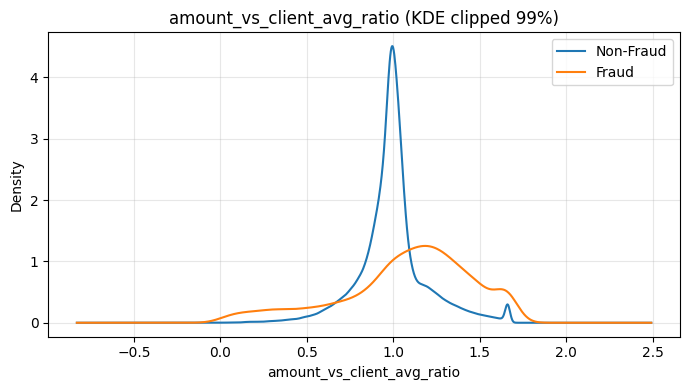

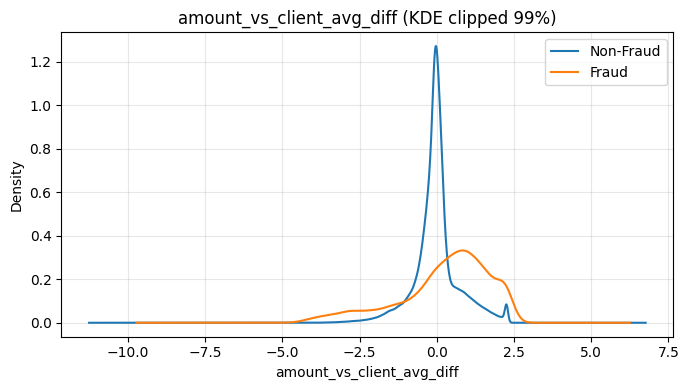

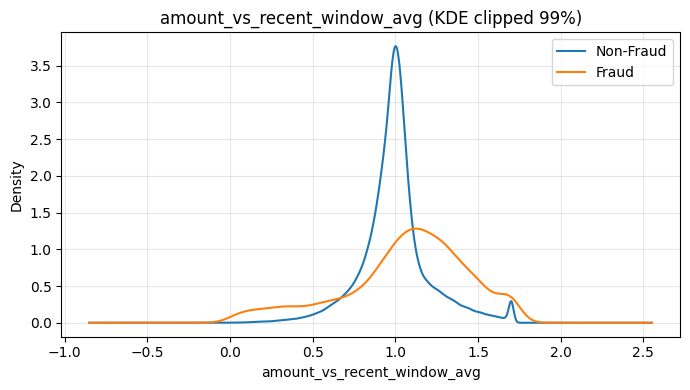

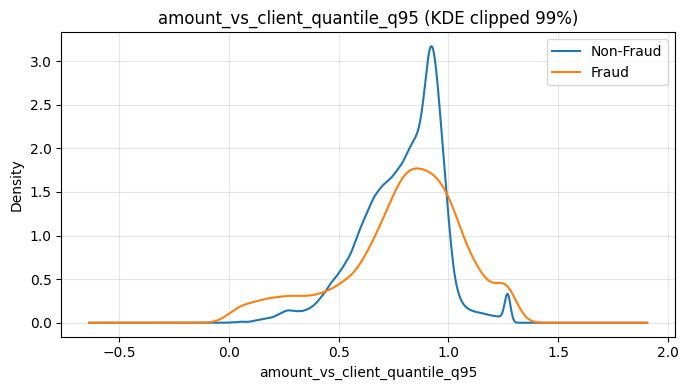

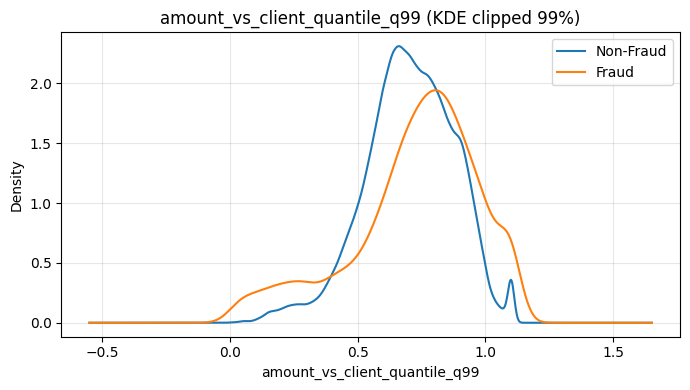

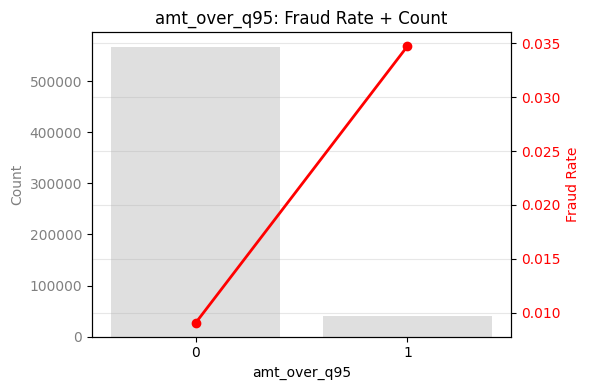

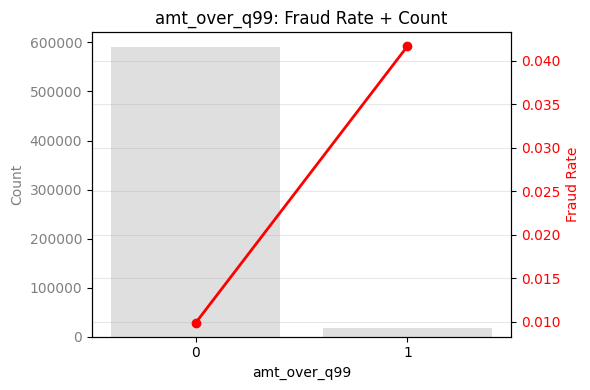

In [320]:
cols_sum = [
    "amount_vs_client_avg_ratio",
    "amount_vs_client_avg_diff",
    "amount_vs_recent_window_avg",
    "amount_vs_client_quantile_q95",
    "amount_vs_client_quantile_q99",
    "amt_over_q95",
    "amt_over_q99"
]

for col in cols_sum:
    plot_feature_by_type(df, col, y="fraud", clip_q=0.99)

- amount_vs_client_avg_ratio -> ratio 높을수록 fraud
- amount_vs_client_avg_diff -> dff 클수록 fraud
- amount_vs_recent_window_avg -> 약간의 분포 차 _ avg에 비해 amount가 더 많을수록 fraud 확률 높아짐
- amount_vs_client_quantaile_q95,99 -> 해당 고객의 과거 상위 *% 금액 수준 조금 더 크면 fraud 확률 높아짐 _ flag도 마찬가지


In [318]:
df["amt_over_q95"].min()

np.int8(0)

In [254]:
rows_uni = []

for col in cols_sum:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,amount_vs_client_avg_diff,0.480777,1.617330,1.663032e-245,0.040103,3.714982,60843
1,amount_vs_client_avg_ratio,1.027085,2.792912,4.533187e-245,0.039972,3.702801,60843
2,amount_vs_recent_window_avg,0.738622,2.093049,2.319020e-142,0.035682,3.305420,60843
3,amount_vs_client_quantile_q95,0.235566,1.265625,9.002427e-05,0.027185,2.518270,60843
4,amount_vs_client_quantile_q99,0.732223,2.079700,4.830779e-29,0.022484,2.082826,60843
5,amt_over_q95,1.370876,3.938799,0.000000e+00,0.010795,1.000000,608430
6,amt_over_q99,1.470435,4.351126,6.374711e-293,0.010795,1.000000,608430


In [255]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols_sum:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,amount_vs_client_avg_ratio,OK,-0.210055,0.810540,9.424449e-03,0.010795,0.041944,3.885505,-0.000279,-0.025883,60843
1,amt_over_q99,OK,0.359218,1.432210,9.443915e-14,0.010795,0.041336,3.829172,-0.000888,-0.082217,60843
2,amount_vs_client_quantile_q99,OK,-7.107725,0.000819,0.000000e+00,0.010795,0.041106,3.807856,-0.001118,-0.103532,60843
3,amount_vs_recent_window_avg,OK,-1.954616,0.141619,2.039069e-89,0.010795,0.040333,3.736297,-0.001890,-0.175091,60843
4,amount_vs_client_quantile_q95,OK,-6.147925,0.002138,0.000000e+00,0.010795,0.040202,3.724117,-0.002022,-0.187272,60843
5,amt_over_q95,OK,0.530896,1.700454,2.108944e-43,0.010795,0.040169,3.721072,-0.002054,-0.190317,60843
6,amount_vs_client_avg_diff,OK,-0.771451,0.462342,1.255073e-143,0.010795,0.038690,3.584044,-0.003534,-0.327345,60843


# 📦 Block: Amount Deviation / Personal Baseline Gap

이 블록은 “절대 금액”이 아니라
**개인 기준 대비 얼마나 벗어났는가**를 보는 레이어다.

---

## ✅ 강력 유지 (핵심 개인 기준 이탈 축)

| Feature                     | 판단 | 근거                    |
| --------------------------- | -- | --------------------- |
| amount_vs_client_avg_diff   | 유지 | 개인 평균 대비 차이, 구조적으로 타당 |
| amount_vs_client_avg_ratio  | 유지 | 상대적 과다 지출 비율 신호       |
| amount_vs_recent_window_avg | 유지 | 최근 소비 패턴 대비 급변        |
| amt_over_q99                | 유지 | 극단값 구간 분리             |
| amt_over_q95                | 유지 | 고액 세그먼트 구분            |

---

## 🔎 조건부 유지 / 중복 점검

| Feature                       | 판단       | 근거                     |
| ----------------------------- | -------- | ---------------------- |
| amount_vs_client_quantile_q99 | 중복 점검    | q99 기반 binary/연속 혼합 구조 |
| amount_vs_client_quantile_q95 | 중복 점검    | 위와 유사                  |
| avg_diff vs avg_ratio         | 구조 정리 필요 | 정보 상당 부분 겹칠 가능성 높음     |

---

## ❗ 해석상 중요한 점

다변량에서 일부 방향 반전이 발생한 이유는:

* 이미 `log_abs_amount`
* 이미 `income_ratio_risk_zone`
* 이미 `refund_high_amount`

등이 존재하는 상황에서
“개인 기준 대비 과다”가 일부 흡수되었기 때문일 가능성 높음.

즉, 이 블록은 단독 리스크라기보다는

> 🔥 금액 × 신규성
> 🔥 금액 × 업종위험
> 🔥 금액 × 속도

같은 구조에서 진짜 힘을 발휘할 타입.

---

# 🔎 Amount Deviation 블록 구조 요약

### 📌 핵심 개인 기준 이탈

* amount_vs_client_avg_ratio
* amount_vs_client_avg_diff
* amount_vs_recent_window_avg

### 📌 극단값 세그먼트

* amt_over_q95
* amt_over_q99

### 📌 정리 필요

* quantile 기반 연속/이진 중복

---


---

# 9. Fraud History Block (Delayed Feature)

> 과거 확정 fraud 기반 위험도

- client_fraud_last1

- client_fraud_last3

- card_fraud_last1

- card_fraud_last3

- 기타 fraud rolling count

**⚠️ Online 실시간 서빙 시에는**

- “지연 확정 라벨만 반영” 정책 필요

- 또는 offline 전용 feature로 분리

---

In [256]:
df["client_fraud_last1"] = (
    df.groupby("client_id")["fraud"]
      .shift(1)
      .fillna(0)
      .astype("int8")
)
df["card_fraud_last1"] = (
    df.groupby("card_id")["fraud"]
      .shift(1)
      .fillna(0)
      .astype("int8")
)
f1 = df.groupby("client_id")["fraud"].shift(1)
f2 = df.groupby("client_id")["fraud"].shift(2)
f3 = df.groupby("client_id")["fraud"].shift(3)

df["client_fraud_last3"] = (
    f1.fillna(0).astype("int8") +
    f2.fillna(0).astype("int8") +
    f3.fillna(0).astype("int8")
)
f1 = df.groupby("card_id")["fraud"].shift(1)
f2 = df.groupby("card_id")["fraud"].shift(2)
f3 = df.groupby("card_id")["fraud"].shift(3)

df["card_fraud_last3"] = (
    f1.fillna(0).astype("int8") +
    f2.fillna(0).astype("int8") +
    f3.fillna(0).astype("int8")
)

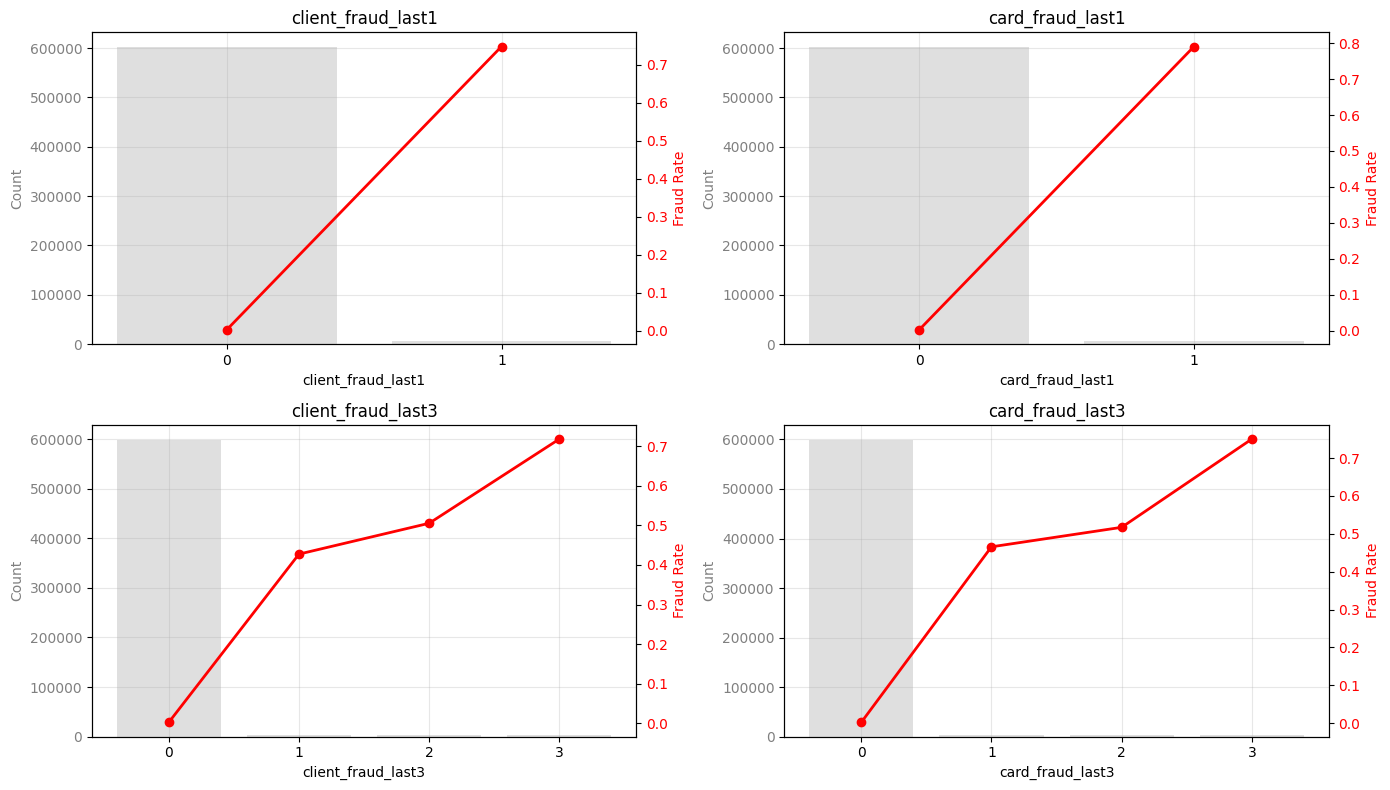

In [322]:
cols = ["client_fraud_last1", "card_fraud_last1", "client_fraud_last3", "card_fraud_last3"]

fig, axes = plt.subplots(2, 2, figsize=(14,8))
axes = axes.ravel()

for ax, col in zip(axes, cols):
    tmp = (
        df.groupby(col)["fraud"]
          .agg(rate="mean", cnt="size")
          .reset_index()
          .sort_values(col)
    )

    # count bars
    ax.bar(tmp[col].astype(str), tmp["cnt"], color="gray", alpha=0.25)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count", color="gray")
    ax.tick_params(axis="y", labelcolor="gray")
    ax.grid(True, alpha=0.3)

    # rate line on twin axis
    ax2 = ax.twinx()
    ax2.plot(tmp[col].astype(str), tmp["rate"], marker="o", linewidth=2, color="red")
    ax2.set_ylabel("Fraud Rate", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

plt.tight_layout()
plt.show()

In [257]:
cols = [    "client_fraud_last1",
            "client_fraud_last3",
            "card_fraud_last1",
            "card_fraud_last3"]
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,client_fraud_last1,6.968571,1062.703070,0.0,0.010795,1.0,608430
1,client_fraud_last3,2.573415,13.110515,0.0,0.010795,1.0,608430
2,card_fraud_last1,7.350753,1557.369189,0.0,0.010795,1.0,608430
3,card_fraud_last3,2.613644,13.648703,0.0,0.010795,1.0,608430


In [258]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_fraud_last3,OK,2.564471,12.993789,0.0,0.010795,0.094374,8.742387,0.052151,4.830999,60843
1,client_fraud_last3,OK,2.519370,12.420767,0.0,0.010795,0.093848,8.693666,0.051625,4.782278,60843
2,card_fraud_last1,OK,7.242390,1397.429466,0.0,0.010795,0.092188,8.539890,0.049965,4.628502,60843
3,client_fraud_last1,OK,6.866129,959.227887,0.0,0.010795,0.090101,8.346529,0.047877,4.435140,60843


# 📦 Block: Fraud History (Recidivism Layer)

이 블록은 해석이 매우 명확하다.
**과거 사기 이력은 가장 강력한 단일 리스크 축**이다.

---

## 🔥 최상위 절대 유지 (핵심 허브)

| Feature            | 판단              | 근거                     |
| ------------------ | --------------- | ---------------------- |
| card_fraud_last1   | **절대 유지 (최상위)** | 직전 카드 사기 이력은 거의 결정적 신호 |
| client_fraud_last1 | **절대 유지**       | 고객 단위 최근 사기 이력 강력      |
| card_fraud_last3   | **절대 유지**       | 최근 반복 패턴 반영            |
| client_fraud_last3 | **절대 유지**       | 동일                     |

---

## 🔎 구조 정리 필요 (window 선택 문제)

| Feature        | 판단       | 근거                        |
| -------------- | -------- | ------------------------- |
| last1 vs last3 | 중복 압축 가능 | recency window 중 최적 선택 필요 |

* last1은 “즉시 재시도” 패턴
* last3은 “최근 반복 경향”

둘 다 의미 있지만, 모델 단순화를 위해 압축 가능

---

## ❗ 구조적 해석

이 레이어는:

> 사기 발생 확률을 거의 직접적으로 반영하는 “후행 신호”

따라서:

* Interaction 설계의 중심이라기보다는
* **기본 확률을 끌어올리는 prior 조정 레이어**

에 가깝다.

---

## 🔥 현재까지 전체 구조에서의 위치

지금까지 나온 모든 블록 중

1. Fraud History
2. Merchant/MCC 신규성
3. MCC Risk
4. Velocity Explosion

이 네 축이 가장 강력하다.

Fraud History는 독립 허브이면서
interaction 증폭까지 가능하다.

---


---

# 10. Interaction / Cross Risk Block

> 단일 신호보다 강한 복합 리스크

---

# Fraud History Interaction 설계 요약

| Interaction 축                      | 교차 대상                                                | 검증 목적                    | 핵심 가설                            | 모델링 의도                 |
| ---------------------------------- | ---------------------------------------------------- | ------------------------ | -------------------------------- | ---------------------- |
| **Recidivism × Novelty**           | `client_merchant_is_new`<br>`client_mcc_is_new`      | 재범 고객이 새로운 환경으로 이동하는가    | 재범 집단에서 신규성 효과가 더 크게 증폭될 수 있음    | “재범 + 환경 변경” 패턴 검증     |
| **Recidivism × MCC Risk**          | `mcc_smoothed_risk`                                  | 재범 고객이 위험 업종을 반복 선택하는가   | 재범 집단에서 업종 위험도의 기울기가 더 커질 가능성    | “위험 업종 선택 편향 강화” 여부 검증 |
| **Recidivism × Velocity**          | `log_interval_dev`<br>`velocity_spike_ratio`         | 재범 고객이 더 공격적 속도 패턴을 보이는가 | 재범 집단에서 속도 이상이 더 급격하게 나타날 가능성    | “공격적 재시도 행동” 검증        |
| **Recidivism × Amount Escalation** | `amount_vs_client_avg_ratio`<br>`refund_high_amount` | 재범 고객이 금액을 키우는 전략을 쓰는가   | 금액 이탈 효과가 재범 집단에서 비선형적으로 증폭될 가능성 | “금액 escalation 전략” 탐지  |
| **Recidivism × Error Context**     | `err_bad_cvv`<br>`has_error`                         | 재범 고객이 실패-재시도 패턴을 보이는가   | 재범 집단에서 오류 발생과 재시도 결합 가능성        | “여러 번 시도 후 성공” 패턴 검증   |

---

## Interaction 설계의 핵심 질문

| 질문                   | 설명                        |
| -------------------- | ------------------------- |
| 재범은 환경을 바꾸는가?        | 새로운 가맹점·업종으로 이동하는지 확인     |
| 재범은 위험 업종을 반복 선택하는가? | MCC 위험도와 결합 여부 검증         |
| 재범은 더 공격적으로 행동하는가?   | 속도 폭증과 결합 여부 확인           |
| 재범은 금액을 키우는가?        | 개인 기준 대비 금액 escalation 검증 |
| 재범은 반복 시도를 하는가?      | 오류 발생과 재시도 패턴 확인          |

---

## 설계 목적 정리

Fraud History interaction의 목적은

> 단순히 “재범은 위험하다”를 넘어서
> **재범 집단의 행동 전략이 어떻게 달라지는지를 모델에 반영하는 것**이다.


In [ ]:
def add_interaction_columns(df: pd.DataFrame) -> None:
    """
    df에 interaction 컬럼을 '직접 추가'한다.
    return 없음 (in-place 수정)
    """

    binary_cols = [
        "client_merchant_is_new",
        "client_mcc_is_new",
        "card_merchant_is_new",
        "card_mcc_is_new",
        "refund_high_amount",
        "err_bad_cvv",
        "client_fraud_last3",
        "card_fraud_last3",
    ]

    for c in binary_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0).astype("int8")

    cont_cols = [
        "mcc_smoothed_risk",
        "log_interval_dev",
        "amount_vs_client_avg_ratio",
    ]

    for c in cont_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    interactions = {
        # Tier 1
        "client_merchant_is_new_x_mcc_smoothed_risk": ("client_merchant_is_new", "mcc_smoothed_risk"),
        "client_mcc_is_new_x_mcc_smoothed_risk":      ("client_mcc_is_new",      "mcc_smoothed_risk"),
        "client_merchant_is_new_x_log_interval_dev":  ("client_merchant_is_new", "log_interval_dev"),
        "client_mcc_is_new_x_log_interval_dev":       ("client_mcc_is_new",      "log_interval_dev"),

        # Tier 2
        "amount_ratio_x_client_merchant_new": ("amount_vs_client_avg_ratio", "client_merchant_is_new"),
        "amount_ratio_x_client_mcc_new":      ("amount_vs_client_avg_ratio", "client_mcc_is_new"),
        "amount_ratio_x_mcc_smoothed_risk":   ("amount_vs_client_avg_ratio", "mcc_smoothed_risk"),
        "refund_high_amount_x_client_merchant_new": ("refund_high_amount", "client_merchant_is_new"),

        # Tier 3
        "err_bad_cvv_x_client_merchant_new": ("err_bad_cvv", "client_merchant_is_new"),
        "err_bad_cvv_x_mcc_smoothed_risk":   ("err_bad_cvv", "mcc_smoothed_risk"),
        "client_fraud_last3_x_client_merchant_new": ("client_fraud_last3", "client_merchant_is_new"),
        "card_fraud_last3_x_client_merchant_new":   ("card_fraud_last3",   "client_merchant_is_new"),
    }

    for new_col, (a, b) in interactions.items():
        if new_col in df.columns:
            continue
        if a not in df.columns or b not in df.columns:
            continue

        df[new_col] = df[a] * df[b]

        if a in binary_cols and b in binary_cols:
            df[new_col] = df[new_col].fillna(0).astype("int8")
        else:
            df[new_col] = df[new_col].astype("float32")

In [340]:
add_interaction_columns(df)

print(df.shape)

(608430, 208)


In [346]:
cols = [
        # Tier 1
        "client_merchant_is_new_x_mcc_smoothed_risk",
        "client_mcc_is_new_x_mcc_smoothed_risk",
        "client_merchant_is_new_x_log_interval_dev",
        "client_mcc_is_new_x_log_interval_dev",

        # Tier 2
        "amount_ratio_x_client_merchant_new",
        "amount_ratio_x_client_mcc_new",
        "amount_ratio_x_mcc_smoothed_risk",
        "refund_high_amount_x_client_merchant_new",

        # Tier 3
        "err_bad_cvv_x_client_merchant_new",
        "err_bad_cvv_x_mcc_smoothed_risk",
        "client_fraud_last3_x_client_merchant_new",
        "card_fraud_last3_x_client_merchant_new",
]
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,amount_ratio_x_mcc_smoothed_risk,42.232057,2.193558e+18,0.000000e+00,0.090939,8.424178,60843
1,client_merchant_is_new_x_mcc_smoothed_risk,64.976591,1.655674e+28,0.000000e+00,0.010795,1.000000,608430
2,amount_ratio_x_client_merchant_new,2.368249,1.067868e+01,0.000000e+00,0.010795,1.000000,608430
3,client_mcc_is_new_x_mcc_smoothed_risk,60.866571,2.716538e+26,0.000000e+00,0.010795,1.000000,608430
4,err_bad_cvv_x_client_merchant_new,4.235049,6.906503e+01,9.629899e-171,0.010795,1.000000,608430
5,err_bad_cvv_x_mcc_smoothed_risk,92.280442,1.193677e+40,2.709123e-65,0.010795,1.000000,608430
6,amount_ratio_x_client_mcc_new,2.645094,1.408477e+01,0.000000e+00,0.010795,1.000000,608430
7,refund_high_amount_x_client_merchant_new,2.743392,1.553961e+01,8.773404e-69,0.010795,1.000000,608430
8,client_fraud_last3_x_client_merchant_new,4.022927,5.586437e+01,0.000000e+00,0.010795,1.000000,608430
9,card_fraud_last3_x_client_merchant_new,4.389951,8.063650e+01,0.000000e+00,0.010795,1.000000,608430


In [345]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.010794996959387276, 'top_decile_rate': 0.04222342751014907, 'top_decile_lift': 3.9113885505481116, 'thr': 0.020450959917663446, 'top_n': 60843}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,amount_ratio_x_mcc_smoothed_risk,OK,41.351727,9.095502e+17,0.000000e+00,0.010795,0.089871,8.325213,0.047647,4.413825,60843
1,client_merchant_is_new_x_mcc_smoothed_risk,OK,59.170218,4.980799e+25,0.000000e+00,0.010795,0.086370,8.000914,0.044146,4.089525,60843
2,amount_ratio_x_client_merchant_new,OK,2.698573,1.485851e+01,0.000000e+00,0.010795,0.085482,7.918697,0.043259,4.007308,60843
3,card_fraud_last3_x_client_merchant_new,OK,4.254864,7.044720e+01,0.000000e+00,0.010795,0.082442,7.637028,0.040218,3.725639,60843
4,client_fraud_last3_x_client_merchant_new,OK,3.915368,5.016755e+01,0.000000e+00,0.010795,0.082097,7.605055,0.039873,3.693666,60843
5,client_mcc_is_new_x_mcc_smoothed_risk,OK,54.879199,6.819197e+23,0.000000e+00,0.010795,0.074175,6.871194,0.031951,2.959805,60843
6,client_merchant_is_new_x_log_interval_dev,OK,-1.374710,2.529128e-01,0.000000e+00,0.010795,0.073090,6.770706,0.030866,2.859318,60843
7,amount_ratio_x_client_mcc_new,OK,2.585542,1.327047e+01,0.000000e+00,0.010795,0.066778,6.186054,0.024555,2.274665,60843
8,client_mcc_is_new_x_log_interval_dev,OK,-1.606699,2.005485e-01,0.000000e+00,0.010795,0.063426,5.875457,0.021202,1.964068,60843
9,err_bad_cvv_x_mcc_smoothed_risk,OK,80.438027,8.586007e+34,3.425830e-43,0.010795,0.042947,3.978380,0.000723,0.066991,60843


**[Keep]**

amount_ratio_x_mcc_smoothed_risk

client_merchant_is_new_x_mcc_smoothed_risk

amount_ratio_x_client_merchant_new

card_fraud_last3_x_client_merchant_new

client_fraud_last3_x_client_merchant_new



client_mcc_is_new_x_mcc_smoothed_risk

client_merchant_is_new_x_log_interval_dev

amount_ratio_x_client_mcc_new

client_mcc_is_new_x_log_interval_dev

**[Drop]** 

err_bad_cvv_x_mcc_smoothed_risk

err_bad_cvv_x_client_merchant_new

refund_high_amount_x_client_merchant_new